In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [5]:
week3_results = {
    "f1": ([0.729726, 0.729276], 5.31459276351908e-15),
    "f2": ([0.727681, 0.187140], 0.5037032225936308),
    "f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815),
    "f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579),
    "f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389),
    "f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669),
    "f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522),
    "f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661),
}

In [6]:
week4_results = {
    "f1": ([0.732162, 0.364472], 5.473776123300507e-57),
    "f2": ([0.715483, 0.563901], 0.5661662506769448),
    "f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105),
    "f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084),
    "f5": ([0.072013, 0.315203, 0.125702, 0.883341], 15.250051561683966),
    "f6": (	[0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387),
    "f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428),
}

In [7]:
week5_results = {
    "f1": ([0.812650, 0.143347], -1.0629331180647184e-161),
    "f2": ([0.678746, 0.850809], 0.6824523528240423),
    "f3": ([0.688252, 0.924125, 0.842251], -0.05314656740717209),
    "f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175),
    "f5": ([0.260034, 0.558879, 0.984293, 0.063132], 225.88673947929044),
    "f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992),
    "f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274),
    "f8": ([0.325520, 0.209525, 0.057274, 0.198246, 0.813824, 0.387519, 0.169663, 0.663670], 9.861549762954),
}

In [8]:
week6_results = {
    "f1": ([0.079265, 0.909848], 2.6078826238924974e-248),
    "f2": ([0.653993, 0.981188], 0.3798198130144502),
    "f3": ([0.788392, 0.913423, 0.403090], -0.03637482131814577),
    "f4": ([0.378009, 0.410452, 0.389136, 0.370426], 0.34655132659709453),
    "f5": ([0.000000, 0.856410, 1.000000, 0.433460], 849.8436606636637),
    "f6": ([0.537637, 0.403865, 0.951610, 0.943059, 0.050967], -0.6814591029200937),
    "f7": ([0.069772, 0.319669, 0.577421, 0.210909, 0.386068, 0.707262], 2.448290856114691),
    "f8": ([0.924338, 0.001471, 0.948665, 0.928797, 0.142329, 0.071686, 0.034416, 0.347751], 5.5407934131584),
}

In [9]:
week7_results = {
    "f1": ([0.525569, 0.987823], 2.2360328065267756e-98),
    "f2": ([0.000128, 0.346419], 0.005940965665866974),
    "f3": ([0.110343, 0.915465, 0.655916], -0.12413097550625916),
    "f4": ([0.402435, 0.485938, 0.405691, 0.380615], -1.5762466920468117),
    "f5": ([0.998891, 0.926298, 0.985415, 0.964459], 6575.295982756673),
    "f6": ([0.212341, 0.007631, 0.955851, 0.999487, 0.763435], -1.8381389462062772),
    "f7": ([0.064462, 0.412641, 0.669514, 0.193009, 0.502173, 0.667338], 1.3516399930526517),
    "f8": ([0.088856, 0.892449, 0.024530, 0.962260, 0.982699, 0.389537, 0.966989, 0.307254], 7.5413772236639005),
}

In [10]:
week8_results = {
    "f1": ([0.994902, 0.994221], 3.029971271826444e-187),
    "f2": ([0.920304, 0.040061], -0.03174629008935288),
    "f3": ([0.394618, 0.003779, 0.001514], -0.18116078744677863),
    "f4": ([0.413226, 0.408926, 0.383757, 0.471737], -0.9393775297880427),
    "f5": ([0.714539, 0.952855, 0.995586, 0.996033], 4660.244115920329),
    "f6": ([0.987971, 0.066922, 0.908036, 0.000615, 0.964637], -2.7568441153569343),
    "f7": ([0.186891, 0.934228, 0.522974, 0.187825, 0.066947, 0.841778], 0.13054782987236474),
    "f8": ([0.041050, 0.781948, 0.001813, 0.992673, 0.545189, 0.662834, 0.042235, 0.825023], 8.7204756545406),
}

In [11]:
week9_results = {
    "f1": ([0.684583, 0.725353], 1.8670441080687443e-9),
    "f2": ([0.695009, 0.789642], 0.5760952219798307),
    "f3": ([0.905262, 0.964713, 0.000892], -0.13042760699767658),
    "f4": ([0.378009, 0.230452, 0.389136, 0.550426], -4.6298356823203015),
    "f5": ([0.989950, 0.998195, 0.862178, 0.991837], 6294.324532147924),
    "f6": ([0.553475, 0.343241, 0.535219, 0.771873, 0.140689], -0.24936021594704408),
    "f7": ([0.019978, 0.998379, 0.127323, 0.788041, 0.383133, 0.520111], 0.01764809003897648),
    "f8": ([0.241028, 0.000000, 0.149637, 0.000000, 1.000000, 0.187244, 0.264684, 1.000000], 9.771881015877),
}

In [12]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
}

for week, results in weekly_results.items():
    for func, (inputs, output) in results.items():
        # Convert inputs and outputs to DataFrame
        inputs = np.array(inputs).reshape(1, -1)
        output = np.array([output]).reshape(1, -1)
        
        # Dynamically generate input column names
        df_inputs = pd.DataFrame(inputs, columns=[f"X{i+1}" for i in range(inputs.shape[1])])
        # Use existing output column names from the function
        output_cols = [col for col in functions_data[func].columns if col.startswith("y")]
        df_outputs = pd.DataFrame(output, columns=output_cols)
        
        # Combine
        df_week = pd.concat([df_inputs, df_outputs], axis=1)
        
        # Append only rows that are not already in the DataFrame
        functions_data[func] = pd.concat([functions_data[func], df_week], ignore_index=True)
        functions_data[func] = functions_data[func].drop_duplicates(ignore_index=True)

# Optional: check updated shapes
for func, df in functions_data.items():
    print(f"{func} updated shape: {df.shape}")


f1 updated shape: (19, 3)
f2 updated shape: (19, 3)
f3 updated shape: (24, 4)
f4 updated shape: (39, 5)
f5 updated shape: (29, 5)
f6 updated shape: (29, 6)
f7 updated shape: (39, 7)
f8 updated shape: (48, 9)


In [13]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98
17  0.994902  0.994221  3.029971e-187
18  0.684583  0.725353   1.867044e-09
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438

In [14]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,19.0,0.612696,0.260838,0.079265,4.680031e-01,6.845830e-01,7.971005e-01,9.949020e-01
X2,19.0,0.574663,0.322512,0.002800,3.146018e-01,6.815264e-01,8.120084e-01,9.942210e-01
y1,19.0,-0.000190,0.000827,-0.003606,4.534554e-223,3.606771e-81,1.267501e-40,1.867044e-09



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,19.0,0.596365,0.259885,0.000128,0.446407,0.665800,0.721582,0.999500
X2,19.0,0.507353,0.349340,0.001800,0.200504,0.563901,0.784135,0.999446
y1,19.0,0.254369,0.272847,-0.079755,-0.003958,0.244619,0.521350,0.682452



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,29.0,0.546685,0.276006,0.021735,0.363643,0.553475,0.757594,0.987971
X2,29.0,0.442970,0.306477,0.001300,0.229100,0.343241,0.748106,0.931871
X3,29.0,0.532583,0.308386,0.016523,0.345102,0.516000,0.811408,0.978806
X4,29.0,0.585830,0.312395,0.000615,0.356552,0.680515,0.821416,1.000000
X5,29.0,0.394292,0.305008,0.000000,0.112433,0.328835,0.614962,0.964637
y1,29.0,-1.367365,0.599061,-2.756844,-1.702558,-1.309116,-0.829237,-0.249360



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,39.0,0.426308,0.329132,0.000000,0.094099,0.417626,0.745602,0.942451
X2,39.0,0.437165,0.278127,0.011813,0.230167,0.397962,0.619736,0.998379
X3,39.0,0.405303,0.300980,0.003635,0.125657,0.360096,0.639299,0.924571
X4,39.0,0.467665,0.300681,0.073659,0.214494,0.382418,0.772167,0.961017
X5,39.0,0.449860,0.285531,0.014944,0.225290,0.413631,0.687320,0.998655
X6,39.0,0.527755,0.274793,0.051100,0.345781,0.619082,0.729401,0.980800
y1,39.0,0.352626,0.529930,0.002701,0.019776,0.095411,0.507295,2.448291



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,48.0,0.495859,0.314280,0.009077,0.192172,0.476658,0.782086,0.985945
X2,48.0,0.460869,0.323637,0.000000,0.172776,0.503188,0.758846,0.973980
X3,48.0,0.467892,0.304282,0.001813,0.236776,0.399460,0.728409,0.998885
X4,48.0,0.435679,0.289936,0.000000,0.179607,0.438626,0.670708,0.992673
X5,48.0,0.500760,0.289680,0.009649,0.245706,0.491909,0.734966,1.000000
X6,48.0,0.451538,0.266296,0.022113,0.245246,0.399431,0.669670,0.990244
X7,48.0,0.537197,0.284420,0.034416,0.262137,0.574163,0.763280,0.992914
X8,48.0,0.521432,0.274686,0.041956,0.312076,0.533857,0.729496,1.000000
y1,48.0,7.964085,1.110045,5.540793,7.308138,7.967780,8.744746,9.948689


#### Pearson Correlation


f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.003784,-0.034739
X2,0.003784,1.000000,-0.080239
y1,-0.034739,-0.080239,1.000000


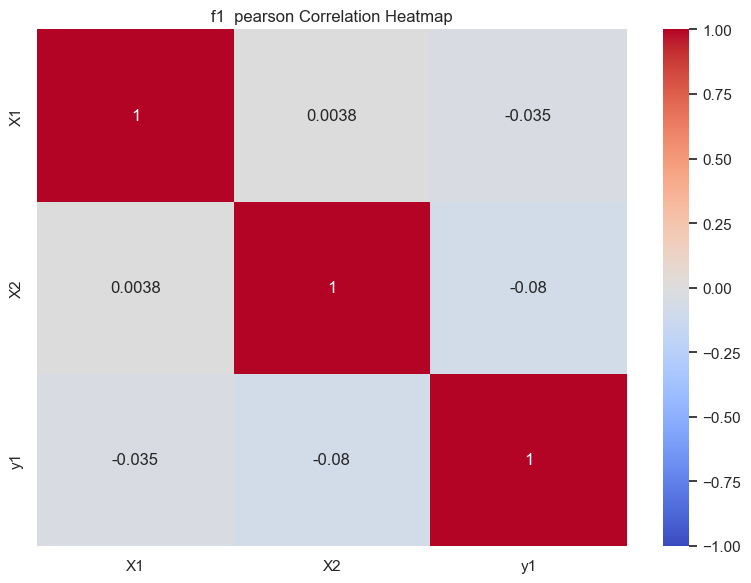


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.110499,0.370982
X2,0.110499,1.000000,0.400278
y1,0.370982,0.400278,1.000000


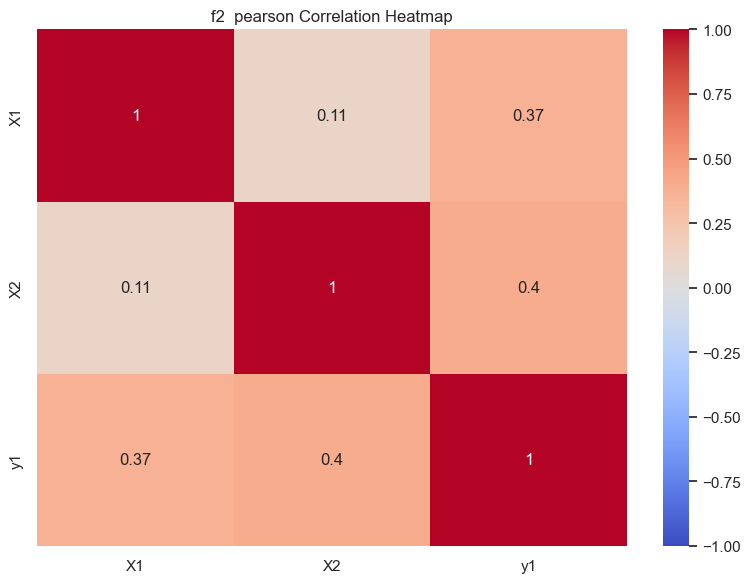


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.224209,-0.072304,0.120203
X2,0.224209,1.000000,-0.127958,0.276685
X3,-0.072304,-0.127958,1.000000,-0.279138
y1,0.120203,0.276685,-0.279138,1.000000


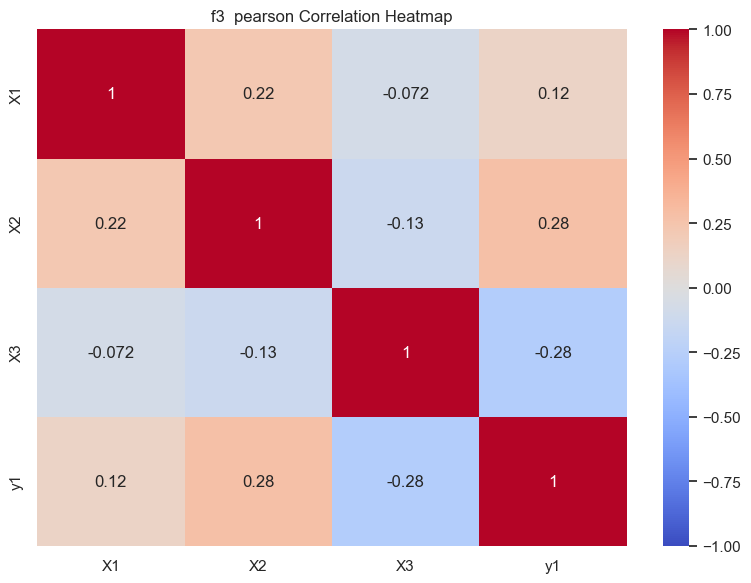


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.263939,0.273439,0.192895,-0.517049
X2,0.263939,1.000000,-0.055331,0.181324,-0.417114
X3,0.273439,-0.055331,1.000000,-0.144706,-0.167904
X4,0.192895,0.181324,-0.144706,1.000000,-0.400397
y1,-0.517049,-0.417114,-0.167904,-0.400397,1.000000


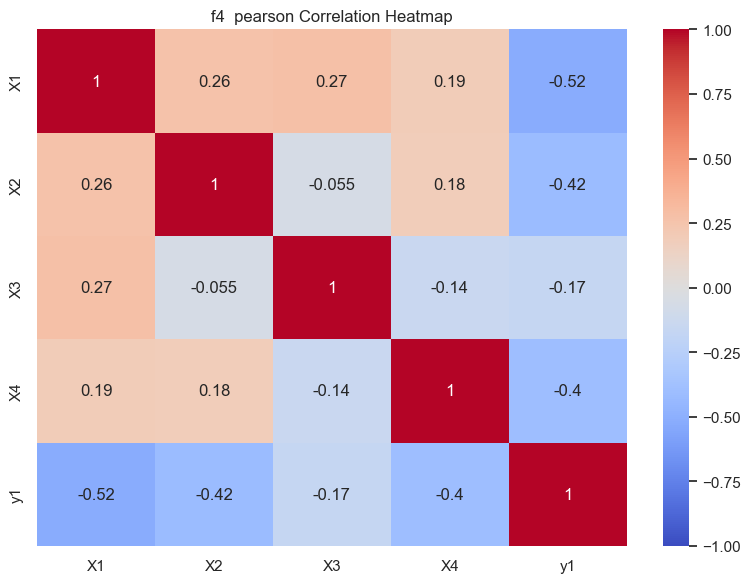


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.106106,0.112053,0.383590,0.561040
X2,0.106106,1.000000,0.365859,0.281755,0.565853
X3,0.112053,0.365859,1.000000,0.033930,0.558651
X4,0.383590,0.281755,0.033930,1.000000,0.526207
y1,0.561040,0.565853,0.558651,0.526207,1.000000


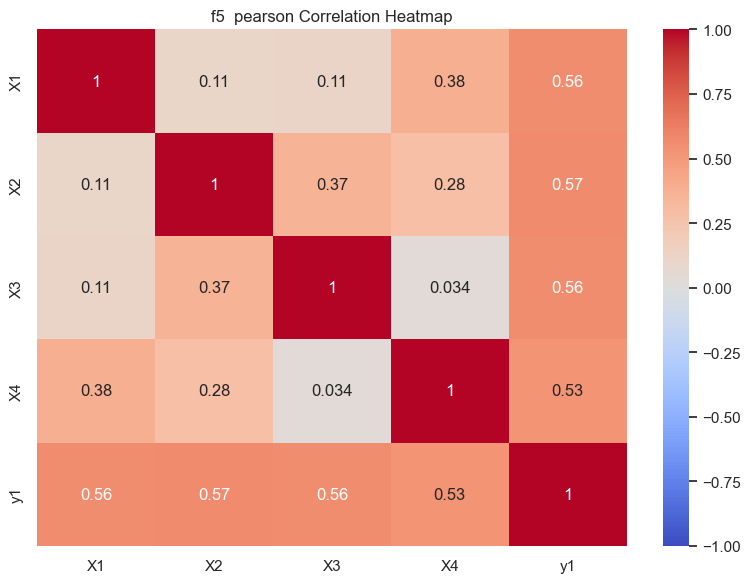


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.173768,-0.047643,-0.058933,-0.238456,-0.051323
X2,-0.173768,1.000000,-0.022575,-0.162229,0.124322,-0.237621
X3,-0.047643,-0.022575,1.000000,0.195946,-0.013385,0.112765
X4,-0.058933,-0.162229,0.195946,1.000000,-0.371879,0.618462
X5,-0.238456,0.124322,-0.013385,-0.371879,1.000000,-0.721772
y1,-0.051323,-0.237621,0.112765,0.618462,-0.721772,1.000000


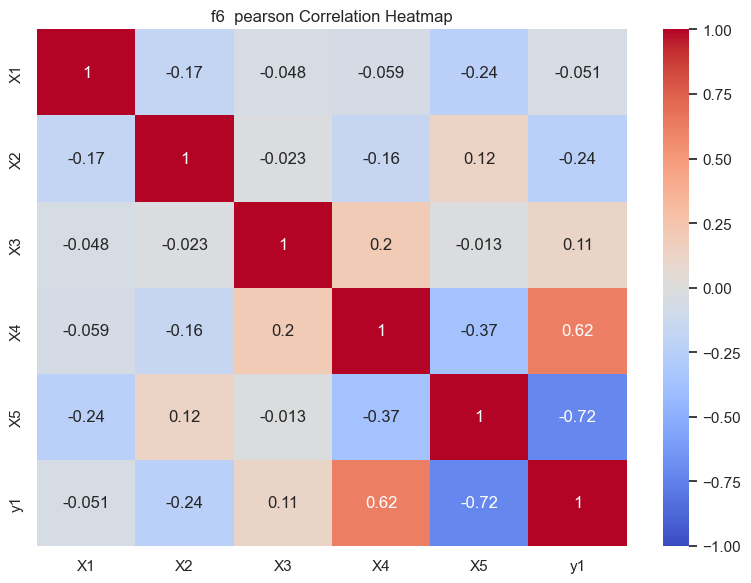


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.091936,-0.109348,-0.004067,0.064010,-0.502697,-0.444049
X2,-0.091936,1.000000,0.055126,0.127209,0.195847,0.206326,-0.124858
X3,-0.109348,0.055126,1.000000,0.112249,-0.244270,0.099699,0.153650
X4,-0.004067,0.127209,0.112249,1.000000,0.093496,-0.052849,-0.243236
X5,0.064010,0.195847,-0.244270,0.093496,1.000000,0.000403,-0.208735
X6,-0.502697,0.206326,0.099699,-0.052849,0.000403,1.000000,0.330577
y1,-0.444049,-0.124858,0.153650,-0.243236,-0.208735,0.330577,1.000000


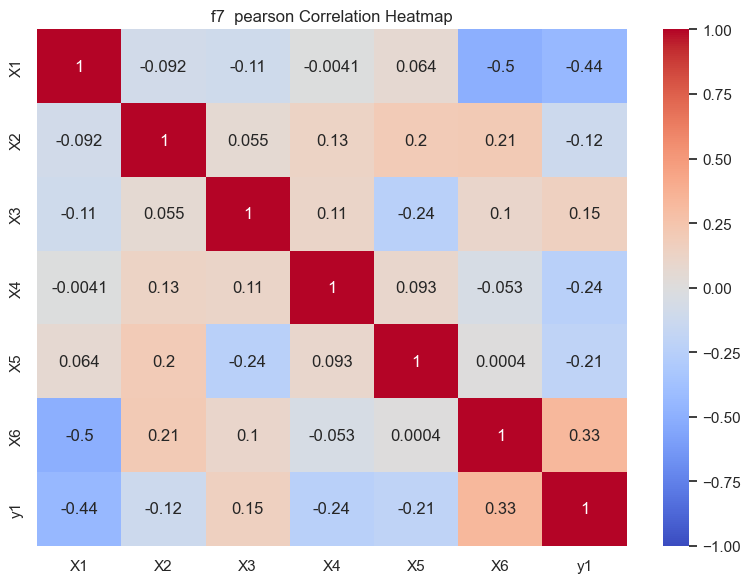


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.065096,0.246551,0.088155,0.065636,0.099302,0.159169,0.033372,-0.644630
X2,0.065096,1.000000,0.026254,-0.025480,0.063846,0.102572,0.025506,-0.270291,-0.220392
X3,0.246551,0.026254,1.000000,0.064536,-0.224859,-0.201790,-0.062738,-0.088805,-0.683854
X4,0.088155,-0.025480,0.064536,1.000000,-0.091389,-0.084768,-0.052170,0.228987,-0.273128
X5,0.065636,0.063846,-0.224859,-0.091389,1.000000,0.056201,0.142075,0.132536,0.073707
X6,0.099302,0.102572,-0.201790,-0.084768,0.056201,1.000000,0.037243,0.051536,0.087637
X7,0.159169,0.025506,-0.062738,-0.052170,0.142075,0.037243,1.000000,-0.211131,-0.319418
X8,0.033372,-0.270291,-0.088805,0.228987,0.132536,0.051536,-0.211131,1.000000,0.182171
y1,-0.644630,-0.220392,-0.683854,-0.273128,0.073707,0.087637,-0.319418,0.182171,1.000000


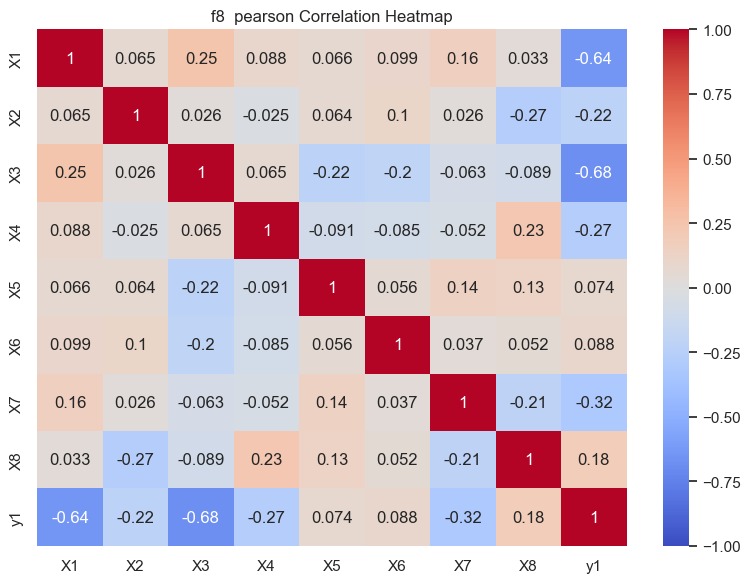

In [15]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

#### Spearman Correlation


f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.170175,0.196491
X2,-0.170175,1.000000,0.352632
y1,0.196491,0.352632,1.000000


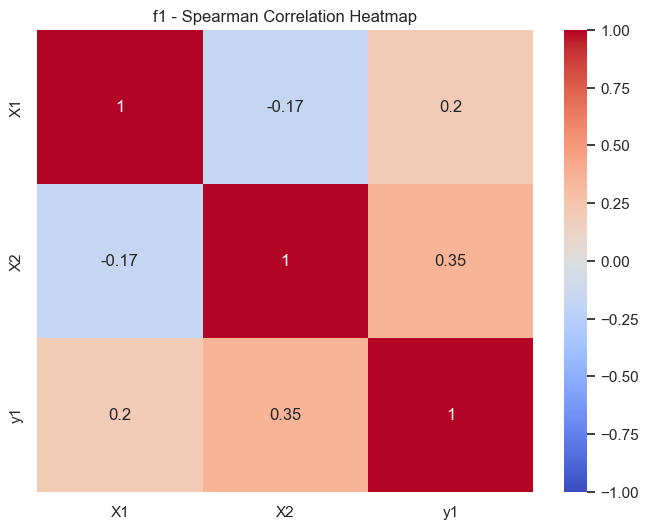


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.029825,0.280702
X2,-0.029825,1.000000,0.387719
y1,0.280702,0.387719,1.000000


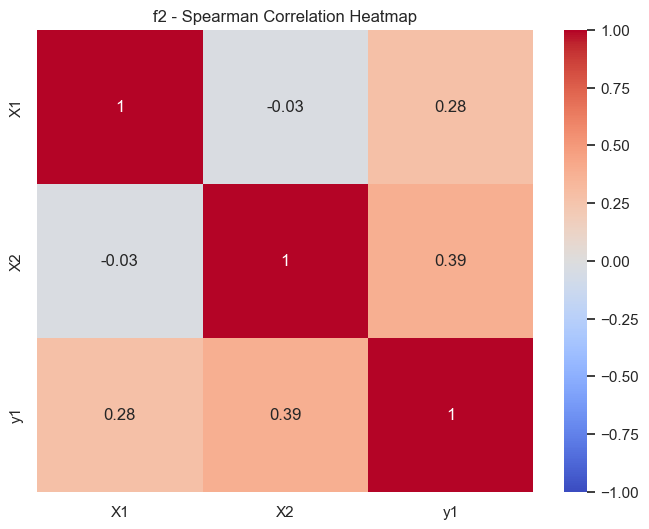


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.226957,-0.150435,0.038261
X2,0.226957,1.000000,-0.137391,0.247826
X3,-0.150435,-0.137391,1.000000,-0.018261
y1,0.038261,0.247826,-0.018261,1.000000


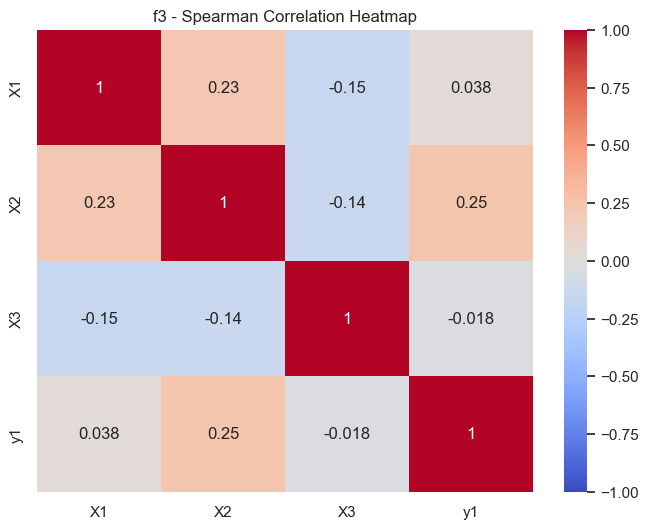


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.269852,0.260856,0.189686,-0.474417
X2,0.269852,1.000000,-0.005263,0.157085,-0.415992
X3,0.260856,-0.005263,1.000000,-0.185637,-0.158004
X4,0.189686,0.157085,-0.185637,1.000000,-0.347166
y1,-0.474417,-0.415992,-0.158004,-0.347166,1.000000


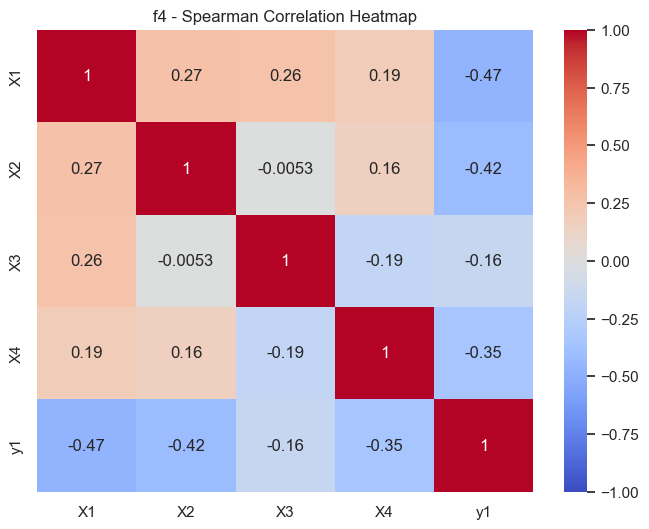


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.081773,0.094593,0.373892,0.214286
X2,0.081773,1.000000,0.485774,0.307389,0.609360
X3,0.094593,0.485774,1.000000,0.077103,0.674221
X4,0.373892,0.307389,0.077103,1.000000,0.518227
y1,0.214286,0.609360,0.674221,0.518227,1.000000


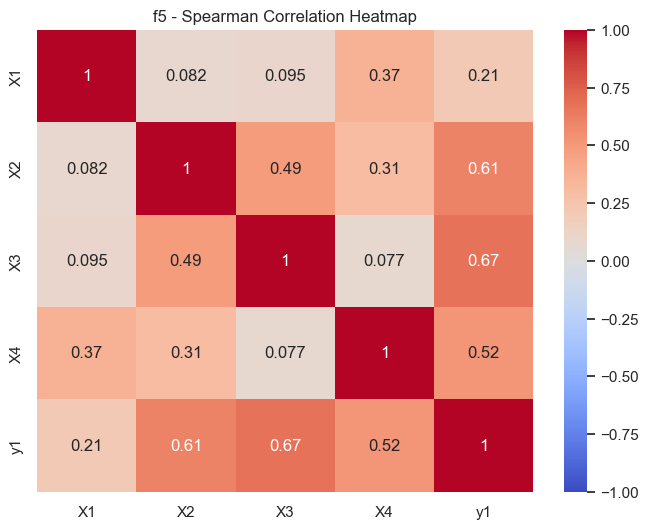


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.128357,-0.023405,-0.033009,-0.250523,-0.068728
X2,-0.128357,1.000000,-0.095344,-0.164060,0.041631,-0.182535
X3,-0.023405,-0.095344,1.000000,0.267028,-0.033748,0.135238
X4,-0.033009,-0.164060,0.267028,1.000000,-0.401970,0.589655
X5,-0.250523,0.041631,-0.033748,-0.401970,1.000000,-0.681281
y1,-0.068728,-0.182535,0.135238,0.589655,-0.681281,1.000000


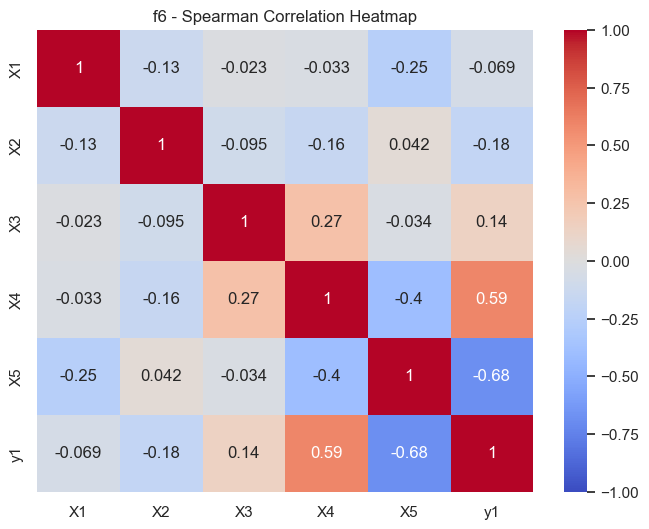


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.110931,-0.089271,0.010324,0.032996,-0.466599,-0.448381
X2,-0.110931,1.000000,0.048583,0.178543,0.236640,0.186235,-0.162955
X3,-0.089271,0.048583,1.000000,0.085425,-0.235628,0.146964,0.292308
X4,0.010324,0.178543,0.085425,1.000000,0.099190,-0.013158,-0.215385
X5,0.032996,0.236640,-0.235628,0.099190,1.000000,-0.045142,-0.378340
X6,-0.466599,0.186235,0.146964,-0.013158,-0.045142,1.000000,0.336235
y1,-0.448381,-0.162955,0.292308,-0.215385,-0.378340,0.336235,1.000000


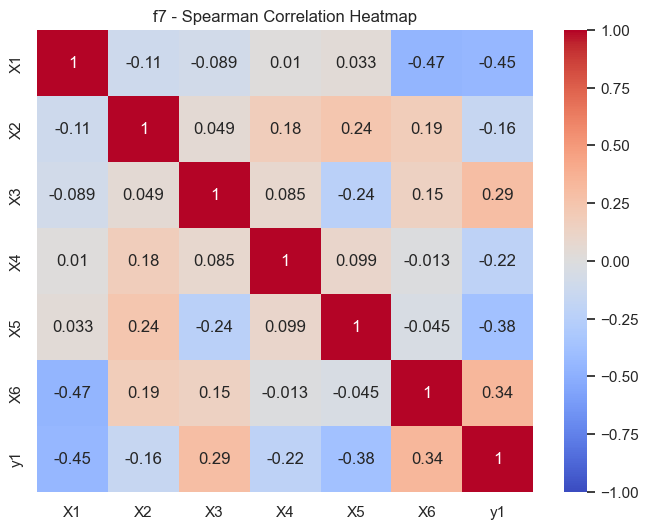


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.065840,0.239796,0.093413,0.072136,0.096561,0.131350,0.024914,-0.635910
X2,0.065840,1.000000,0.039840,-0.033599,0.043587,0.115128,0.039460,-0.273842,-0.233452
X3,0.239796,0.039840,1.000000,0.109860,-0.227861,-0.186284,-0.043639,-0.125600,-0.647634
X4,0.093413,-0.033599,0.109860,1.000000,-0.123053,-0.097975,-0.029148,0.207187,-0.263522
X5,0.072136,0.043587,-0.227861,-0.123053,1.000000,0.087771,0.150731,0.108614,0.087008
X6,0.096561,0.115128,-0.186284,-0.097975,0.087771,1.000000,0.068879,0.082343,0.035335
X7,0.131350,0.039460,-0.043639,-0.029148,0.150731,0.068879,1.000000,-0.202513,-0.345419
X8,0.024914,-0.273842,-0.125600,0.207187,0.108614,0.082343,-0.202513,1.000000,0.171032
y1,-0.635910,-0.233452,-0.647634,-0.263522,0.087008,0.035335,-0.345419,0.171032,1.000000


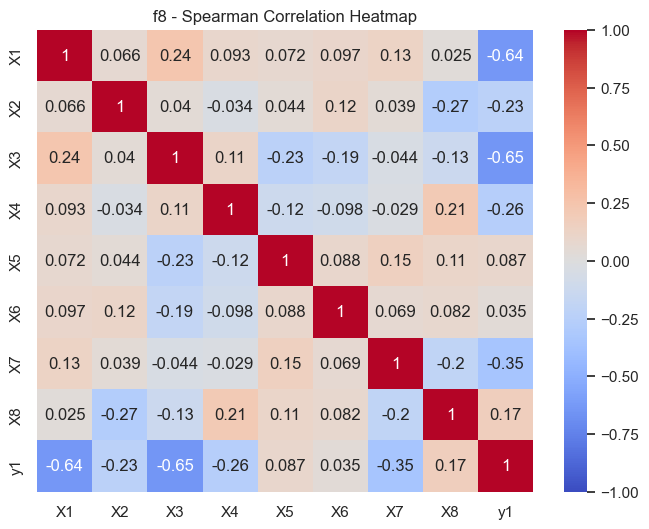

In [16]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

#### Kendall Correlation


f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.157895,0.111111
X2,-0.157895,1.000000,0.216374
y1,0.111111,0.216374,1.000000


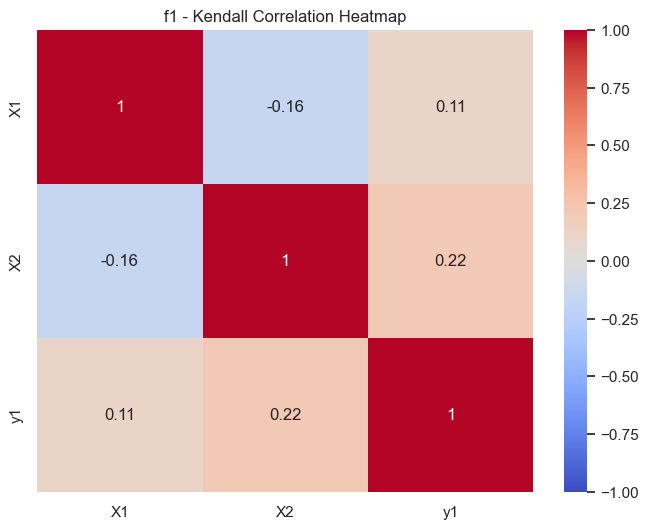


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.040936,0.204678
X2,-0.040936,1.000000,0.309942
y1,0.204678,0.309942,1.000000


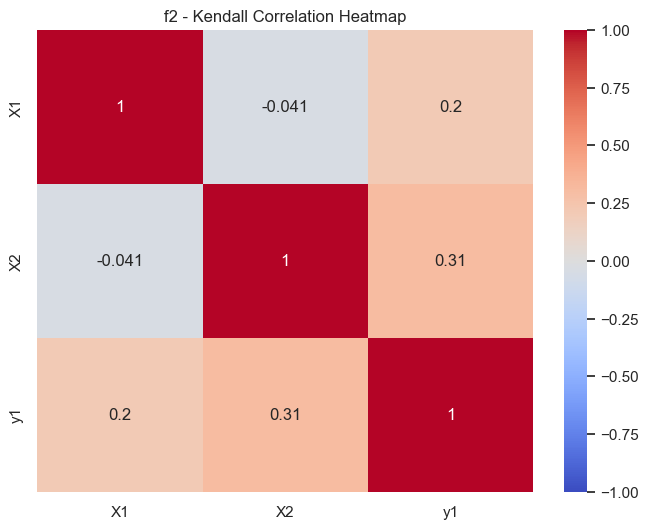


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.173913,-0.115942,0.050725
X2,0.173913,1.000000,-0.101449,0.181159
X3,-0.115942,-0.101449,1.000000,0.007246
y1,0.050725,0.181159,0.007246,1.000000


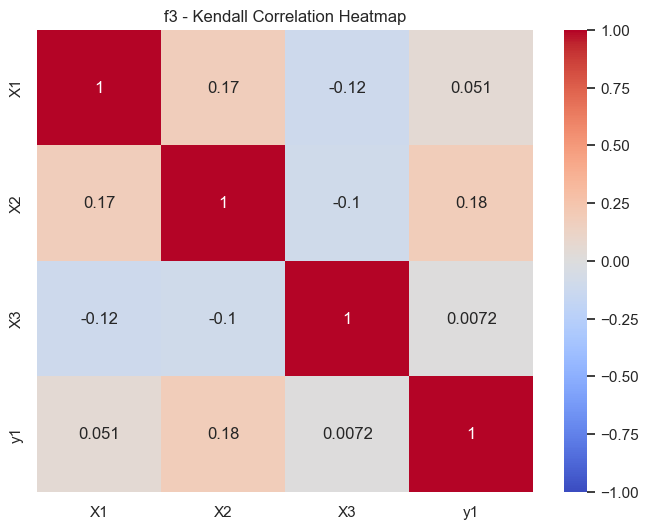


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.178258,0.200000,0.129642,-0.318704
X2,0.178258,1.000000,0.021607,0.106613,-0.279352
X3,0.200000,0.021607,1.000000,-0.140446,-0.156651
X4,0.129642,0.106613,-0.140446,1.000000,-0.244265
y1,-0.318704,-0.279352,-0.156651,-0.244265,1.000000


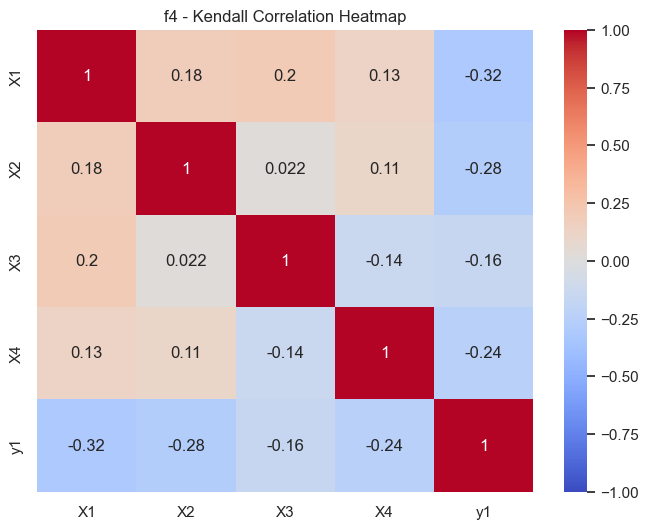


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.044335,0.056720,0.270936,0.118227
X2,0.044335,1.000000,0.303329,0.201970,0.413793
X3,0.056720,0.303329,1.000000,0.027127,0.485820
X4,0.270936,0.201970,0.027127,1.000000,0.354680
y1,0.118227,0.413793,0.485820,0.354680,1.000000


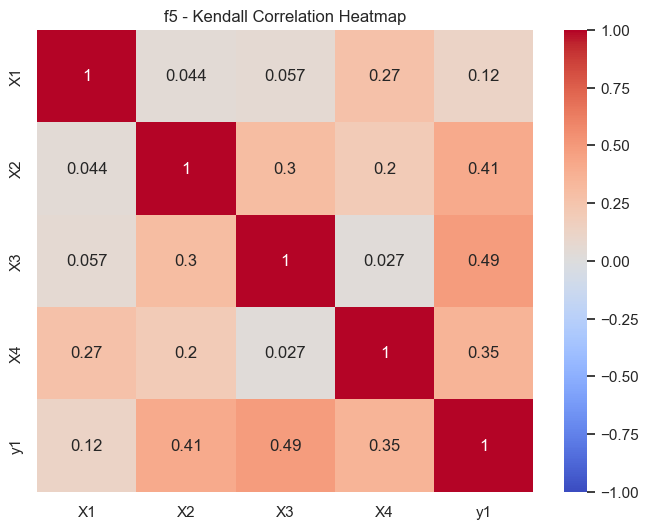


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.111111,-0.012346,-0.007398,-0.199754,-0.046856
X2,-0.111111,1.000000,-0.056790,-0.110974,0.012330,-0.140567
X3,-0.012346,-0.056790,1.000000,0.184957,-0.017263,0.106042
X4,-0.007398,-0.110974,0.184957,1.000000,-0.330049,0.438424
X5,-0.199754,0.012330,-0.017263,-0.330049,1.000000,-0.497537
y1,-0.046856,-0.140567,0.106042,0.438424,-0.497537,1.000000


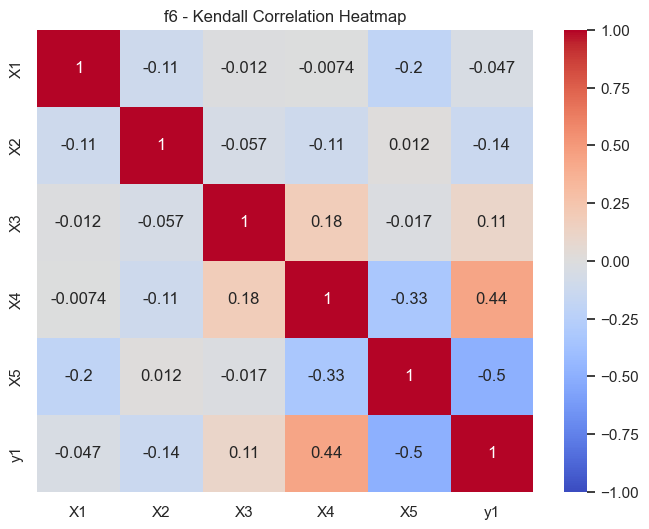


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.058030,-0.052632,-0.001350,0.012146,-0.314440,-0.346829
X2,-0.058030,1.000000,0.033738,0.117409,0.163293,0.101215,-0.120108
X3,-0.052632,0.033738,1.000000,0.031039,-0.155196,0.112011,0.187584
X4,-0.001350,0.117409,0.031039,1.000000,0.068826,-0.020243,-0.155196
X5,0.012146,0.163293,-0.155196,0.068826,1.000000,-0.022942,-0.238866
X6,-0.314440,0.101215,0.112011,-0.020243,-0.022942,1.000000,0.217274
y1,-0.346829,-0.120108,0.187584,-0.155196,-0.238866,0.217274,1.000000


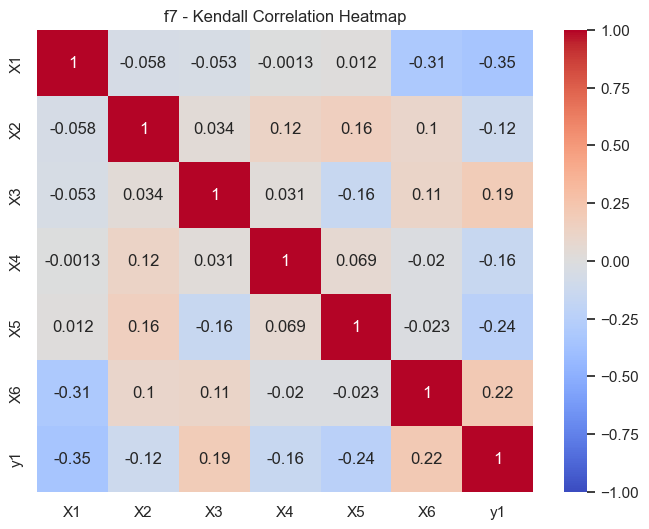


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.054102,0.143617,0.059424,0.045233,0.048780,0.074468,0.007982,-0.448582
X2,0.054102,1.000000,0.022173,-0.034605,0.043478,0.054126,0.016851,-0.171251,-0.144568
X3,0.143617,0.022173,1.000000,0.059424,-0.153437,-0.132151,-0.026596,-0.094900,-0.475177
X4,0.059424,-0.034605,0.059424,1.000000,-0.078971,-0.039929,-0.013304,0.153505,-0.174723
X5,0.045233,0.043478,-0.153437,-0.078971,1.000000,0.066548,0.107317,0.078971,0.066519
X6,0.048780,0.054126,-0.132151,-0.039929,0.066548,1.000000,0.054102,0.047028,0.013304
X7,0.074468,0.016851,-0.026596,-0.013304,0.107317,0.054102,1.000000,-0.132151,-0.267730
X8,0.007982,-0.171251,-0.094900,0.153505,0.078971,0.047028,-0.132151,1.000000,0.117960
y1,-0.448582,-0.144568,-0.475177,-0.174723,0.066519,0.013304,-0.267730,0.117960,1.000000


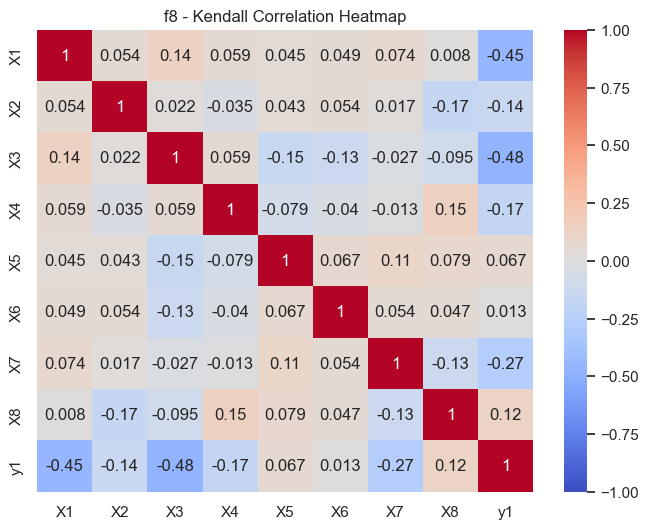

In [17]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


#### Mutual Information

In [18]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n{name} — Mutual Information with Output")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



f1 — Mutual Information with Output


,Feature,Mutual_Info
1,X2,0.017544
0,X1,0.000000



f2 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.362775
1,X2,0.000000



f3 — Mutual Information with Output


...

,Feature,Mutual_Info
4,X5,0.355327
3,X4,0.127728
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



f7 — Mutual Information with Output


,Feature,Mutual_Info
5,X6,0.148278
4,X5,0.110783
0,X1,0.107719
2,X3,0.017646
1,X2,0.016395
3,X4,0.000000



f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.350837
0,X1,0.297854
6,X7,0.164727
1,X2,0.000000
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


#### Partial Correlation

In [19]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n{name} — Partial Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



f1 — Partial Correlation
          n         r          CI95%     p-val
pearson  19 -0.034547  [-0.49, 0.44]  0.891753
          n         r         CI95%     p-val
pearson  19 -0.080157  [-0.53, 0.4]  0.751873

f2 — Partial Correlation
          n         r          CI95%    p-val
pearson  19  0.358759  [-0.13, 0.71]  0.14374
          n         r          CI95%     p-val
pearson  19  0.389277  [-0.09, 0.72]  0.110327

f3 — Partial Correlation
          n         r          CI95%     p-val
pearson  24  0.052365  [-0.38, 0.46]  0.816977
          n         r        CI95%   p-val
pearson  24  0.237264  [-0.2, 0.6]  0.2877
          n         r          CI95%     p-val
pearson  24 -0.253683  [-0.61, 0.19]  0.254627

f4 — Partial Correlation
          n         r           CI95%     p-val
pearson  39 -0.387852  [-0.64, -0.07]  0.019423
          n         r         CI95%     p-val
pearson  39 -0.331742  [-0.6, -0.0]  0.048089
          n         r          CI95%     p-val
pearson  39 -0.

#### Sliced Inverse Regression (SIR)



Feature vs Output Plots for f1
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 74.79, n_boot=100


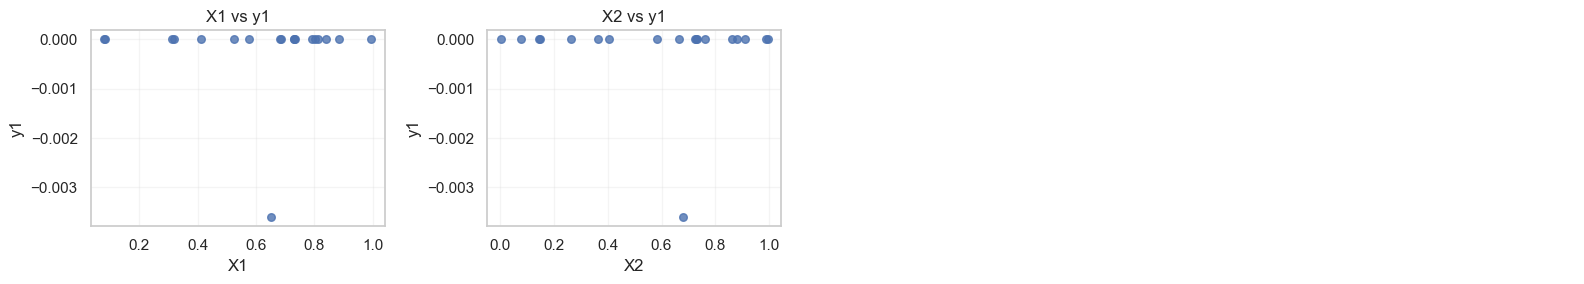

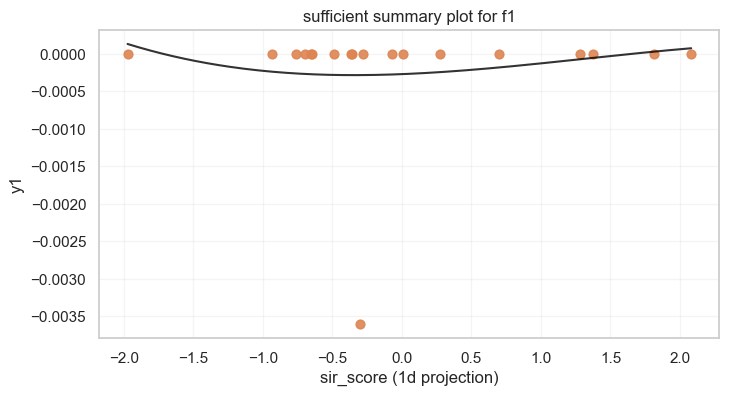

  leading sir direction (first 8 components):
    X1: -0.8652
    X2: -0.5014
  leading eigenvalues (top 3): [0.56191465 0.13096053]

Feature vs Output Plots for f2
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 83.90, n_boot=100


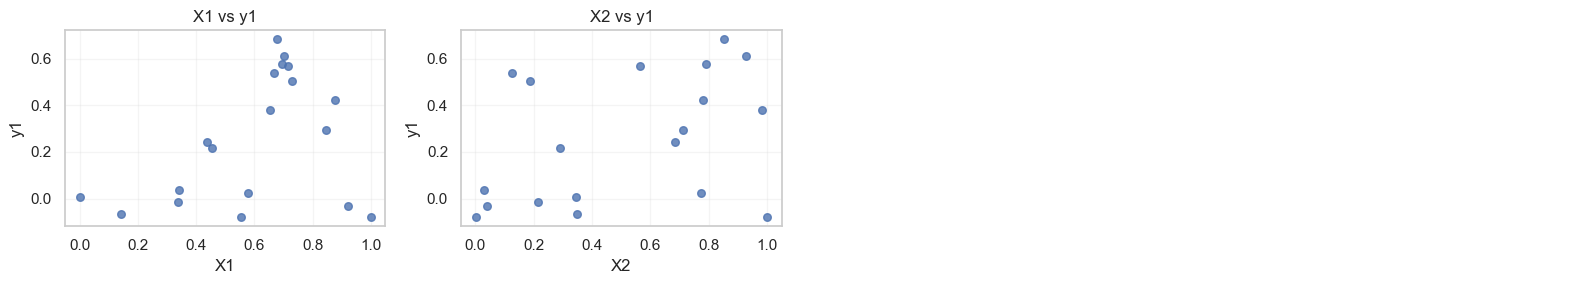

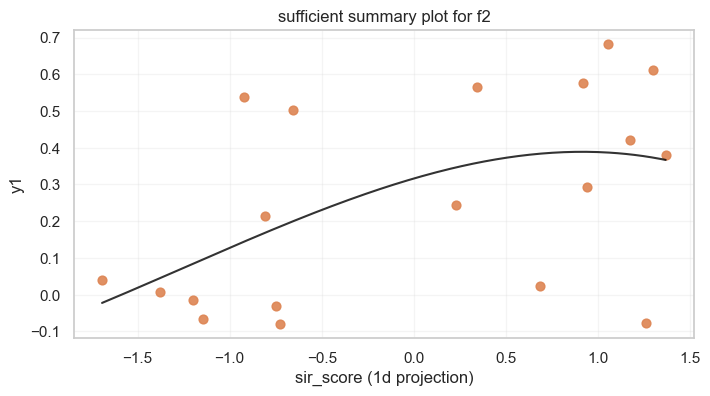

  leading sir direction (first 8 components):
    X1: 0.4000
    X2: 0.9165
  leading eigenvalues (top 3): [0.60041063 0.28749746]

Feature vs Output Plots for f3
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 65.84, n_boot=100


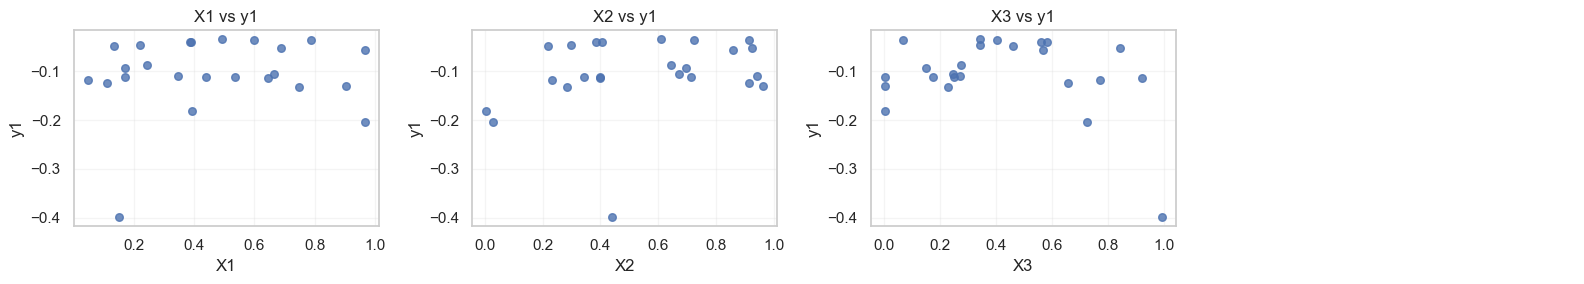

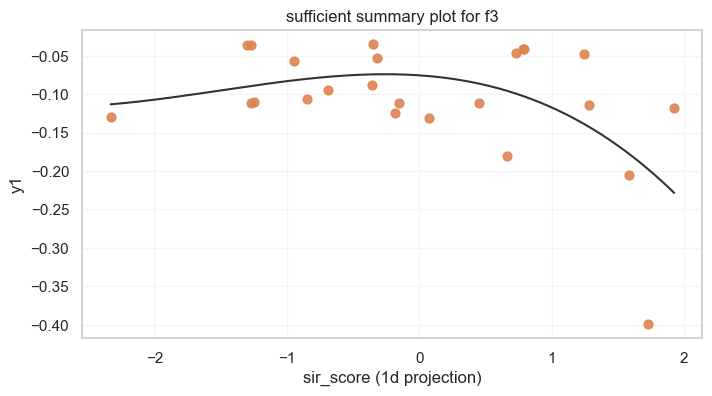

  leading sir direction (first 8 components):
    X1: -0.2355
    X2: -0.7685
    X3: 0.5949
  leading eigenvalues (top 3): [0.8298279  0.21486887 0.08652464]

Feature vs Output Plots for f4
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 31.46, n_boot=100


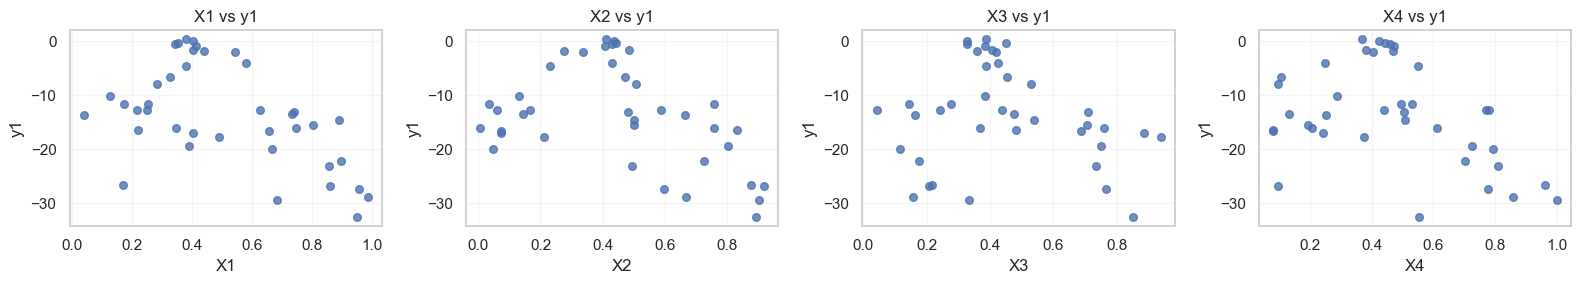

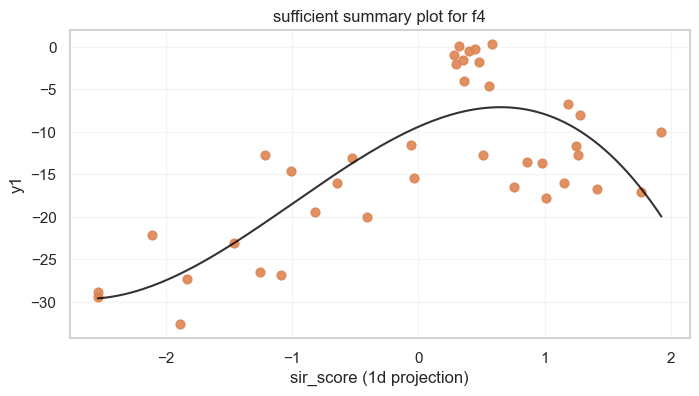

  leading sir direction (first 8 components):
    X1: -0.6082
    X2: -0.5584
    X3: 0.1228
    X4: -0.5506
  leading eigenvalues (top 3): [1.0895243  0.34062822 0.18982379]

Feature vs Output Plots for f5
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 45.58, n_boot=100


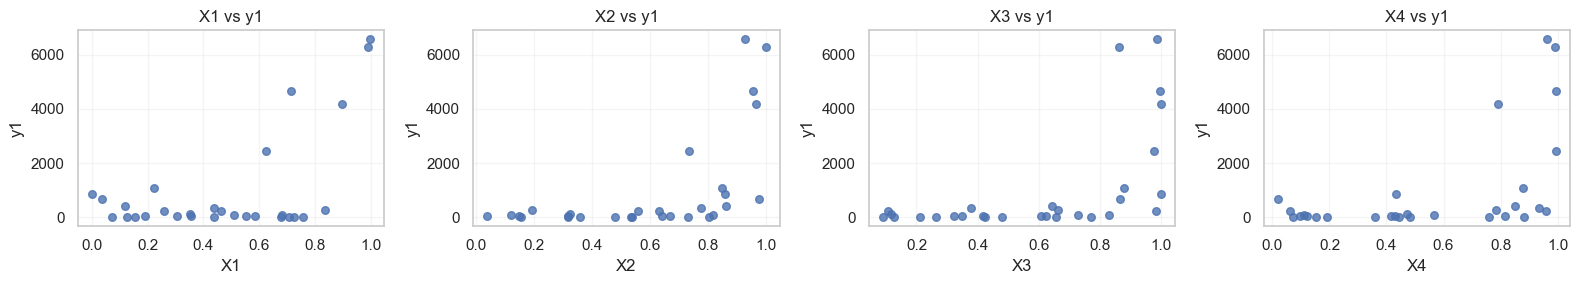

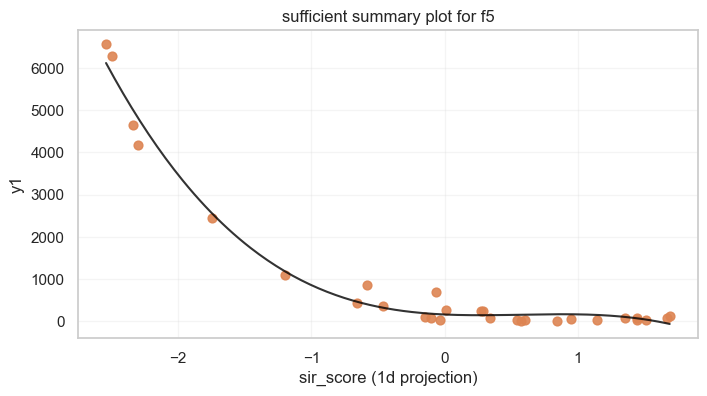

  leading sir direction (first 8 components):
    X1: -0.3210
    X2: -0.6154
    X3: -0.5520
    X4: -0.4621
  leading eigenvalues (top 3): [1.35350921 0.42194084 0.19063183]

Feature vs Output Plots for f6
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 90.21, n_boot=100


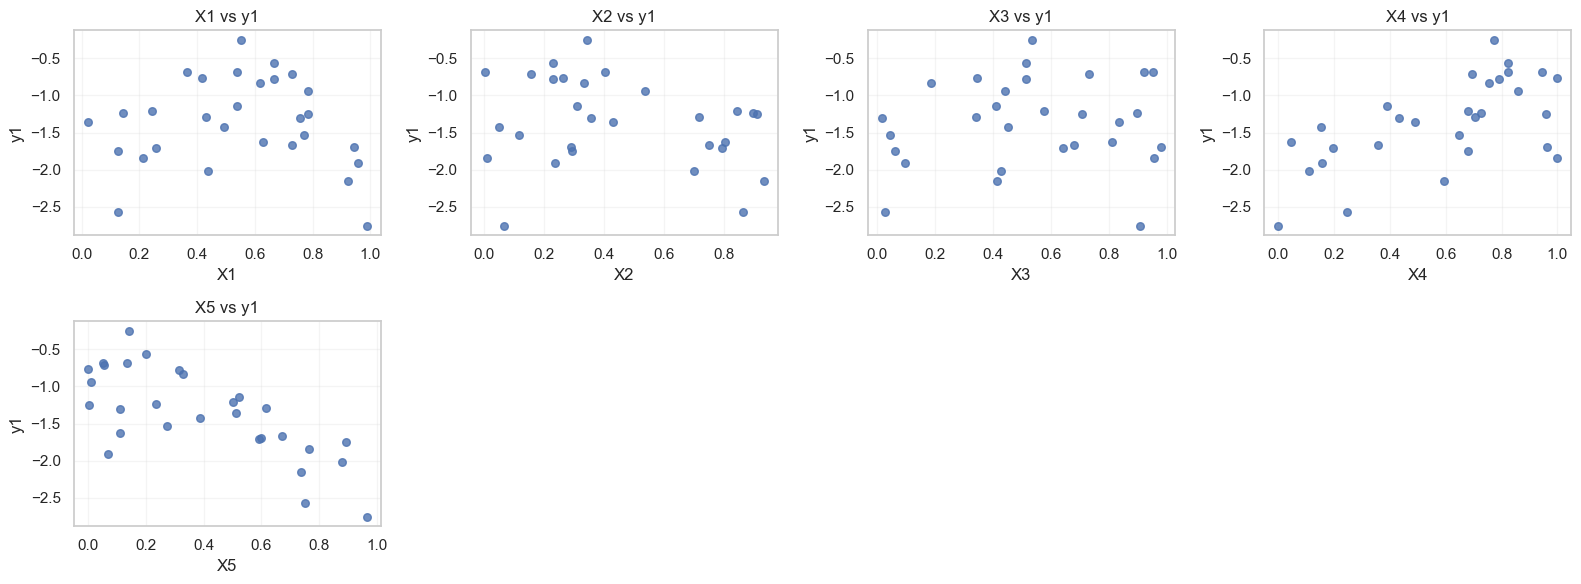

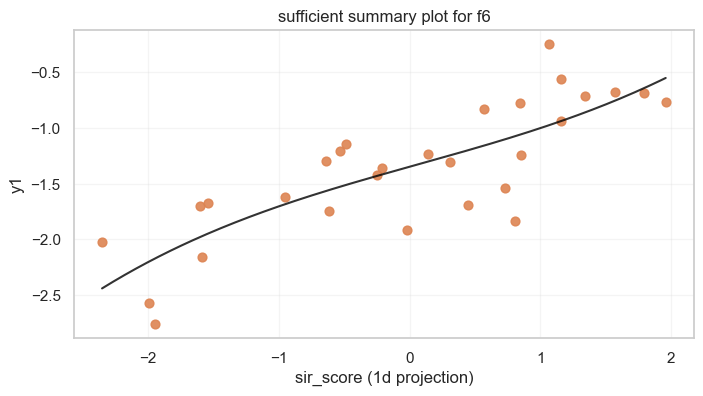

  leading sir direction (first 8 components):
    X1: -0.0891
    X2: -0.4409
    X3: 0.0414
    X4: 0.6020
    X5: -0.6585
  leading eigenvalues (top 3): [1.11568274 0.46210886 0.18127039]

Feature vs Output Plots for f7
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 79.50, n_boot=100


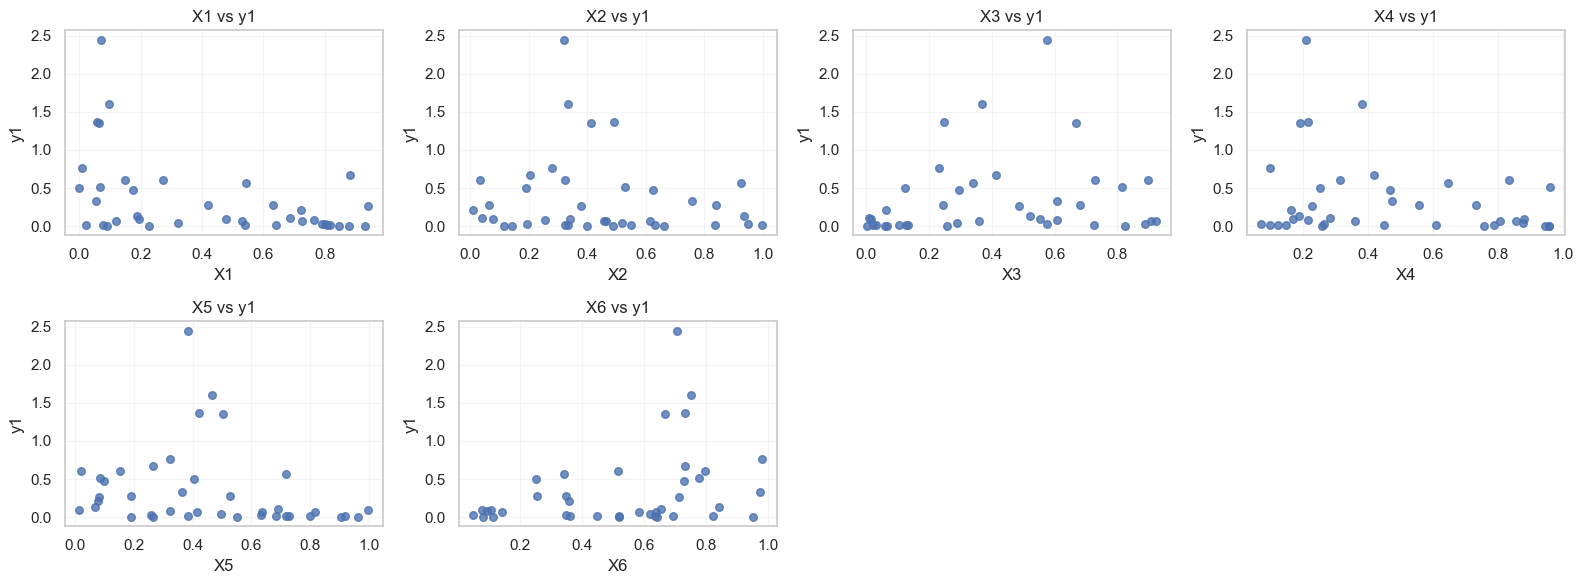

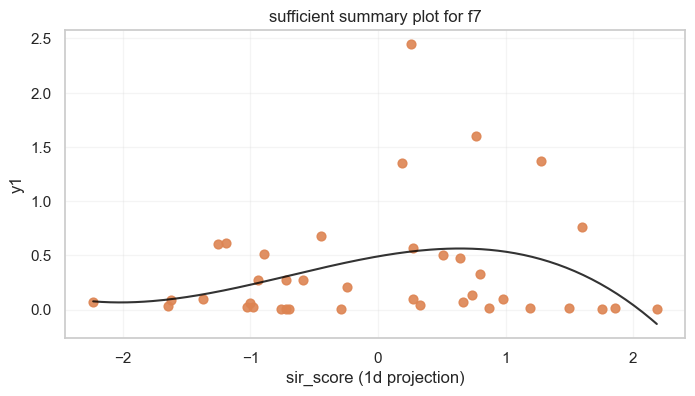

  leading sir direction (first 8 components):
    X1: -0.3008
    X2: 0.2341
    X3: -0.7128
    X4: -0.2305
    X5: 0.2823
    X6: 0.4624
  leading eigenvalues (top 3): [0.65038566 0.58996333 0.24752577]

Feature vs Output Plots for f8
  sir: computed leading direction and scores
  bootstrap stability mean angle (deg): 27.31, n_boot=100


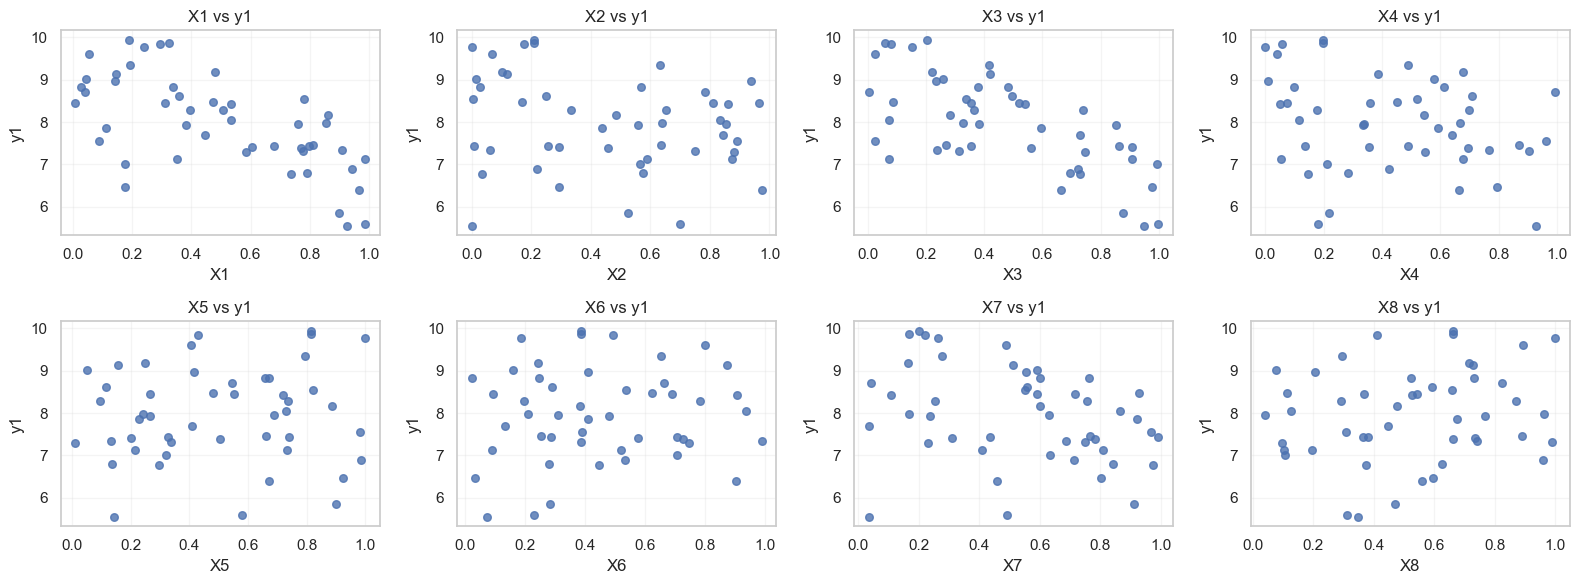

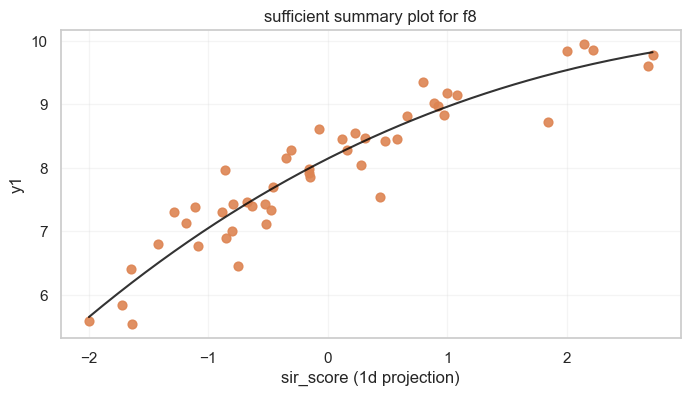

  leading sir direction (first 8 components):
    X1: -0.5801
    X2: -0.2369
    X3: -0.6175
    X4: -0.2704
    X5: 0.1327
    X6: 0.0181
    X7: -0.3213
    X8: 0.1783
  leading eigenvalues (top 3): [1.1633764  0.33208644 0.24453744]


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# sliced inverse regression implementation
def sliced_inverse_regression(X, y, n_slices=8):
    # standardise x
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n, p = Xs.shape
    # ensure sensible number of slices
    n_slices = min(max(2, int(n_slices)), max(2, n))
    # slice edges by quantiles
    quantiles = np.linspace(0.0, 1.0, n_slices + 1)
    bins = np.quantile(y, quantiles)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    slice_idx = np.digitize(y, bins) - 1  # 0..n_slices-1

    # compute slice means and probabilities
    slice_means = np.zeros((n_slices, p))
    slice_probs = np.zeros(n_slices)
    for s in range(n_slices):
        mask = slice_idx == s
        if mask.sum() > 0:
            slice_means[s] = Xs[mask].mean(axis=0)
            slice_probs[s] = mask.sum() / n
        else:
            slice_means[s] = 0.0
            slice_probs[s] = 0.0

    # between-slice covariance
    cov = np.zeros((p, p))
    for s in range(n_slices):
        m = slice_means[s].reshape(-1, 1)
        cov += slice_probs[s] * (m @ m.T)

    # eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    leading = eigvecs[:, idx[0]]
    sir_dir = leading / (np.linalg.norm(leading) + 1e-12)

    # sir scores are projections of the standardised X
    sir_scores = Xs @ sir_dir
    return sir_dir, sir_scores, scaler, eigvals[idx]

# optional bootstrap stability check for the leading direction
def sir_bootstrap_stability(X, y, n_slices=8, n_boot=100, random_state=0):
    rng = np.random.RandomState(random_state)
    angles = []
    base_dir, _, _, _ = sliced_inverse_regression(X, y, n_slices=n_slices)
    for _ in range(n_boot):
        Xb, yb = resample(X, y, replace=True, random_state=rng)
        try:
            db, _, _, _ = sliced_inverse_regression(Xb, yb, n_slices=n_slices)
            # angle between base_dir and db
            cosang = np.clip(np.dot(base_dir, db) / (np.linalg.norm(base_dir) * np.linalg.norm(db) + 1e-12), -1.0, 1.0)
            ang = np.arccos(cosang)
            angles.append(ang)
        except Exception:
            continue
    angles = np.array(angles)
    return {
        "mean_angle_deg": np.degrees(np.nanmean(angles)) if len(angles) > 0 else np.nan,
        "std_angle_deg": np.degrees(np.nanstd(angles)) if len(angles) > 0 else np.nan,
        "n_boot": len(angles)
    }

# main loop: compute sir and plot feature vs output and sir_score vs y
def run_sir_on_functions(functions_data, n_slices=8, bootstrap_checks=True):
    results = {}
    for name, df in functions_data.items():
        print(f"\nFeature vs Output Plots for {name}")


        # Extract input/output columns
        input_cols = [col for col in df.columns if col.lower().startswith("x")]
        output_cols = [col for col in df.columns if col.lower().startswith("y")]

        if len(input_cols) == 0 or len(output_cols) == 0:
            print("  skipping: dataframe missing expected x* or y columns")
            continue

        X = df[input_cols].values.astype(float)
        y = df[output_cols[0]].values.astype(float)

        # compute sir
        try:
            sir_dir, sir_scores, scaler, eigvals = sliced_inverse_regression(X, y, n_slices=n_slices)
            print("  sir: computed leading direction and scores")
        except Exception as e:
            print(f"  sir: failed with {e}")
            continue

        # optional bootstrap stability
        stability = None
        if bootstrap_checks and X.shape[0] >= 10:
            stability = sir_bootstrap_stability(X, y, n_slices=n_slices, n_boot=100)
            print(f"  bootstrap stability mean angle (deg): {stability['mean_angle_deg']:.2f}, n_boot={stability['n_boot']}")

        # assemble summary dataframe
        summary = df.copy().reset_index(drop=True)
        summary["sir_score"] = sir_scores

        # store results
        results[name] = {
            "sir_dir": sir_dir,
            "sir_scores": sir_scores,
            "scaler": scaler,
            "eigvals": eigvals,
            "summary": summary,
            "stability": stability
        }


        # plotting: feature vs y scatter for each input
        n_features = X.shape[1]
        ncols = 4
        nrows = int(np.ceil(n_features / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = axes.ravel()
        for j, col in enumerate(input_cols):
            ax = axes[j]
            ax.scatter(X[:, j], y, c="C0", s=30, alpha=0.8)
            ax.set_xlabel(col)
            ax.set_ylabel(output_cols[0])
            ax.set_title(f"{col} vs {output_cols[0]}")
            ax.grid(alpha=0.2)
        # hide unused axes
        for k in range(n_features, len(axes)):
            axes[k].axis("off")
        plt.tight_layout()
        plt.show()


        # plotting: sufficient summary plot (sir_score vs y)
        plt.figure(figsize=(8, 4))
        plt.scatter(sir_scores, y, c="C1", s=40, alpha=0.9)
        plt.xlabel("sir_score (1d projection)")
        plt.ylabel(output_cols[0])
        plt.title(f"sufficient summary plot for {name}")
        plt.grid(alpha=0.2)

        # add a simple lowess-like smoothing using numpy polynomial fit for visual guidance
        try:
            order = 3
            coeffs = np.polyfit(sir_scores, y, order)
            xs = np.linspace(sir_scores.min(), sir_scores.max(), 200)
            ys = np.polyval(coeffs, xs)
            plt.plot(xs, ys, color="black", linewidth=1.5, alpha=0.8)
        except Exception:
            pass

        plt.show()

        # print short numeric summary
        print("  leading sir direction (first 8 components):")
        for j, comp in enumerate(sir_dir[:8]):
            print(f"    {input_cols[j]}: {comp:.4f}")
        print(f"  leading eigenvalues (top 3): {eigvals[:3]}")

    return results


results = run_sir_on_functions(functions_data, n_slices=8, bootstrap_checks=True)


#### Isomap (Isometric Feature Mapping)


Feature vs Output Plots for f1
  isomap: computed 1d embedding with n_neighbors=8


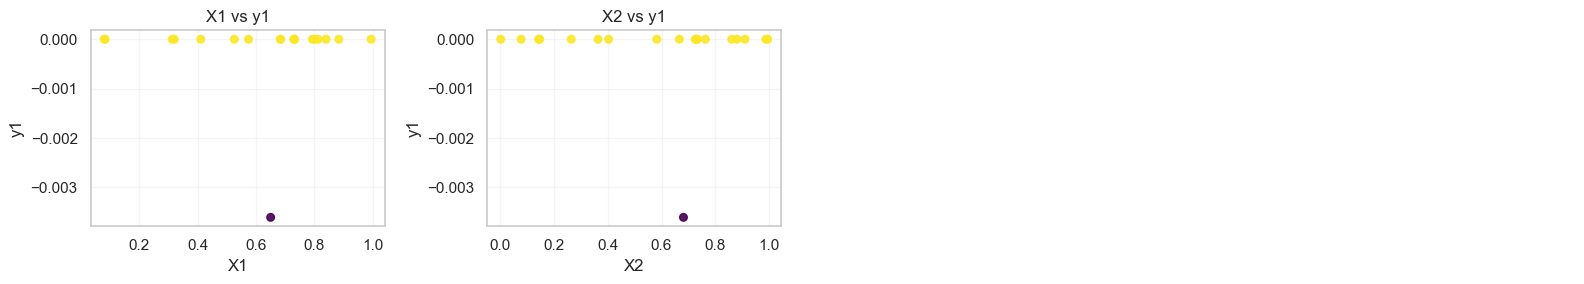

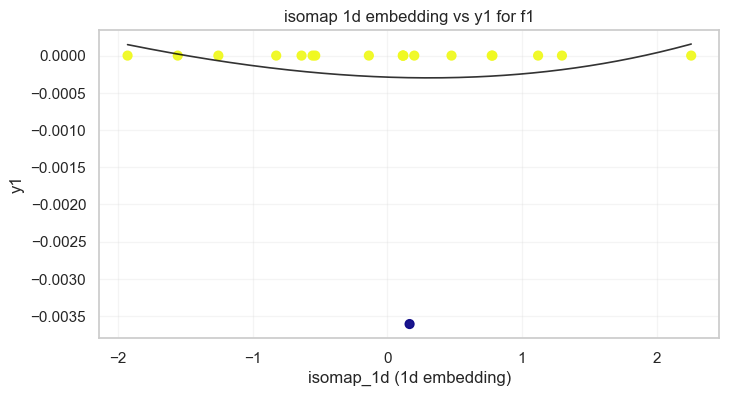

  isomap 1d: mean=0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    11: -1.9291, 0.0000
    14: -1.5564, -0.0000
    3: -1.2547, 0.0000
  highest isomap points (index, isomap, y):
    16: 1.1203, 0.0000
    0: 1.2975, 0.0000
    15: 2.2575, 0.0000

Feature vs Output Plots for f2
  isomap: computed 1d embedding with n_neighbors=8


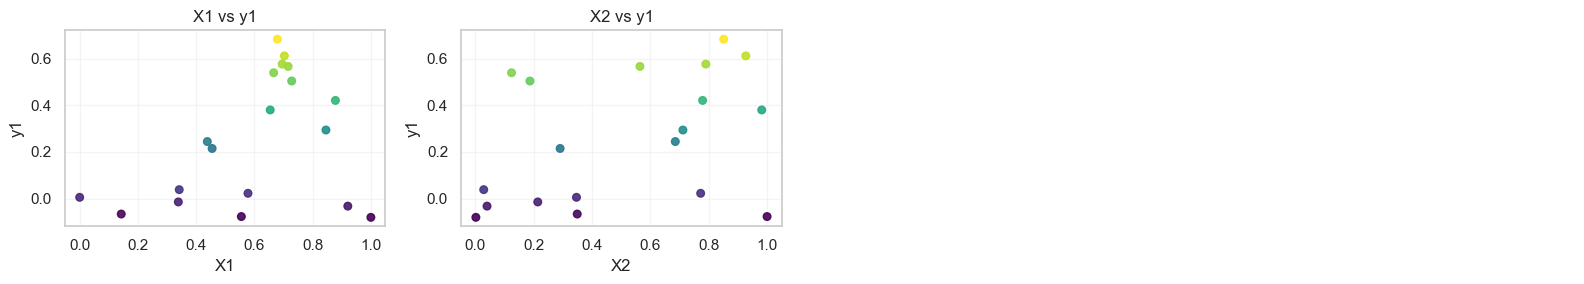

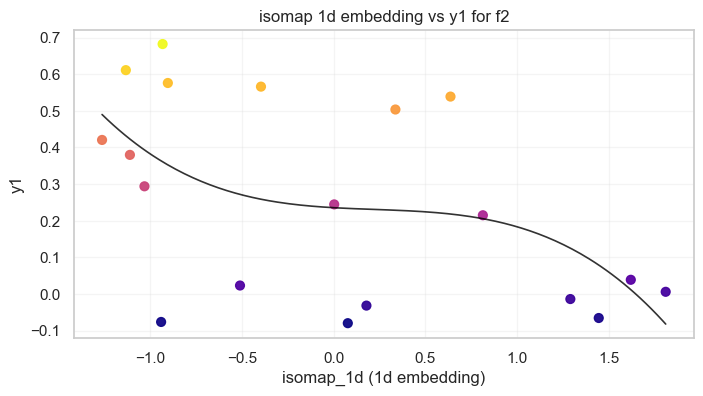

  isomap 1d: mean=-0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    1: -1.2608, 0.4206
    9: -1.1313, 0.6112
    15: -1.1091, 0.3798
  highest isomap points (index, isomap, y):
    2: 1.4443, -0.0656
    7: 1.6189, 0.0387
    16: 1.8089, 0.0059

Feature vs Output Plots for f3
  isomap: computed 1d embedding with n_neighbors=8


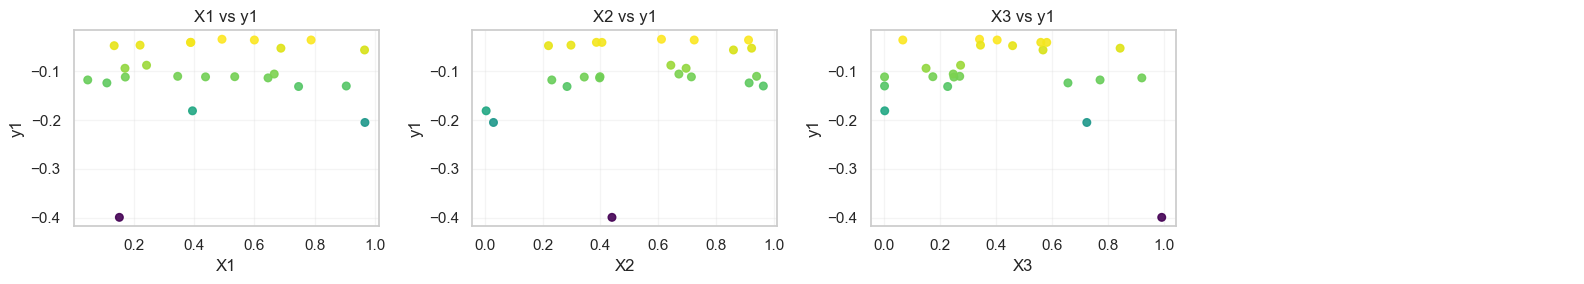

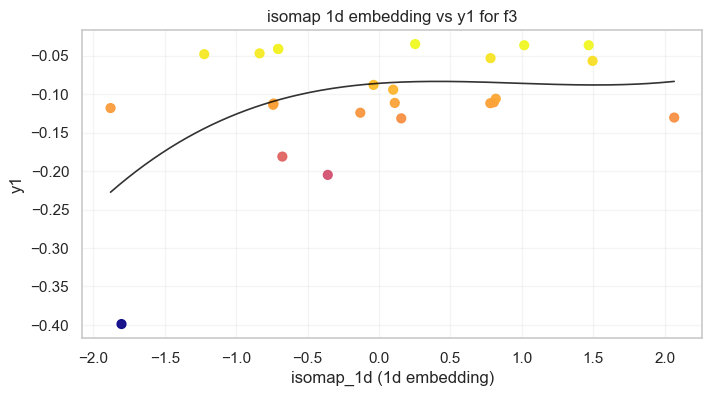

  isomap 1d: mean=0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    12: -1.8793, -0.1180
    6: -1.8027, -0.3989
    4: -1.2235, -0.0480
  highest isomap points (index, isomap, y):
    20: 1.4673, -0.0364
    14: 1.4944, -0.0568
    23: 2.0658, -0.1304

Feature vs Output Plots for f4
  isomap: computed 1d embedding with n_neighbors=8


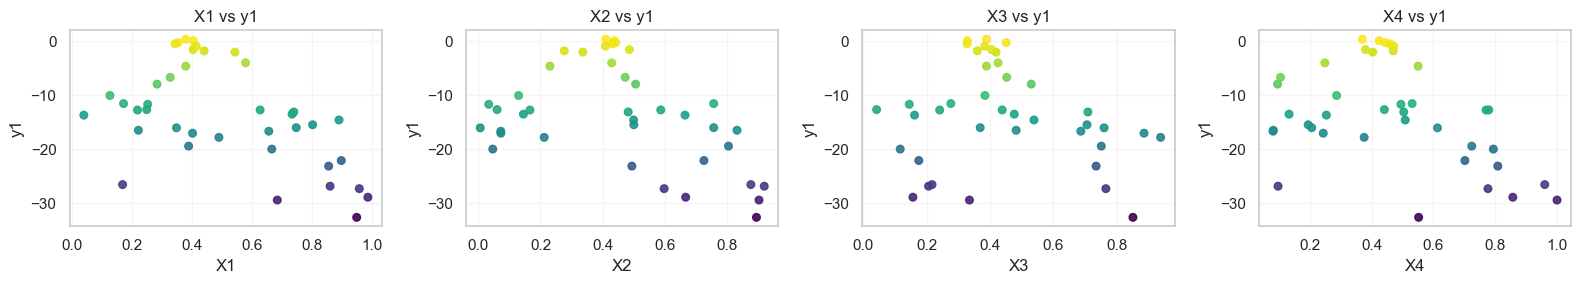

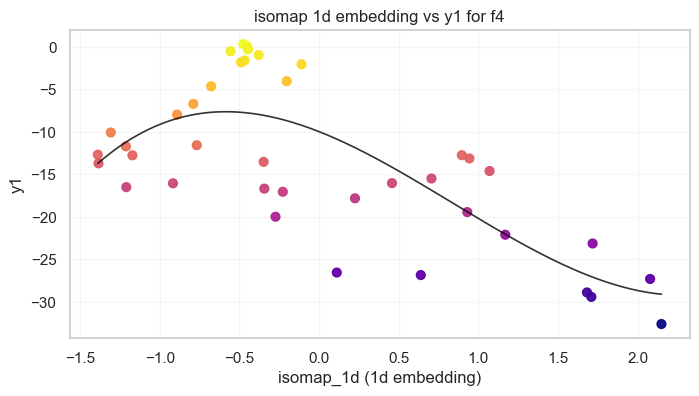

  isomap 1d: mean=-0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    6: -1.3886, -12.6817
    19: -1.3841, -13.7027
    4: -1.3073, -10.0696
  highest isomap points (index, isomap, y):
    29: 1.7170, -23.1394
    10: 2.0779, -27.3164
    25: 2.1490, -32.6257

Feature vs Output Plots for f5
  isomap: computed 1d embedding with n_neighbors=8


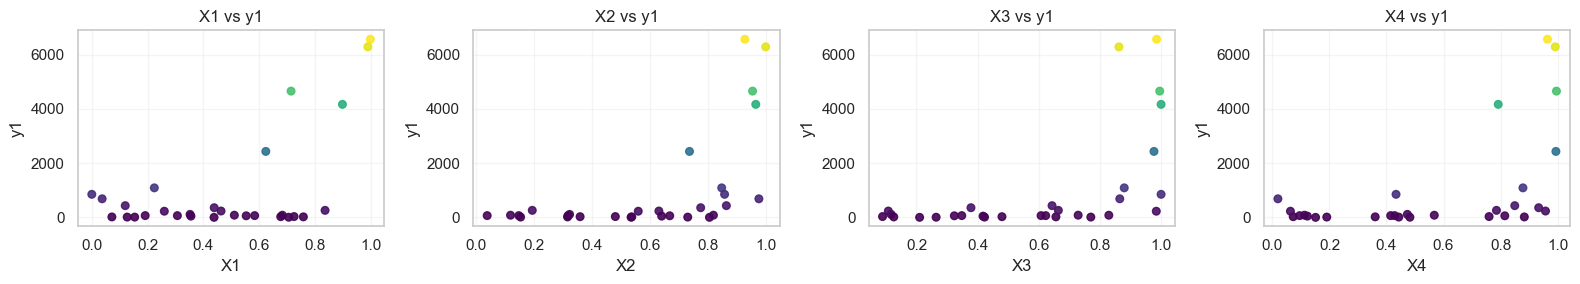

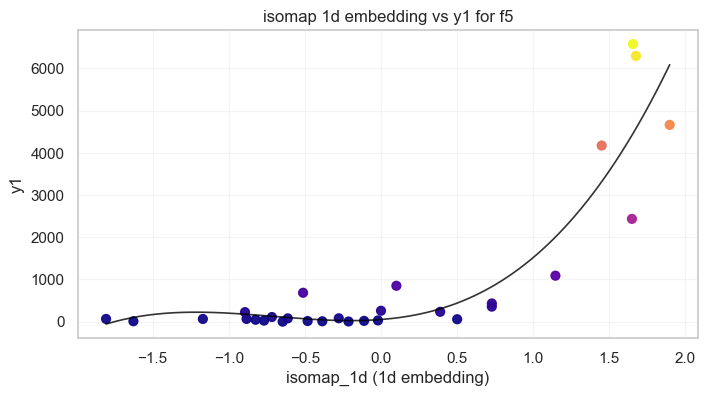

  isomap 1d: mean=0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    0: -1.8065, 64.4434
    19: -1.6268, 9.9723
    12: -1.1700, 63.4767
  highest isomap points (index, isomap, y):
    26: 1.6573, 6575.2960
    28: 1.6773, 6294.3245
    27: 1.8992, 4660.2441

Feature vs Output Plots for f6
  isomap: computed 1d embedding with n_neighbors=8


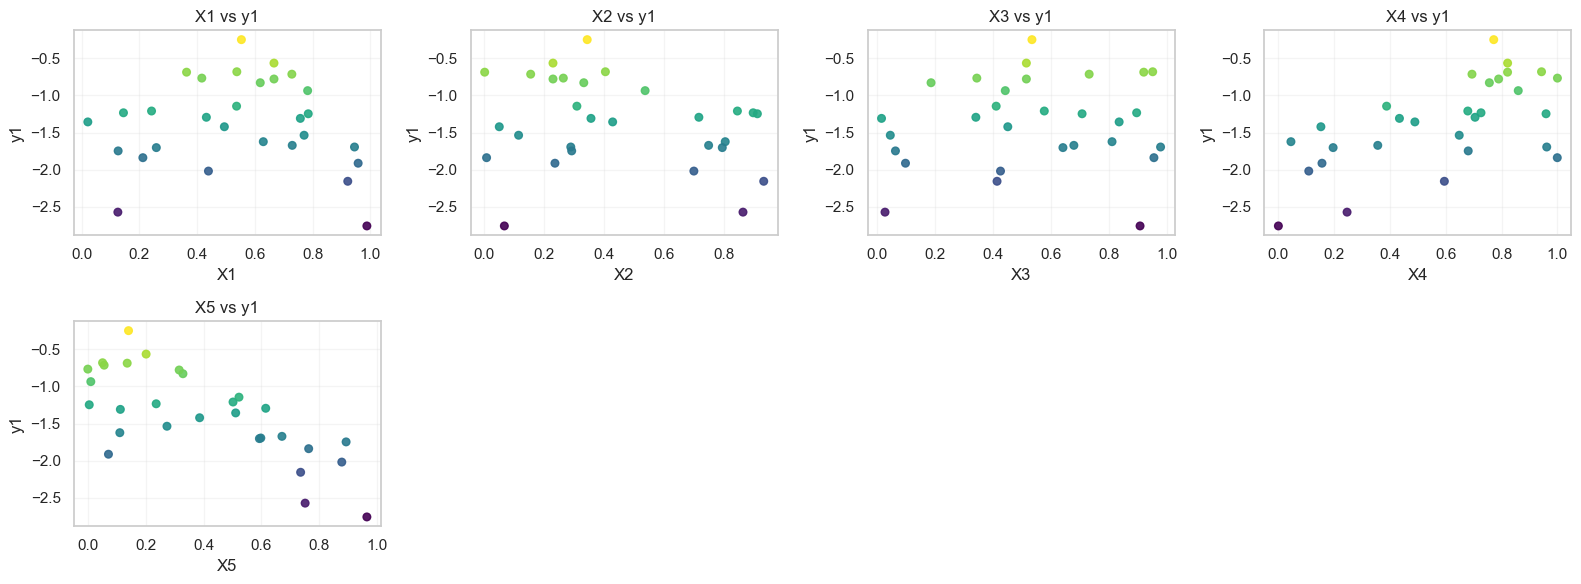

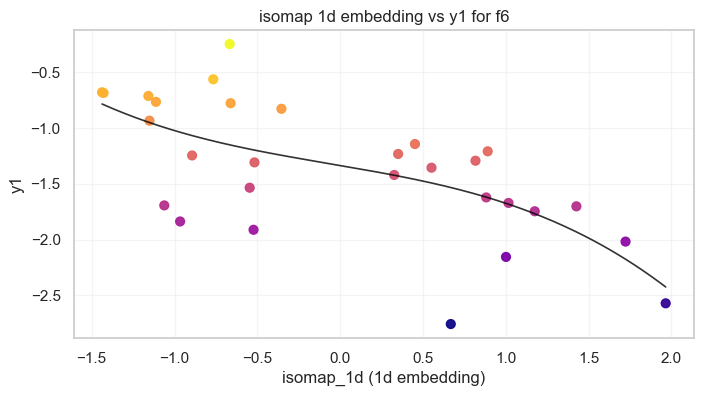

  isomap 1d: mean=0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    25: -1.4373, -0.6815
    20: -1.4279, -0.6872
    0: -1.1578, -0.7143
  highest isomap points (index, isomap, y):
    15: 1.4261, -1.7026
    14: 1.7228, -2.0184
    8: 1.9652, -2.5712

Feature vs Output Plots for f7
  isomap: computed 1d embedding with n_neighbors=8


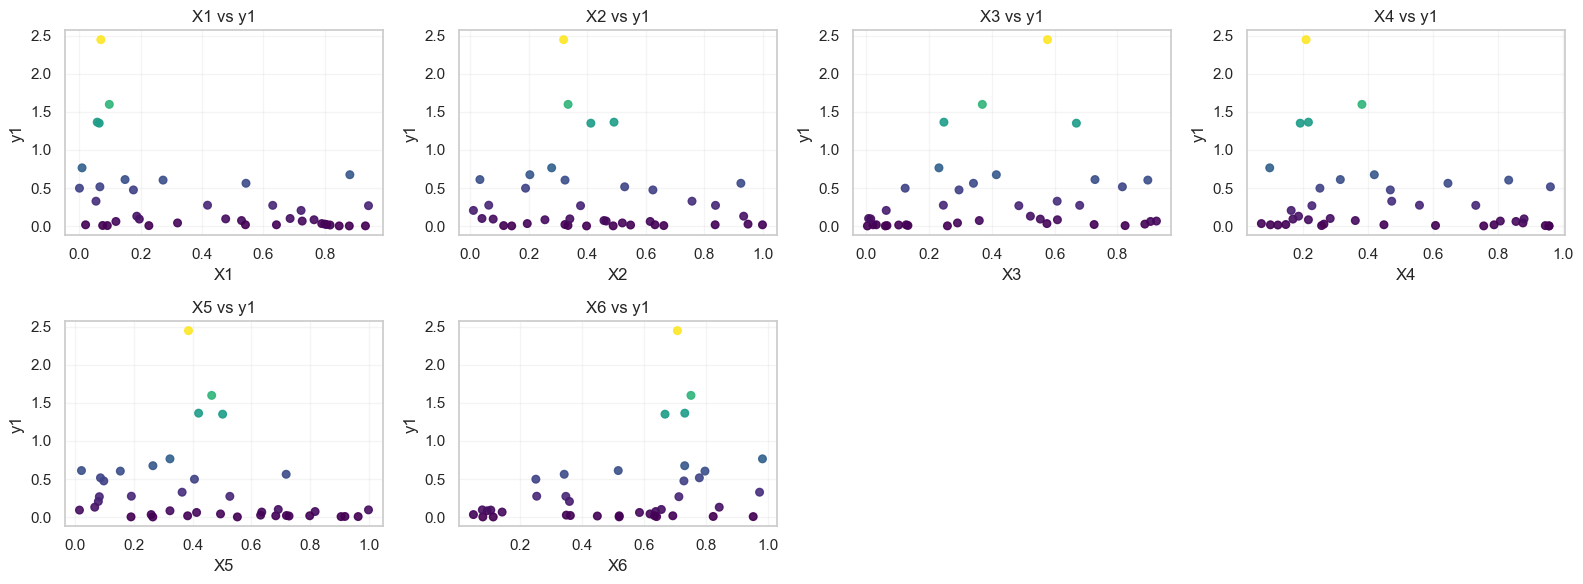

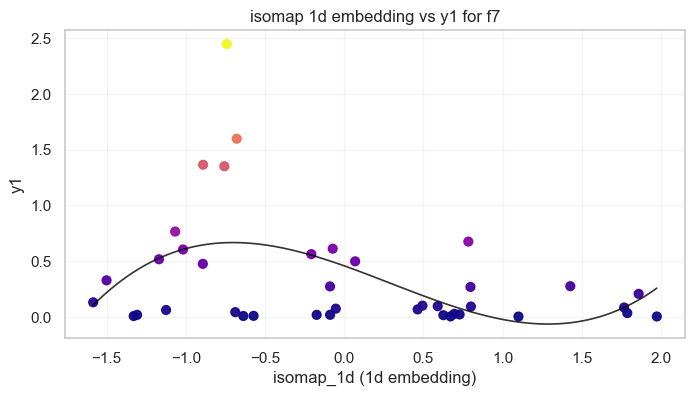

  isomap 1d: mean=-0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    37: -1.5846, 0.1305
    34: -1.5002, 0.3275
    21: -1.3287, 0.0070
  highest isomap points (index, isomap, y):
    9: 1.7876, 0.0336
    11: 1.8593, 0.2063
    27: 1.9740, 0.0031

Feature vs Output Plots for f8
  isomap: computed 1d embedding with n_neighbors=8


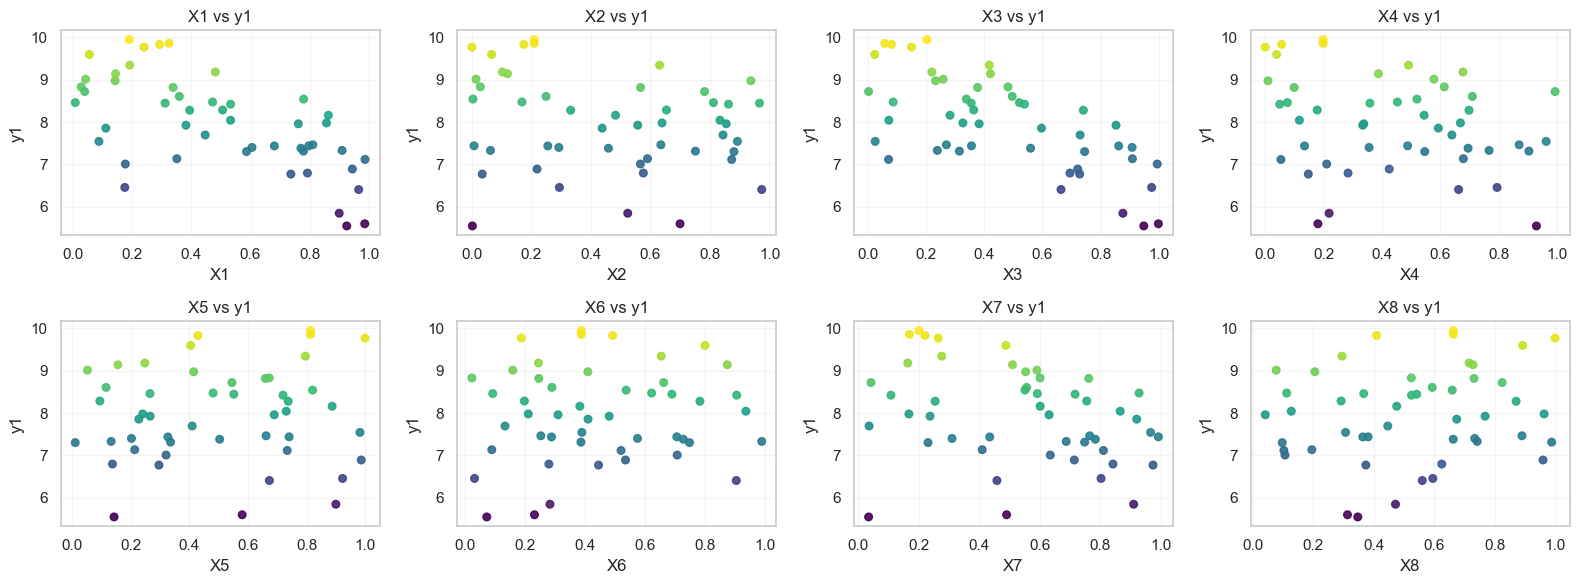

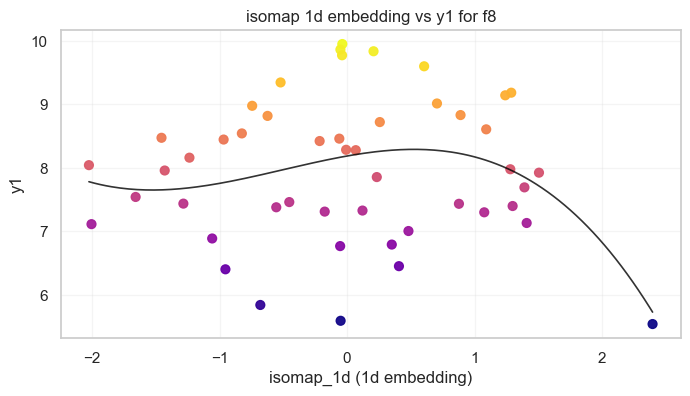

  isomap 1d: mean=-0.0000, std=1.0000
  lowest isomap points (index, isomap, y):
    28: -2.0234, 8.0422
    33: -2.0034, 7.1135
    45: -1.6574, 7.5414
  highest isomap points (index, isomap, y):
    16: 1.4075, 7.1316
    30: 1.5040, 7.9238
    44: 2.3943, 5.5408


In [23]:
from sklearn.manifold import Isomap
from sklearn.neighbors import kneighbors_graph

def compute_isomap_1d(X, n_neighbors=8):
    """
    compute a 1d isomap embedding for X.
    returns the 1d embedding (n,) and the fitted isomap object.
    """
    # standardise inputs to improve neighbour selection
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # fit isomap
    iso = Isomap(n_components=1, n_neighbors=n_neighbors)
    emb = iso.fit_transform(Xs).ravel()

    # standardise embedding for comparability
    emb = (emb - emb.mean()) / (emb.std() + 1e-12)
    return emb, iso, scaler

def run_isomap_on_functions(functions_data, n_neighbors=8):
    """
    loop through functions_data dict and compute isomap 1d embedding
    for each dataframe. produce feature vs output plots and an isomap
    coordinate vs output plot for visual inspection.
    """
    results = {}
    for name, df in functions_data.items():
        print(f"\nFeature vs Output Plots for {name}")


        # Extract input/output columns
        input_cols = [col for col in df.columns if col.startswith("X")]
        output_cols = [col for col in df.columns if col.startswith("y")]

        if len(input_cols) == 0 or len(output_cols) == 0:
            print("  skipping: dataframe missing expected X* or y columns")
            continue

        X = df[input_cols].values.astype(float)
        y = df[output_cols[0]].values.astype(float)


        # compute isomap 1d embedding
        try:
            isomap_1d, iso_model, scaler = compute_isomap_1d(X, n_neighbors=n_neighbors)
            print(f"  isomap: computed 1d embedding with n_neighbors={n_neighbors}")
        except Exception as e:
            print(f"  isomap: failed with {e}")
            isomap_1d = np.zeros(len(y))
            iso_model = None
            scaler = None

        # store results
        results[name] = {
            "isomap_1d": isomap_1d,
            "isomap_model": iso_model,
            "scaler": scaler,
            "input_cols": input_cols,
            "output_col": output_cols[0]
        }


        # plotting: feature vs y scatter for each input
        n_features = X.shape[1]
        ncols = 4
        nrows = int(np.ceil(n_features / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = axes.ravel()
        for j, col in enumerate(input_cols):
            ax = axes[j]
            sc = ax.scatter(X[:, j], y, c=y, cmap="viridis", s=30, alpha=0.9)
            ax.set_xlabel(col)
            ax.set_ylabel(output_cols[0])
            ax.set_title(f"{col} vs {output_cols[0]}")
            ax.grid(alpha=0.2)
        for k in range(n_features, len(axes)):
            axes[k].axis("off")
        plt.tight_layout()
        plt.show()


        # plotting: isomap coordinate vs y
        plt.figure(figsize=(8, 4))
        plt.scatter(isomap_1d, y, c=y, cmap="plasma", s=40, alpha=0.95)
        plt.xlabel("isomap_1d (1d embedding)")
        plt.ylabel(output_cols[0])
        plt.title(f"isomap 1d embedding vs {output_cols[0]} for {name}")
        plt.grid(alpha=0.2)

        # add a simple polynomial fit for visual guidance
        try:
            coeffs = np.polyfit(isomap_1d, y, 3)
            xs = np.linspace(isomap_1d.min(), isomap_1d.max(), 200)
            ys = np.polyval(coeffs, xs)
            plt.plot(xs, ys, color="black", linewidth=1.2, alpha=0.8)
        except Exception:
            pass

        plt.show()

        # print short numeric summary
        print(f"  isomap 1d: mean={isomap_1d.mean():.4f}, std={isomap_1d.std():.4f}")
        # show top and bottom points on the isomap axis for context
        order = np.argsort(isomap_1d)
        n_show = min(3, len(order))
        print("  lowest isomap points (index, isomap, y):")
        for idx in order[:n_show]:
            print(f"    {idx}: {isomap_1d[idx]:.4f}, {y[idx]:.4f}")
        print("  highest isomap points (index, isomap, y):")
        for idx in order[-n_show:]:
            print(f"    {idx}: {isomap_1d[idx]:.4f}, {y[idx]:.4f}")

    return results


results = run_isomap_on_functions(functions_data, n_neighbors=8)


#### Integrated Gradients



Feature vs Output Plots for f1


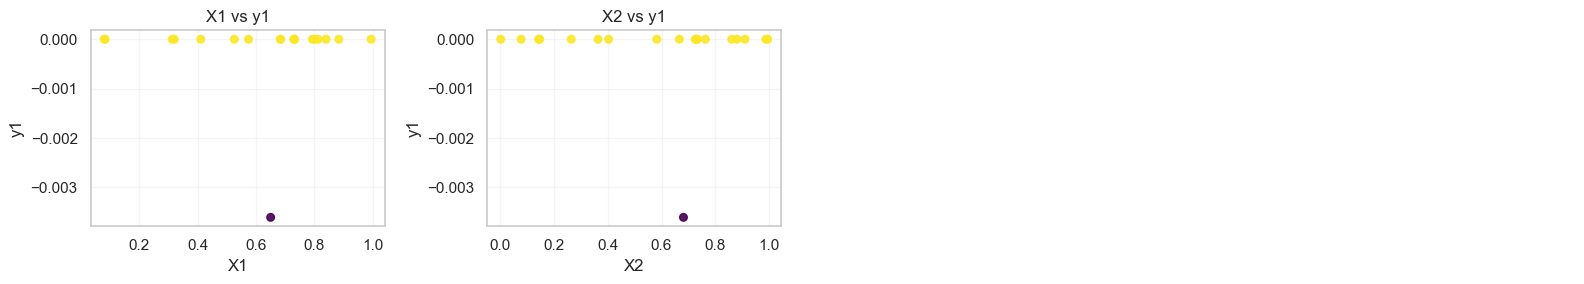

  integrated gradients: computed ig matrix and mean absolute importances


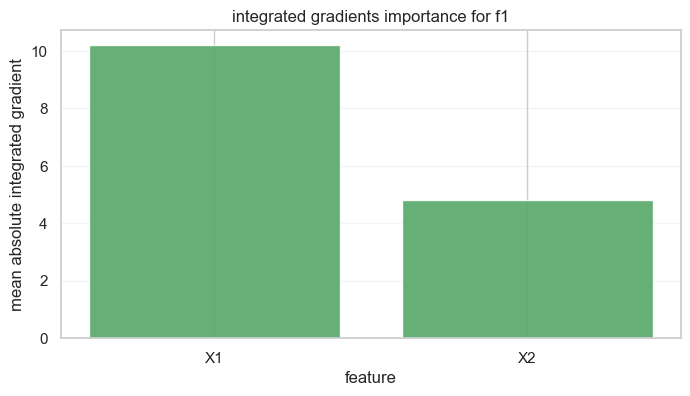

  top features by mean absolute ig:
    X1: 10.208330
    X2: 4.801024

Feature vs Output Plots for f2


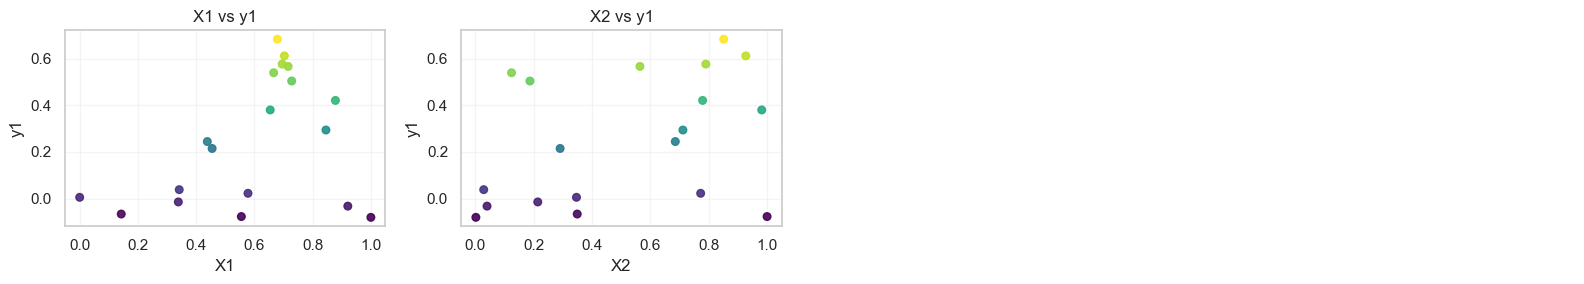

  integrated gradients: computed ig matrix and mean absolute importances


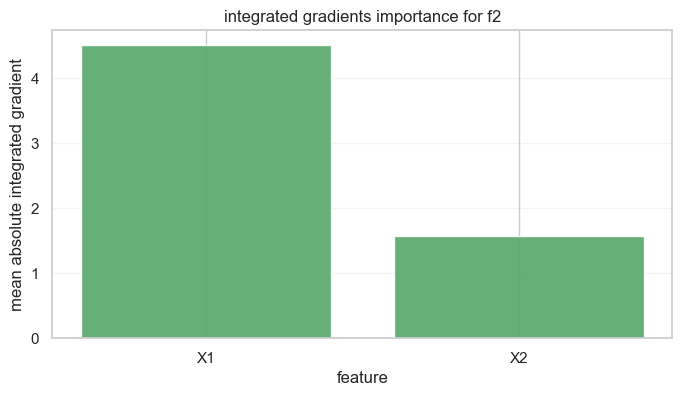

  top features by mean absolute ig:
    X1: 4.514818
    X2: 1.581352

Feature vs Output Plots for f3


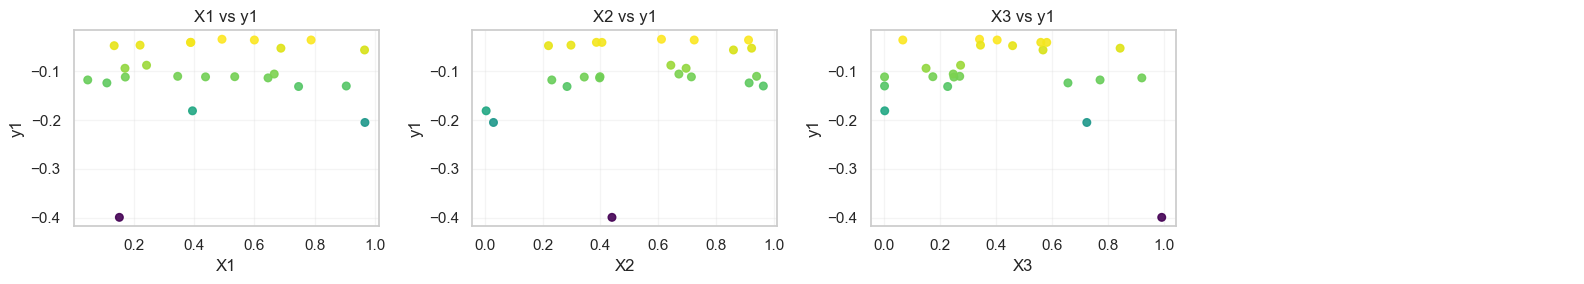

  integrated gradients: computed ig matrix and mean absolute importances


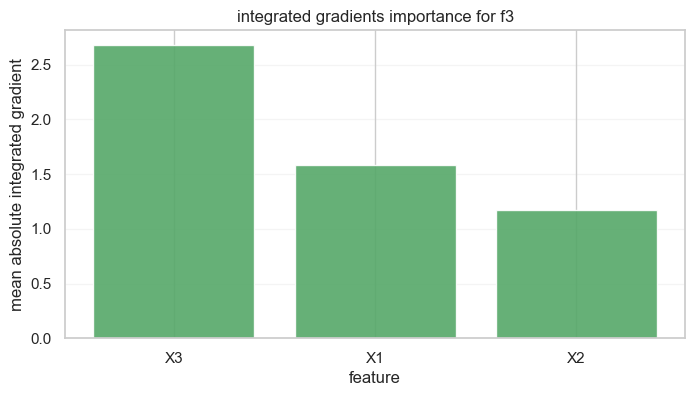

  top features by mean absolute ig:
    X3: 2.680108
    X1: 1.582592
    X2: 1.173937

Feature vs Output Plots for f4


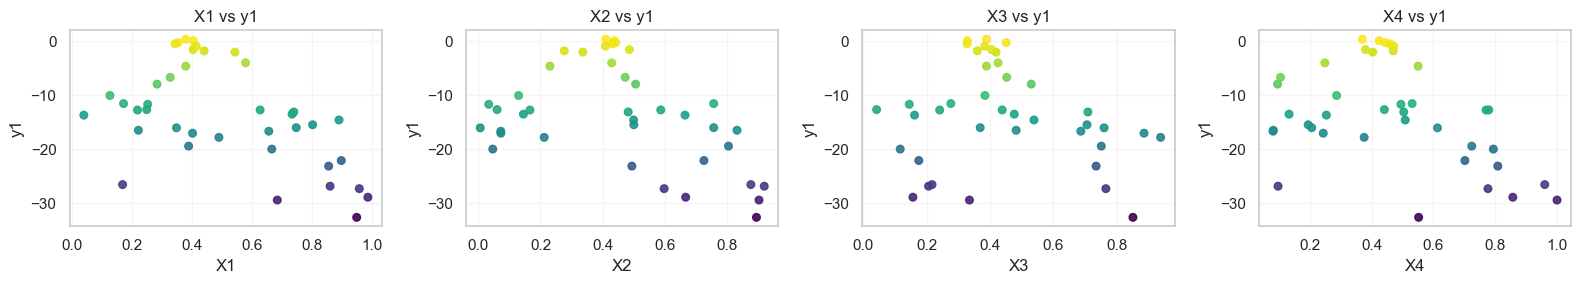

  integrated gradients: computed ig matrix and mean absolute importances


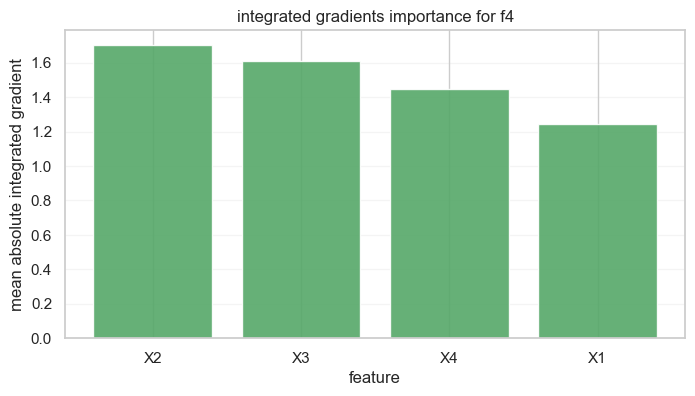

  top features by mean absolute ig:
    X2: 1.703337
    X3: 1.608417
    X4: 1.448782
    X1: 1.246720

Feature vs Output Plots for f5


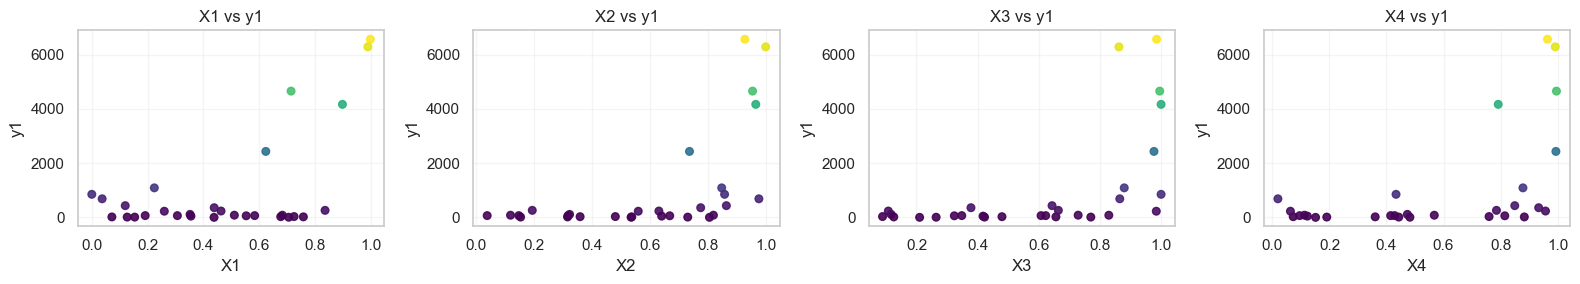

  integrated gradients: computed ig matrix and mean absolute importances


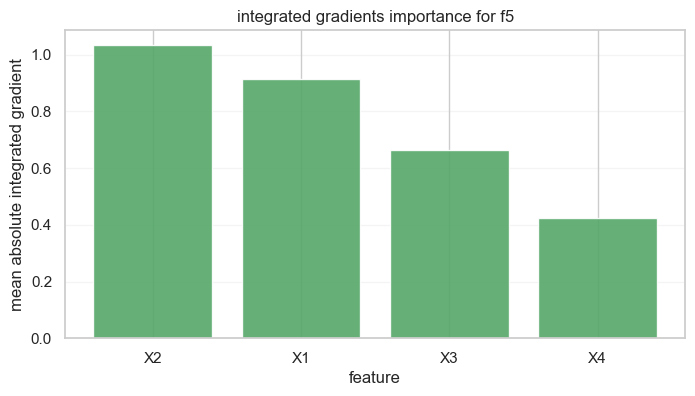

  top features by mean absolute ig:
    X2: 1.034261
    X1: 0.914137
    X3: 0.663393
    X4: 0.424235

Feature vs Output Plots for f6


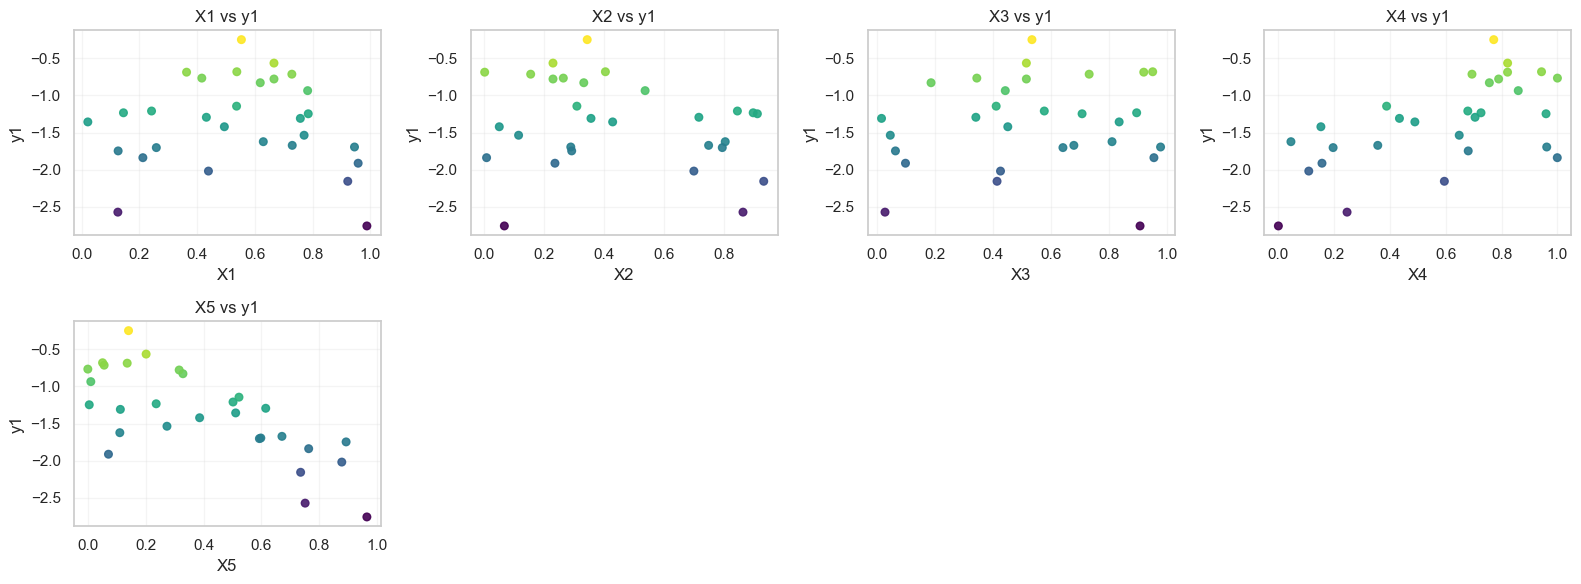

  integrated gradients: computed ig matrix and mean absolute importances


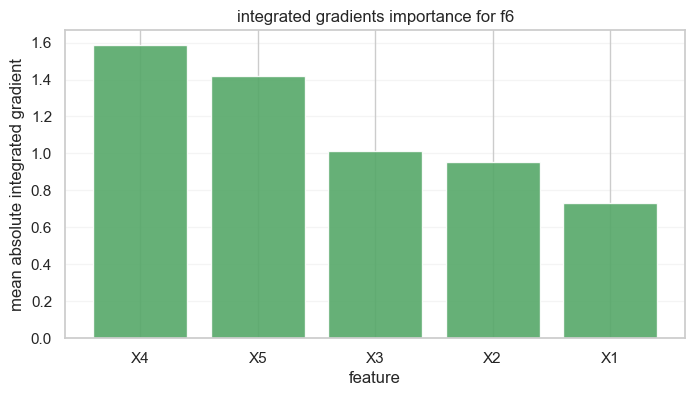

  top features by mean absolute ig:
    X4: 1.587177
    X5: 1.416757
    X3: 1.012478
    X2: 0.955001
    X1: 0.730208

Feature vs Output Plots for f7


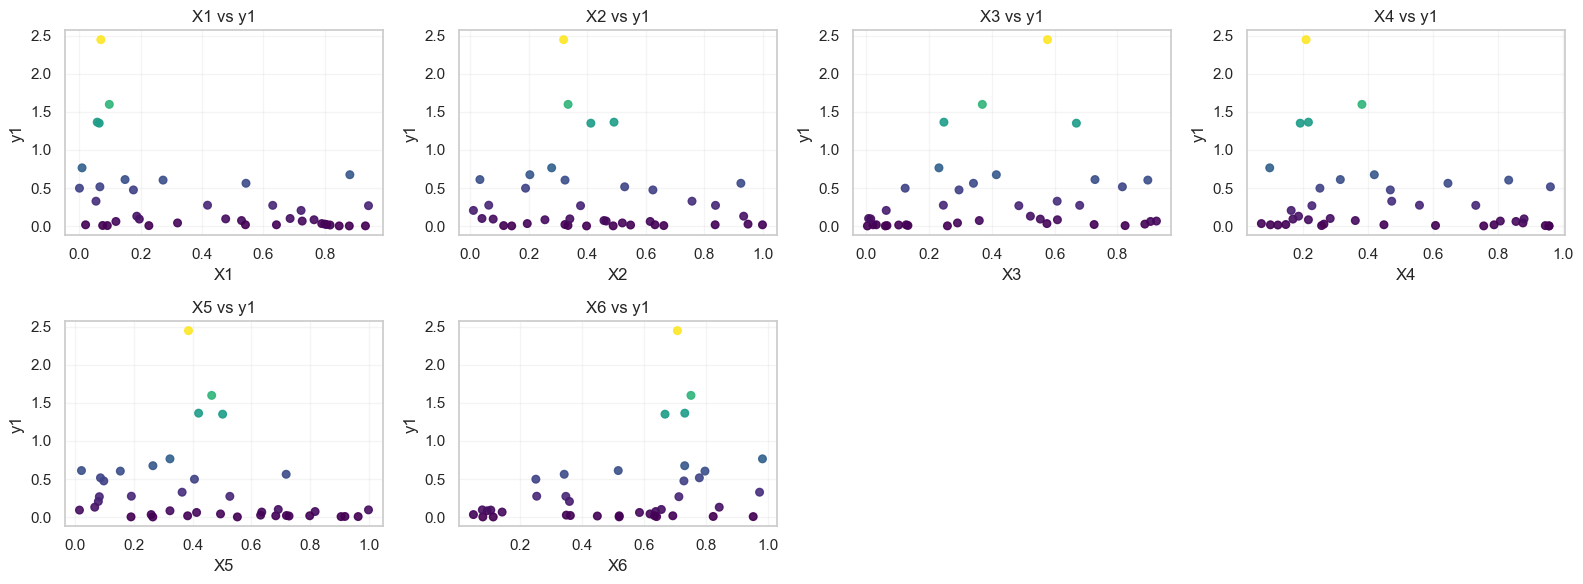

  integrated gradients: computed ig matrix and mean absolute importances


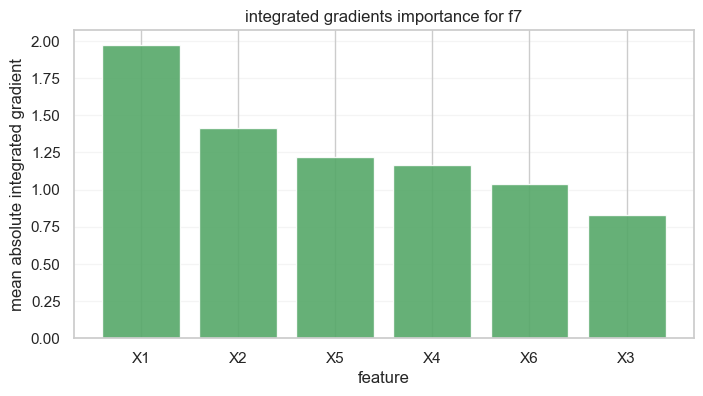

  top features by mean absolute ig:
    X1: 1.973432
    X2: 1.416658
    X5: 1.219275
    X4: 1.167409
    X6: 1.040628

Feature vs Output Plots for f8


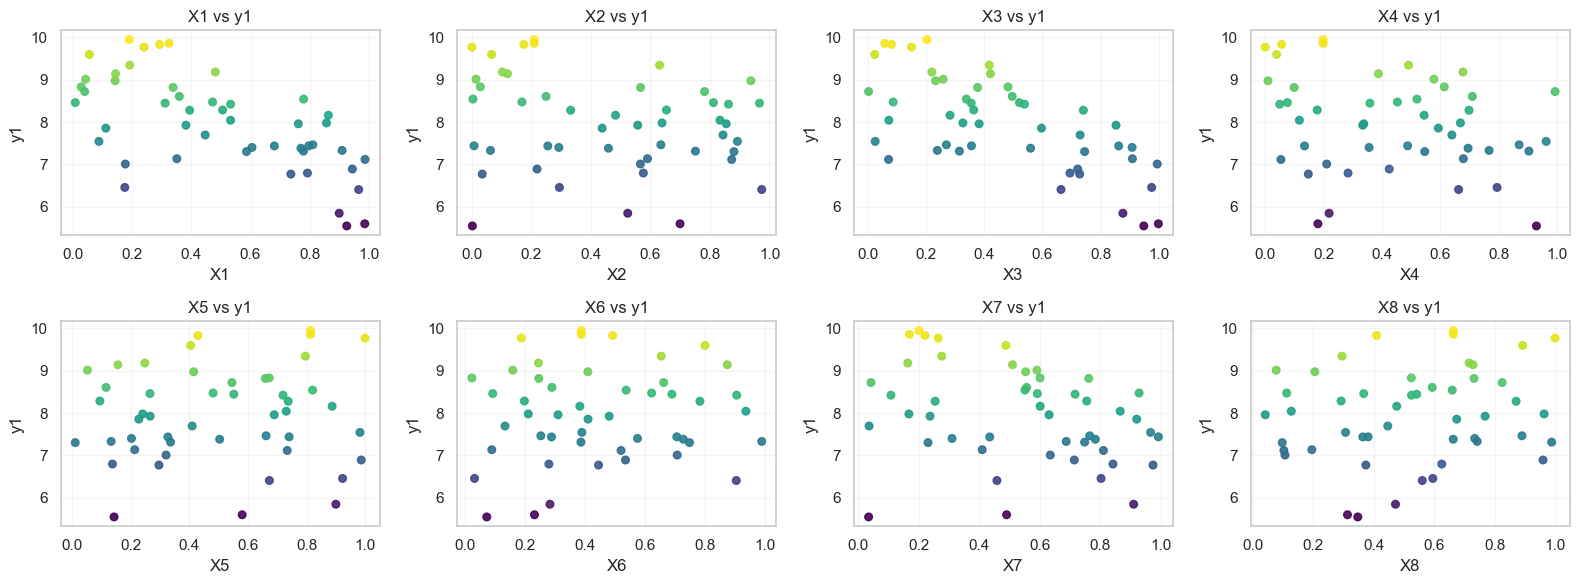

  integrated gradients: computed ig matrix and mean absolute importances


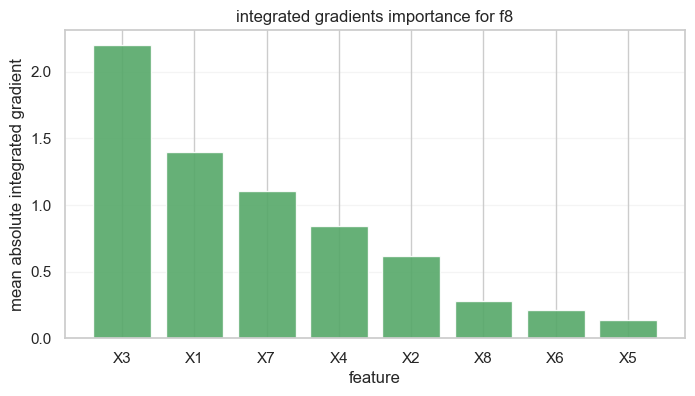

  top features by mean absolute ig:
    X3: 2.202022
    X1: 1.395099
    X7: 1.108283
    X4: 0.840377
    X2: 0.616106


In [24]:
from sklearn.neural_network import MLPRegressor
from sklearn.utils import check_random_state

# approximate gradient of a fitted sklearn mlp by central finite differences
def approx_grad_model(model, x, eps=1e-5):
    """
    approximate gradient of model.predict at point x using central finite differences.
    x is shape (p,) or (1, p). returns gradient shape (p,).
    """
    x = x.reshape(1, -1)
    p = x.shape[1]
    grad = np.zeros(p, dtype=float)
    for j in range(p):
        xp = x.copy()
        xm = x.copy()
        xp[0, j] += eps
        xm[0, j] -= eps
        fp = model.predict(xp).ravel()[0]
        fm = model.predict(xm).ravel()[0]
        grad[j] = (fp - fm) / (2 * eps)
    return grad

def integrated_gradients_for_point(model, x, baseline, m_steps=50, eps=1e-5):
    """
    compute integrated gradients for a single point x with baseline.
    model: fitted regressor with predict method
    x, baseline: 1d arrays shape (p,)
    m_steps: number of Riemann steps for the integral
    returns ig vector shape (p,)
    """
    p = x.size
    ig = np.zeros(p, dtype=float)
    # use m_steps points along the straightline path excluding alpha=0
    for k in range(1, m_steps + 1):
        alpha = k / m_steps
        xi = baseline + alpha * (x - baseline)
        grad = approx_grad_model(model, xi, eps=eps)
        ig += grad
    ig = (x - baseline) * (ig / m_steps)
    return ig

def compute_integrated_gradients_dataset(X, y, baseline=None, m_steps=50, random_state=0):
    """
    fit a small mlp surrogate to (X, y) and compute integrated gradients for each sample.
    returns:
      ig_matrix: shape (n, p) integrated gradients per sample
      ig_mean_abs: mean absolute ig per feature shape (p,)
      model: fitted surrogate
      baseline: baseline used
    notes:
      - with very small n the surrogate may be unstable; interpret results cautiously.
    """
    rng = check_random_state(random_state)
    n, p = X.shape

    # standardise inputs and outputs for stable surrogate training
    x_scaler = StandardScaler()
    Xs = x_scaler.fit_transform(X)

    y_mean = y.mean()
    y_std = y.std() if y.std() > 0 else 1.0
    ys = (y - y_mean) / y_std

    # fit a small mlp surrogate with modest capacity and regularisation
    model = MLPRegressor(hidden_layer_sizes=(32, 16),
                         activation="tanh",
                         alpha=1e-4,
                         max_iter=2000,
                         random_state=random_state)
    model.fit(Xs, ys)

    # choose baseline in original input space if not provided
    if baseline is None:
        baseline_orig = X.mean(axis=0)
    else:
        baseline_orig = np.asarray(baseline, dtype=float)

    # compute ig for each sample (work in original input space)
    ig_matrix = np.zeros((n, p), dtype=float)
    for i in range(n):
        x_orig = X[i].astype(float)
        # scale to model input space
        x_scaled = x_scaler.transform(x_orig.reshape(1, -1)).ravel()
        baseline_scaled = x_scaler.transform(baseline_orig.reshape(1, -1)).ravel()
        # compute integrated gradients in scaled space using the surrogate
        ig_scaled = integrated_gradients_for_point(model, x_scaled, baseline_scaled, m_steps=m_steps)
        # map ig back to original input scale: since ig is linear in x differences,
        # we convert by dividing by scale and adjusting sign accordingly
        # simpler approach: express ig in original units by dividing by x_scaler.scale_
        ig_orig = ig_scaled / (x_scaler.scale_ + 1e-12)
        ig_matrix[i] = ig_orig

    # aggregate importance: mean absolute integrated gradient per feature
    ig_mean_abs = np.mean(np.abs(ig_matrix), axis=0)
    return ig_matrix, ig_mean_abs, model, baseline_orig

# main loop over functions_data
def run_integrated_gradients_on_functions(functions_data, m_steps=50, random_state=0):
    """
    loop through functions_data dict and compute integrated gradients for each dataset.
    prints feature vs output plots and a bar chart of mean absolute integrated gradients.
    returns a results dict keyed by dataset name.
    """
    results = {}
    for name, df in functions_data.items():
        print(f"\nFeature vs Output Plots for {name}")


        # Extract input/output columns
        input_cols = [col for col in df.columns if col.startswith("X")]
        output_cols = [col for col in df.columns if col.startswith("y")]

        if len(input_cols) == 0 or len(output_cols) == 0:
            print("  skipping: dataframe missing expected X* or y columns")
            continue

        X = df[input_cols].values.astype(float)
        y = df[output_cols[0]].values.astype(float)


        # plot feature vs output scatter for each input
        n_features = X.shape[1]
        ncols = 4
        nrows = int(np.ceil(n_features / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = axes.ravel()
        for j, col in enumerate(input_cols):
            ax = axes[j]
            ax.scatter(X[:, j], y, c=y, cmap="viridis", s=30, alpha=0.9)
            ax.set_xlabel(col)
            ax.set_ylabel(output_cols[0])
            ax.set_title(f"{col} vs {output_cols[0]}")
            ax.grid(alpha=0.2)
        for k in range(n_features, len(axes)):
            axes[k].axis("off")
        plt.tight_layout()
        plt.show()


        # compute integrated gradients using a small surrogate
        try:
            ig_matrix, ig_mean_abs, model, baseline = compute_integrated_gradients_dataset(
                X, y, baseline=None, m_steps=m_steps, random_state=random_state
            )
            print("  integrated gradients: computed ig matrix and mean absolute importances")
        except Exception as e:
            print(f"  integrated gradients: failed with {e}")
            ig_matrix = np.zeros((X.shape[0], X.shape[1]))
            ig_mean_abs = np.zeros(X.shape[1])
            baseline = X.mean(axis=0)


        # plot mean absolute integrated gradients as a bar chart
        plt.figure(figsize=(8, 4))
        feat_names = input_cols
        yvals = ig_mean_abs
        order = np.argsort(yvals)[::-1]
        plt.bar([feat_names[i] for i in order], yvals[order], color="C2", alpha=0.9)
        plt.xlabel("feature")
        plt.ylabel("mean absolute integrated gradient")
        plt.title(f"integrated gradients importance for {name}")
        plt.grid(axis="y", alpha=0.2)
        plt.show()


        # store results and print short summary
        importance_table = list(zip(input_cols, ig_mean_abs))
        importance_table_sorted = sorted(importance_table, key=lambda t: -abs(t[1]))
        print("  top features by mean absolute ig:")
        for feat, val in importance_table_sorted[:5]:
            print(f"    {feat}: {val:.6f}")

        results[name] = {
            "input_cols": input_cols,
            "output_col": output_cols[0],
            "ig_matrix": ig_matrix,
            "ig_mean_abs": ig_mean_abs,
            "baseline": baseline
        }

    return results


results = run_integrated_gradients_on_functions(functions_data, m_steps=50, random_state=42)


#### Topological Data Analysis


Feature vs Output Plots for f1


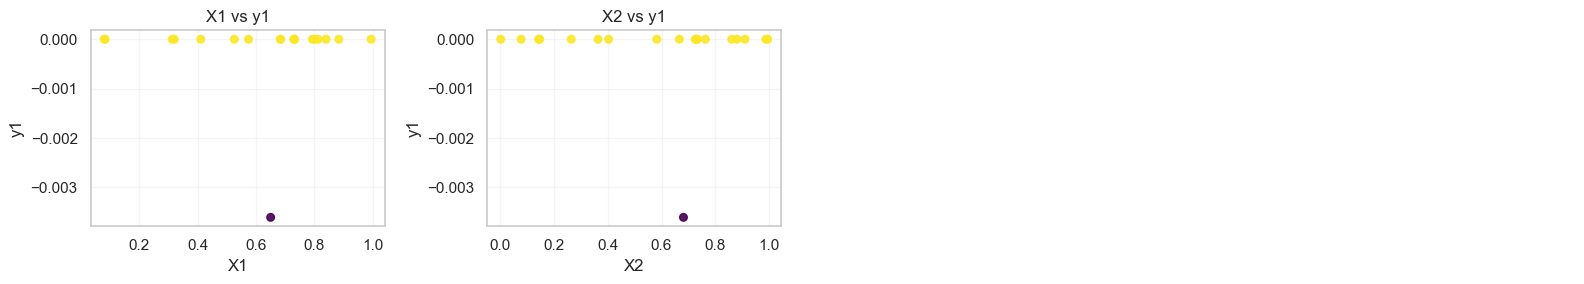

  mapper diagnostics: nodes=2, edges=0, connected_components=2
  node size: mean=7.50, min=1, max=14
  top nodes by max y (node, size, mean_y, max_y):
    node 1: size=14, mean_y=0.0000, max_y=0.0000
    node 0: size=1, mean_y=-0.0036, max_y=-0.0036


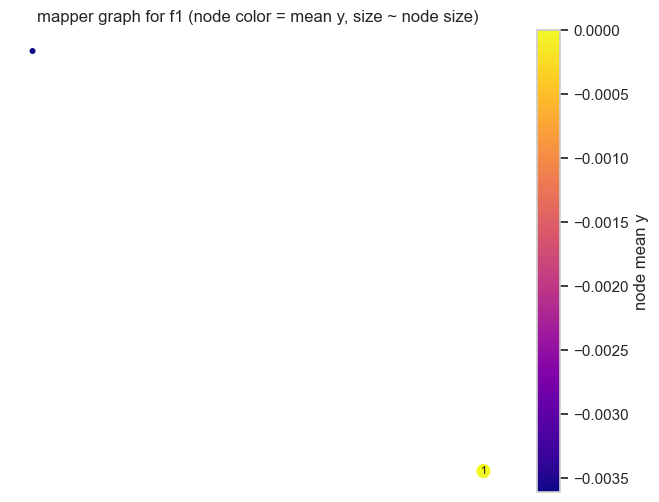


Feature vs Output Plots for f2


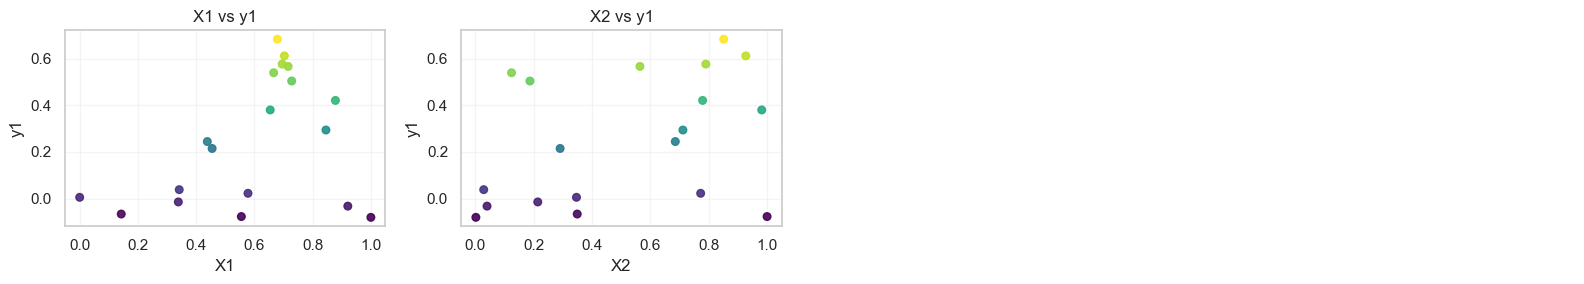

  mapper diagnostics: nodes=4, edges=0, connected_components=4
  node size: mean=2.00, min=1, max=3
  top nodes by max y (node, size, mean_y, max_y):
    node 3: size=3, mean_y=0.5845, max_y=0.6112
    node 2: size=1, mean_y=0.4206, max_y=0.4206
    node 1: size=1, mean_y=0.2940, max_y=0.2940
    node 0: size=3, mean_y=-0.0245, max_y=0.0059


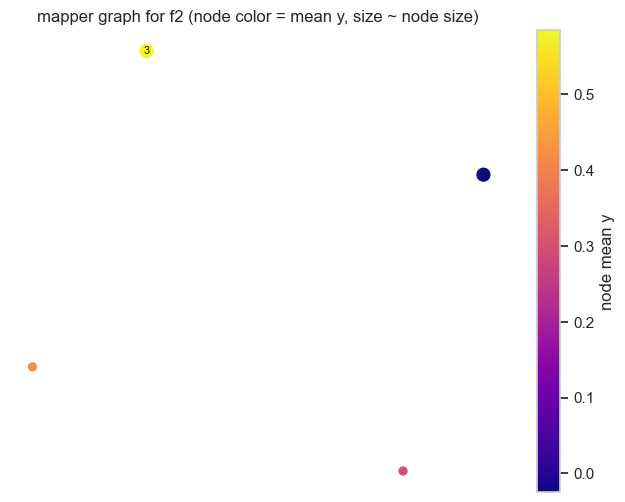


Feature vs Output Plots for f3


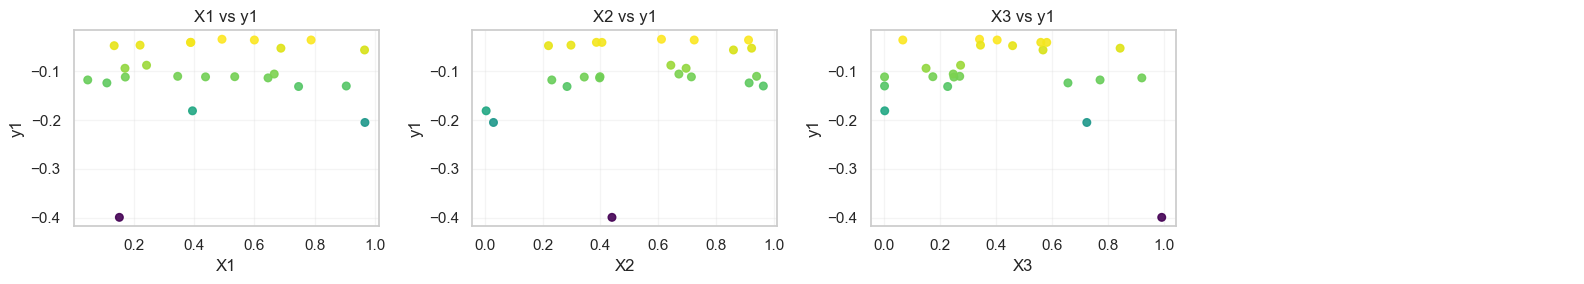

  mapper diagnostics: nodes=5, edges=0, connected_components=5
  node size: mean=3.60, min=1, max=7
  top nodes by max y (node, size, mean_y, max_y):
    node 3: size=6, mean_y=-0.0414, max_y=-0.0348
    node 4: size=3, mean_y=-0.0488, max_y=-0.0364
    node 2: size=7, mean_y=-0.1111, max_y=-0.0942
    node 1: size=1, mean_y=-0.1812, max_y=-0.1812
    node 0: size=1, mean_y=-0.3989, max_y=-0.3989


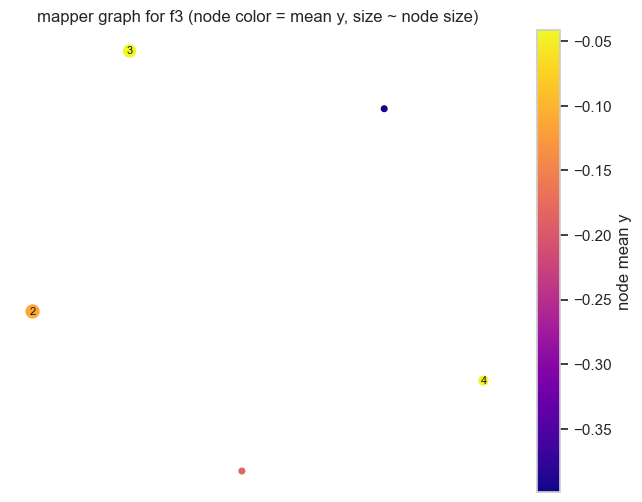


Feature vs Output Plots for f4


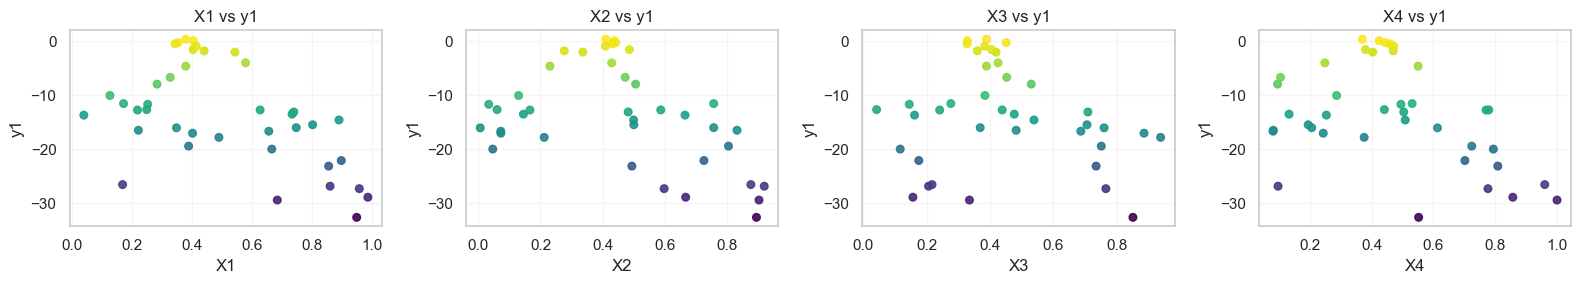

  mapper diagnostics: nodes=4, edges=1, connected_components=3
  node size: mean=5.50, min=3, max=7
  top nodes by max y (node, size, mean_y, max_y):
    node 3: size=7, mean_y=-1.0090, max_y=0.0705
    node 2: size=3, mean_y=-12.3800, max_y=-11.6999
    node 1: size=6, mean_y=-14.9074, max_y=-13.1228
    node 0: size=6, mean_y=-16.5189, max_y=-15.4871


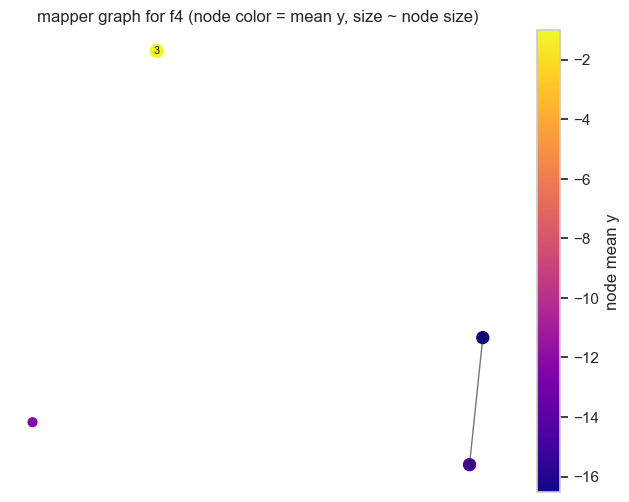


Feature vs Output Plots for f5


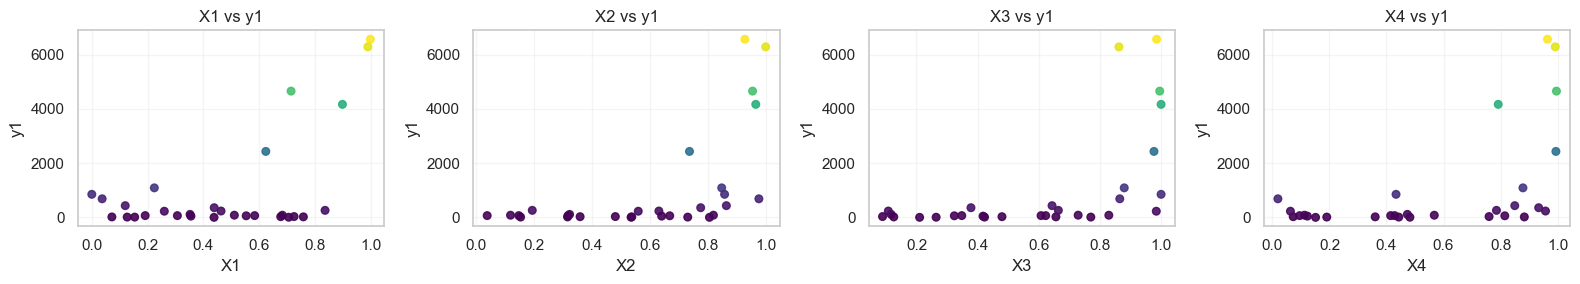

  mapper diagnostics: nodes=7, edges=2, connected_components=5
  node size: mean=4.29, min=1, max=22
  top nodes by max y (node, size, mean_y, max_y):
    node 6: size=1, mean_y=6294.3245, max_y=6294.3245
    node 5: size=1, mean_y=4660.2441, max_y=4660.2441
    node 4: size=1, mean_y=4171.1242, max_y=4171.1242
    node 3: size=1, mean_y=2434.3286, max_y=2434.3286
    node 2: size=1, mean_y=1088.8596, max_y=1088.8596


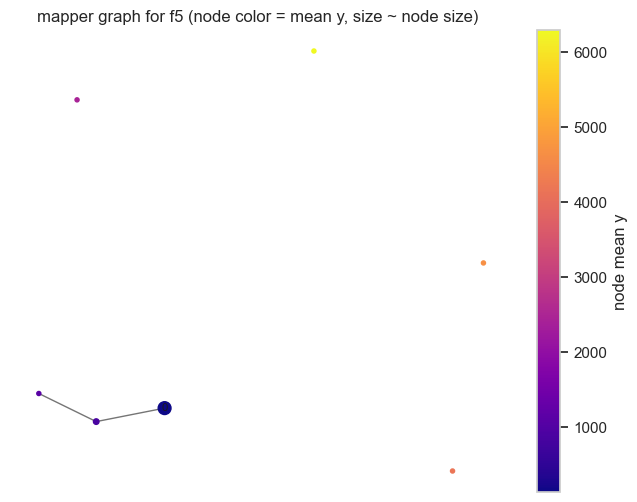


Feature vs Output Plots for f6


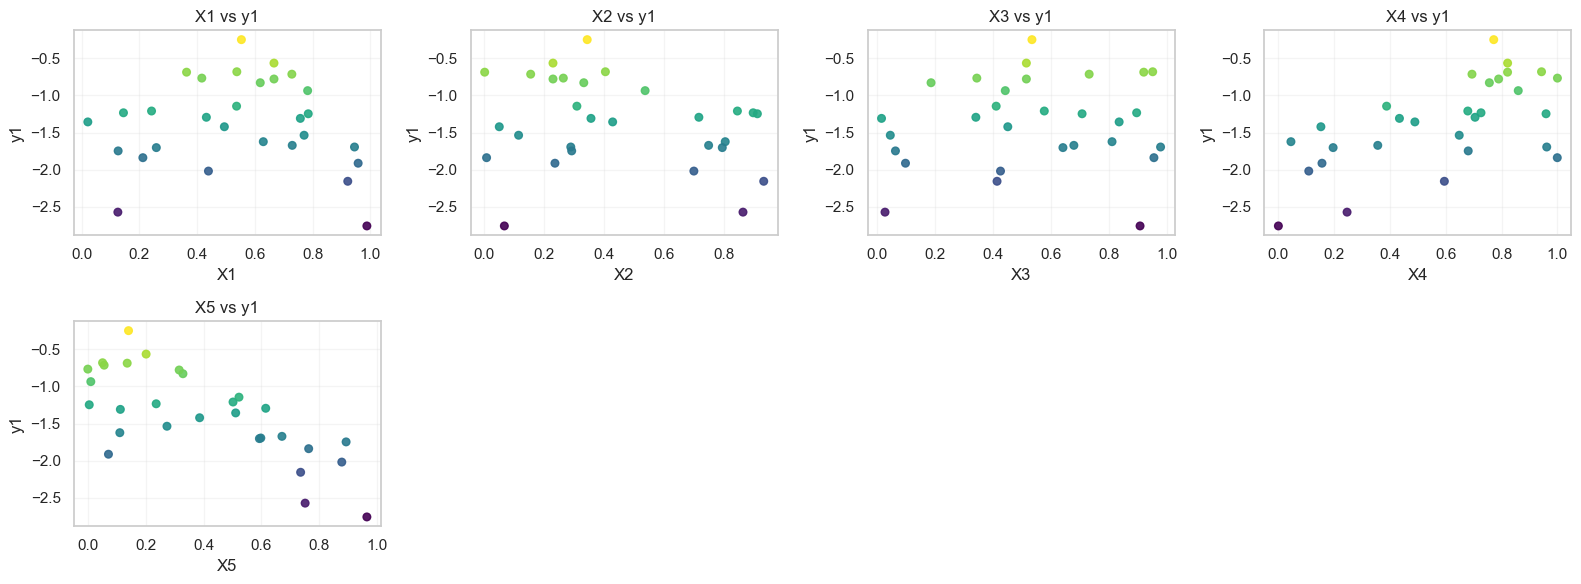

  mapper diagnostics: nodes=5, edges=1, connected_components=4
  node size: mean=4.20, min=1, max=7
  top nodes by max y (node, size, mean_y, max_y):
    node 4: size=4, mean_y=-0.6620, max_y=-0.5649
    node 3: size=7, mean_y=-0.7706, max_y=-0.6815
    node 2: size=6, mean_y=-1.2581, max_y=-1.1448
    node 1: size=3, mean_y=-1.6659, max_y=-1.6228
    node 0: size=1, mean_y=-2.1558, max_y=-2.1558


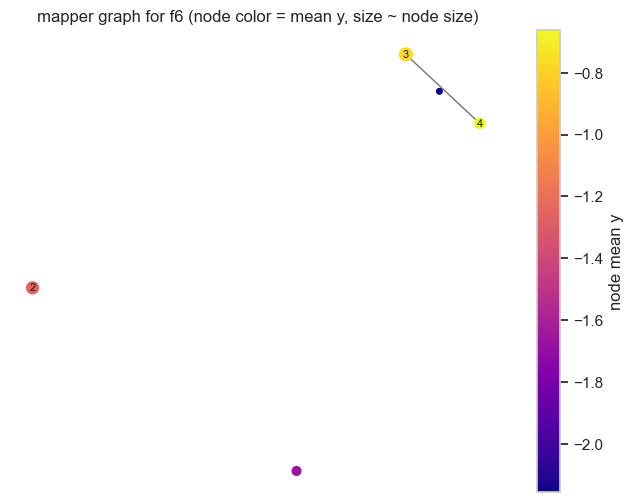


Feature vs Output Plots for f7


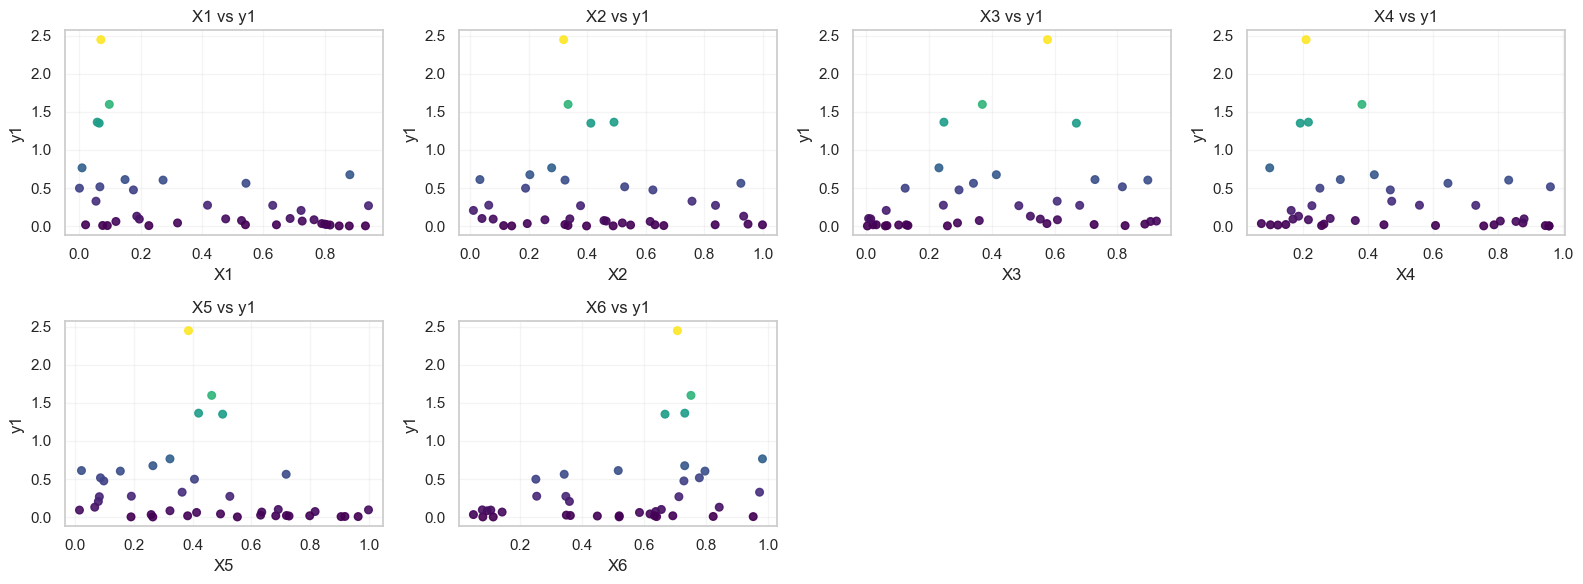

  mapper diagnostics: nodes=6, edges=2, connected_components=4
  node size: mean=5.67, min=1, max=24
  top nodes by max y (node, size, mean_y, max_y):
    node 5: size=1, mean_y=2.4483, max_y=2.4483
    node 4: size=1, mean_y=1.5985, max_y=1.5985
    node 3: size=1, mean_y=1.5985, max_y=1.5985
    node 2: size=4, mean_y=0.5520, max_y=0.6115
    node 1: size=3, mean_y=0.2499, max_y=0.2749


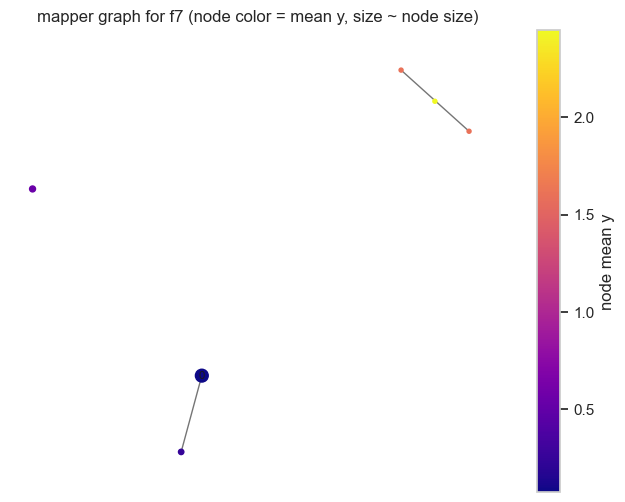


Feature vs Output Plots for f8


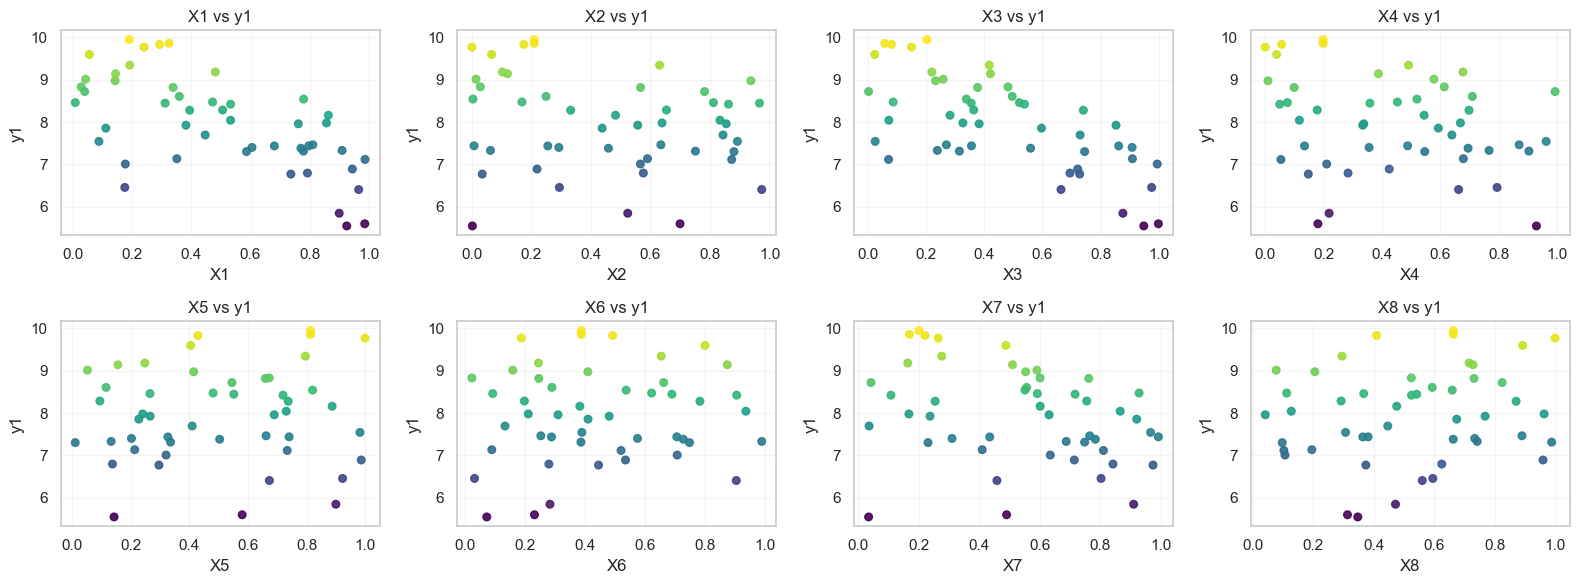

  mapper diagnostics: nodes=10, edges=6, connected_components=4
  node size: mean=5.70, min=1, max=10
  top nodes by max y (node, size, mean_y, max_y):
    node 9: size=5, mean_y=9.8031, max_y=9.9487
    node 8: size=6, mean_y=8.9938, max_y=9.1830
    node 7: size=6, mean_y=8.5968, max_y=8.8307
    node 6: size=9, mean_y=8.3450, max_y=8.5417
    node 4: size=3, mean_y=8.0534, max_y=8.1600


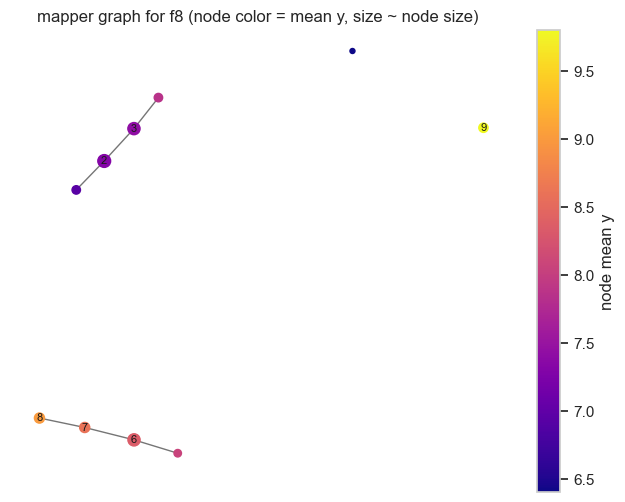

In [25]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import networkx as nx


# build mapper graph
def build_mapper_graph(X, filter_vals, n_intervals=10, overlap_frac=0.3,
                       cluster_eps=None, cluster_min_samples=3, cluster_method="dbscan"):
    """
    simple mapper implementation:
      - X: (n, p) input array
      - filter_vals: (n,) scalar filter per point (e.g., y or sir score)
      - n_intervals: number of overlapping intervals covering filter range
      - overlap_frac: fraction overlap between adjacent intervals (0..1)
      - cluster_eps: dbscan eps in feature space; if None, estimate from k-nearest distances
      - cluster_min_samples: dbscan min_samples
      - cluster_method: currently only 'dbscan' supported
    returns:
      G: networkx graph with node attributes:
         'indices' -> list of original point indices in the cluster
         'mean_y'  -> mean filter value (if filter is y) or mean y if provided separately
         'size'    -> number of points
      node_order: list of node keys in insertion order
    """
    n, p = X.shape
    fmin, fmax = float(filter_vals.min()), float(filter_vals.max())
    if fmax == fmin:
        # degenerate filter, add tiny jitter
        filter_vals = filter_vals + 1e-12 * np.random.RandomState(0).randn(n)

    # compute interval endpoints
    total_length = fmax - fmin
    if total_length == 0:
        total_length = 1.0
    interval_length = total_length / (n_intervals - (n_intervals - 1) * overlap_frac)
    step = interval_length * (1 - overlap_frac)
    intervals = []
    start = fmin
    for i in range(n_intervals):
        end = start + interval_length
        intervals.append((start, end))
        start = start + step

    # estimate dbscan eps if not provided using median k-distance
    if cluster_eps is None:
        # use 5-nearest neighbor distance median as heuristic
        k = min(5, max(1, int(np.sqrt(n))))
        nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
        dists, _ = nbrs.kneighbors(X)
        # exclude self-distance at column 0
        kth = dists[:, -1]
        cluster_eps = float(np.median(kth)) * 1.1 + 1e-12

    G = nx.Graph()
    node_id = 0
    node_map = []  # list of (interval_index, cluster_label, indices)

    for j, (a, b) in enumerate(intervals):
        # select points in interval [a, b]
        mask = (filter_vals >= a) & (filter_vals <= b)
        idxs = np.where(mask)[0]
        if idxs.size == 0:
            continue
        X_sub = X[idxs]

        # cluster the subcloud
        if cluster_method == "dbscan":
            if len(X_sub) == 1:
                labels = np.array([0])
            else:
                db = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples).fit(X_sub)
                labels = db.labels_
        else:
            raise ValueError("unsupported cluster_method")

        unique_labels = np.unique(labels)
        for lab in unique_labels:
            if lab == -1:
                # treat noise as singletons if desired; skip noise for clarity
                continue
            member_mask = labels == lab
            member_idxs = idxs[member_mask]
            if member_idxs.size == 0:
                continue
            # create node
            G.add_node(node_id)
            G.nodes[node_id]["indices"] = member_idxs.tolist()
            G.nodes[node_id]["size"] = int(member_idxs.size)
            # store mean filter value for diagnostics
            G.nodes[node_id]["mean_filter"] = float(filter_vals[member_idxs].mean())
            node_map.append((j, lab, node_id))
            node_id += 1

    # connect nodes that share original points
    # build inverted index: point -> nodes
    point_to_nodes = {}
    for nkey in G.nodes:
        for pt in G.nodes[nkey]["indices"]:
            point_to_nodes.setdefault(pt, []).append(nkey)

    # add edges for nodes that share at least one point
    for pt, nodes in point_to_nodes.items():
        if len(nodes) > 1:
            for i in range(len(nodes)):
                for j in range(i + 1, len(nodes)):
                    u, v = nodes[i], nodes[j]
                    if not G.has_edge(u, v):
                        G.add_edge(u, v)

    return G


# main loop over functions_data
def run_mapper_on_functions(functions_data,
                            n_intervals=12,
                            overlap_frac=0.35,
                            cluster_min_samples=3,
                            cluster_eps=None,
                            plot_graph=True):
    """
    loop through functions_data dict and compute mapper graph for each dataset.
    prints diagnostics and plots feature vs output and mapper graph.
    """
    results = {}
    for name, df in functions_data.items():
        print(f"\nFeature vs Output Plots for {name}")

     
        # Extract input/output columns
        input_cols = [col for col in df.columns if col.startswith("X")]
        output_cols = [col for col in df.columns if col.startswith("y")]

        if len(input_cols) == 0 or len(output_cols) == 0:
            print("  skipping: dataframe missing expected X* or y columns")
            continue

        X = df[input_cols].values.astype(float)
        y = df[output_cols[0]].values.astype(float)


        # quick feature vs output plots
        n_features = X.shape[1]
        ncols = 4
        nrows = int(np.ceil(n_features / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = axes.ravel()
        for j, col in enumerate(input_cols):
            ax = axes[j]
            sc = ax.scatter(X[:, j], y, c=y, cmap="viridis", s=30, alpha=0.9)
            ax.set_xlabel(col)
            ax.set_ylabel(output_cols[0])
            ax.set_title(f"{col} vs {output_cols[0]}")
            ax.grid(alpha=0.2)
        for k in range(n_features, len(axes)):
            axes[k].axis("off")
        plt.tight_layout()
        plt.show()


        # build mapper graph using y as filter
        filter_vals = y.copy()  # use response as filter; replace with sir/isomap if desired
        G = build_mapper_graph(X, filter_vals,
                               n_intervals=n_intervals,
                               overlap_frac=overlap_frac,
                               cluster_eps=cluster_eps,
                               cluster_min_samples=cluster_min_samples)


        # numerical diagnostics
        n_nodes = G.number_of_nodes()
        n_edges = G.number_of_edges()
        n_components = nx.number_connected_components(G)
        node_sizes = np.array([G.nodes[n]["size"] for n in G.nodes]) if n_nodes > 0 else np.array([])
        mean_filters = np.array([G.nodes[n]["mean_filter"] for n in G.nodes]) if n_nodes > 0 else np.array([])

        print(f"  mapper diagnostics: nodes={n_nodes}, edges={n_edges}, connected_components={n_components}")
        if n_nodes > 0:
            print(f"  node size: mean={node_sizes.mean():.2f}, min={node_sizes.min():.0f}, max={node_sizes.max():.0f}")
            # compute node-level y statistics (max y in node)
            node_max_y = []
            node_mean_y = []
            for nkey in G.nodes:
                idxs = G.nodes[nkey]["indices"]
                node_max_y.append(float(y[idxs].max()))
                node_mean_y.append(float(y[idxs].mean()))
            node_max_y = np.array(node_max_y)
            node_mean_y = np.array(node_mean_y)
            # top nodes by max y
            top_idx = np.argsort(node_max_y)[::-1][:5]
            print("  top nodes by max y (node, size, mean_y, max_y):")
            for t in top_idx:
                nkey = list(G.nodes)[t]
                print(f"    node {nkey}: size={G.nodes[nkey]['size']}, mean_y={node_mean_y[t]:.4f}, max_y={node_max_y[t]:.4f}")


        # plot mapper graph with node color = mean y and size = node size
        if plot_graph and n_nodes > 0:
            plt.figure(figsize=(8, 6))
            pos = nx.spring_layout(G, seed=0)  # layout for visualization
            # node colors and sizes
            node_colors = [np.mean(y[G.nodes[n]["indices"]]) for n in G.nodes]
            node_sizes_plot = [5 + 80 * (G.nodes[n]["size"] / (node_sizes.max() if node_sizes.size else 1)) for n in G.nodes]
            nodes = nx.draw_networkx_nodes(G, pos,
                                           node_color=node_colors,
                                           cmap="plasma",
                                           node_size=node_sizes_plot)
            nx.draw_networkx_edges(G, pos, alpha=0.6)
            # label top nodes by max y
            labels = {}
            for n in G.nodes:
                labels[n] = f"{n}"
            nx.draw_networkx_labels(G, pos, labels={n: labels[n] for n in G.nodes if G.nodes[n]["size"] >= max(2, int(node_sizes.mean()))},
                                    font_size=8)
            plt.colorbar(nodes, label="node mean y")
            plt.title(f"mapper graph for {name} (node color = mean y, size ~ node size)")
            plt.axis("off")
            plt.show()

        # store results
        results[name] = {
            "graph": G,
            "filter_vals": filter_vals,
            "input_cols": input_cols,
            "output_col": output_cols[0]
        }

    return results


results = run_mapper_on_functions(functions_data,
                                 n_intervals=12,
                                 overlap_frac=0.35,
                                 cluster_min_samples=3,
                                 cluster_eps=None,
                                 plot_graph=True)

#### Distribution Analysis


f1 — Feature & Output Distributions


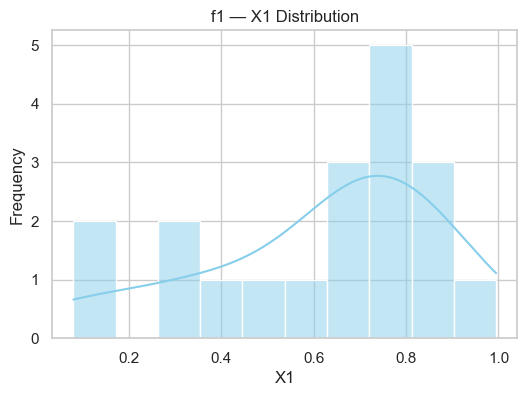

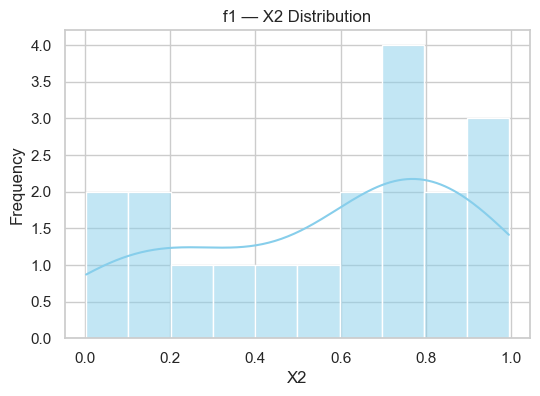

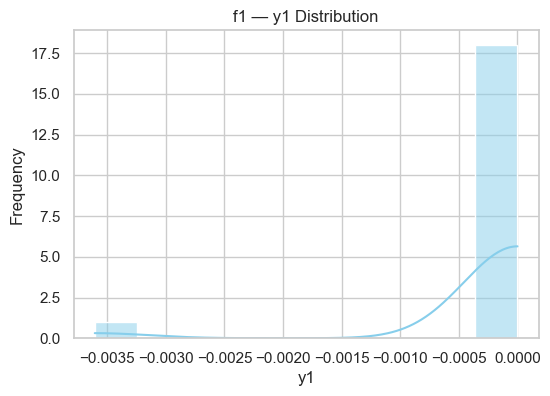


f2 — Feature & Output Distributions


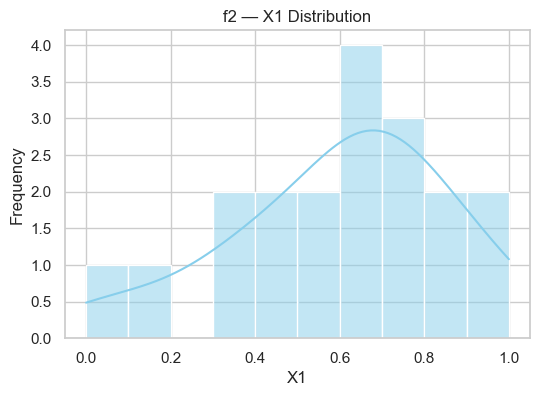

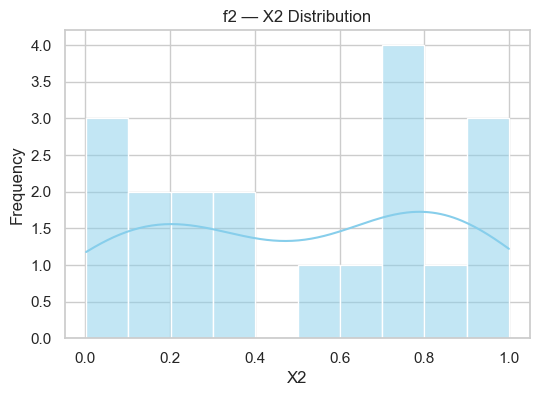

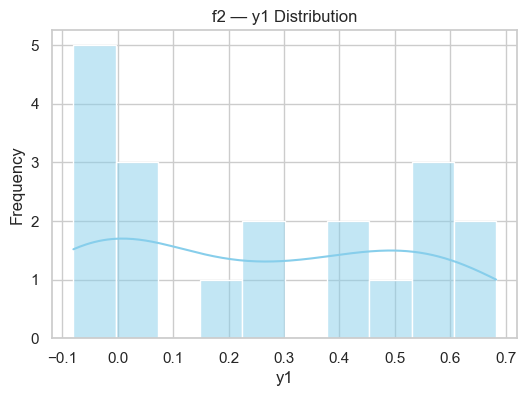


f3 — Feature & Output Distributions


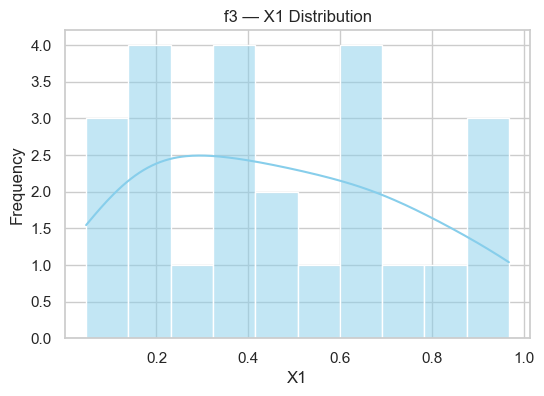

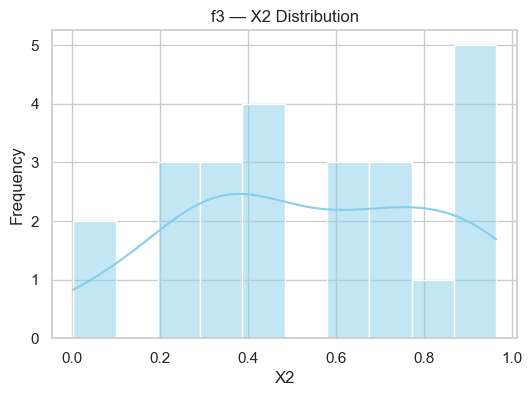

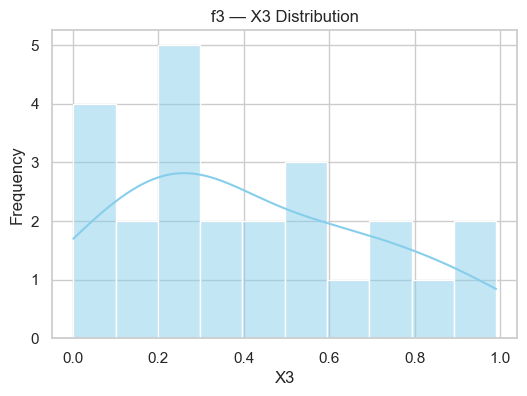

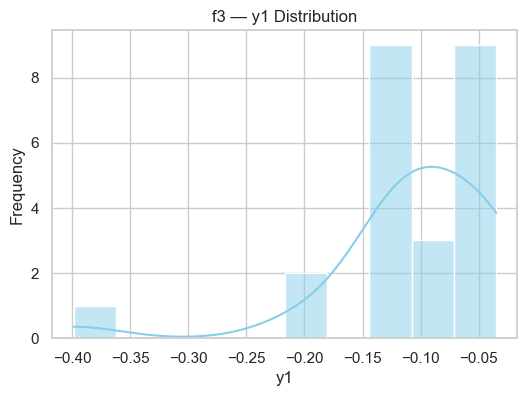


f4 — Feature & Output Distributions


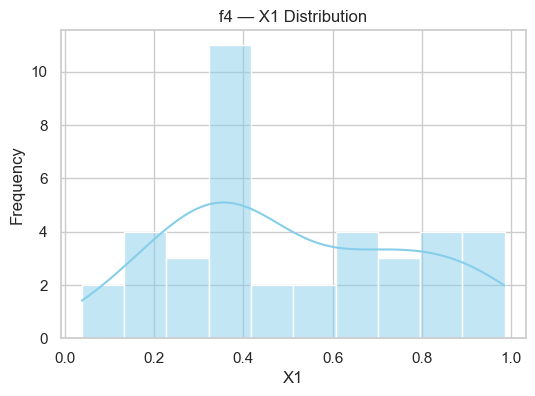

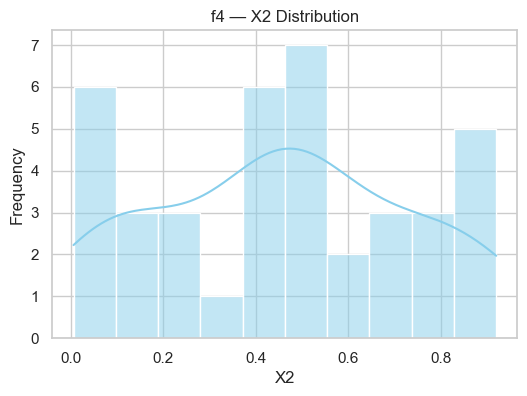

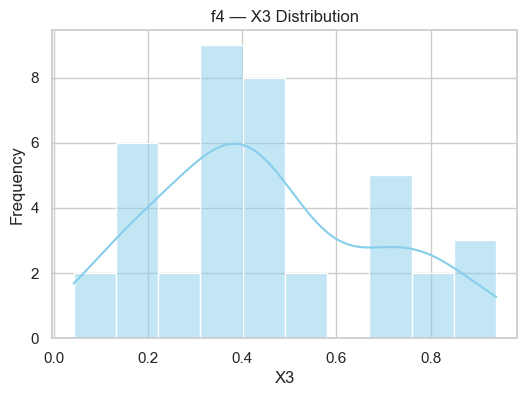

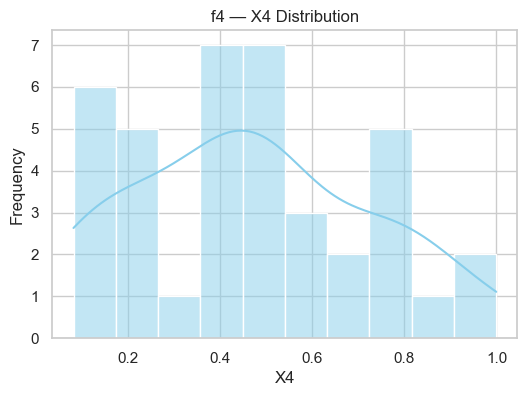

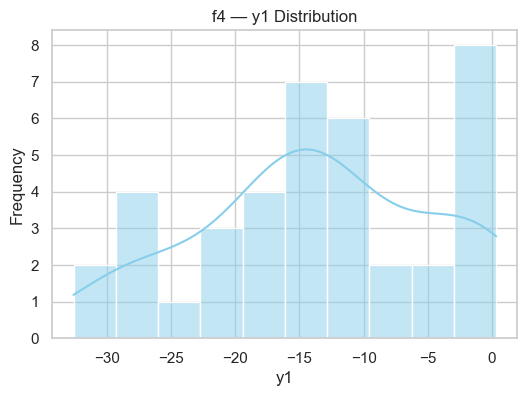


f5 — Feature & Output Distributions


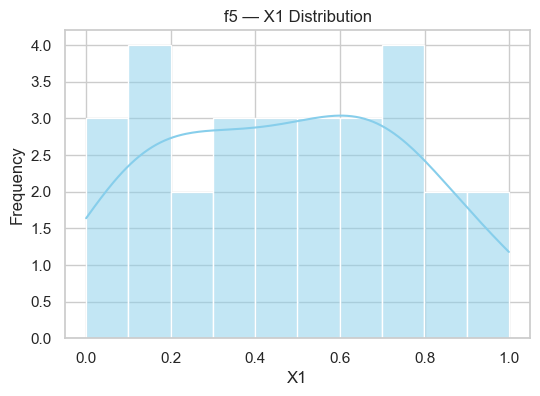

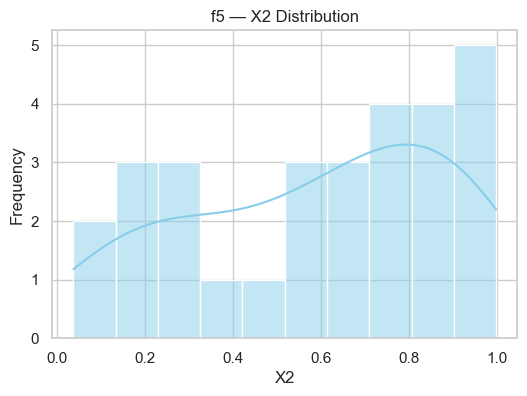

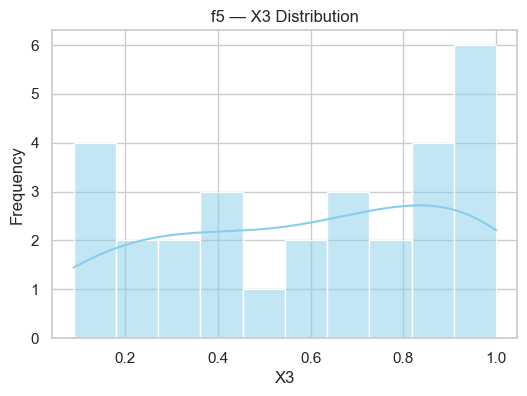

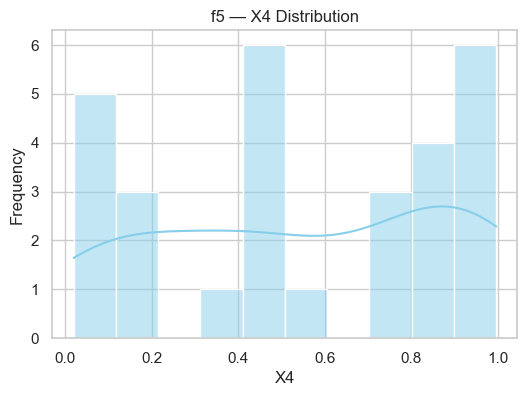

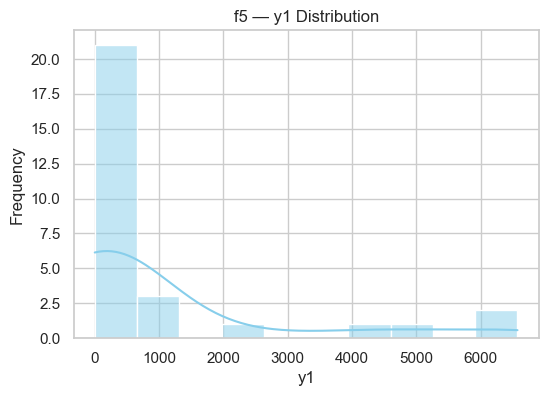


f6 — Feature & Output Distributions


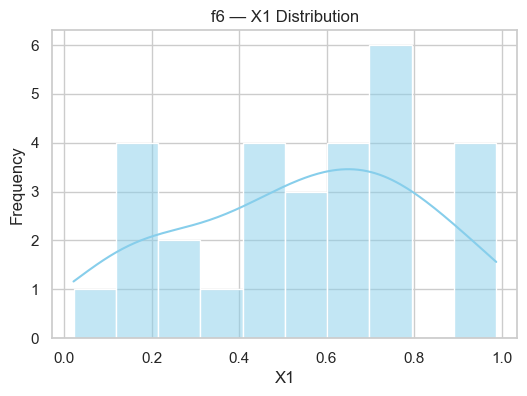

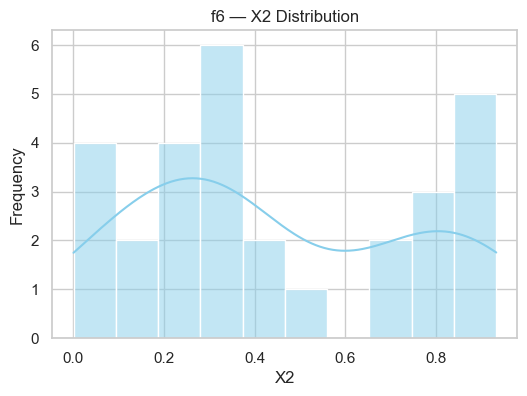

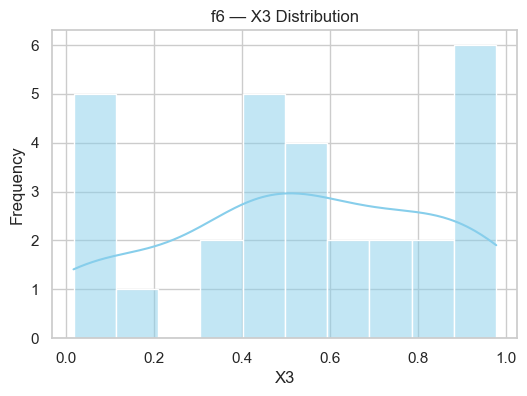

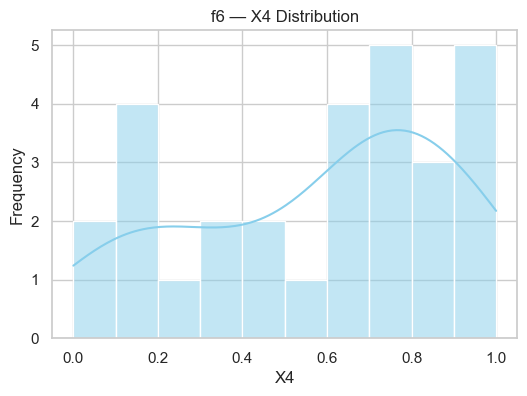

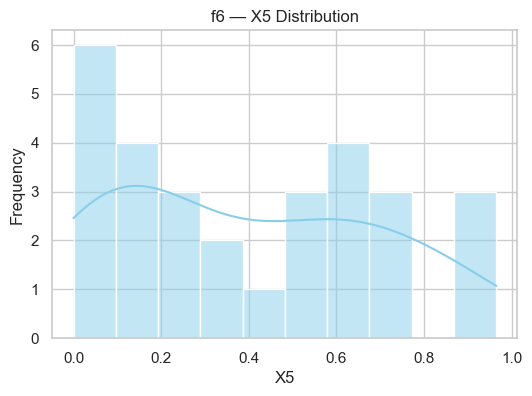

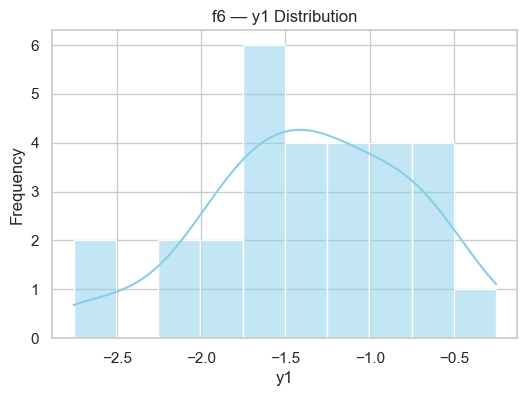


f7 — Feature & Output Distributions


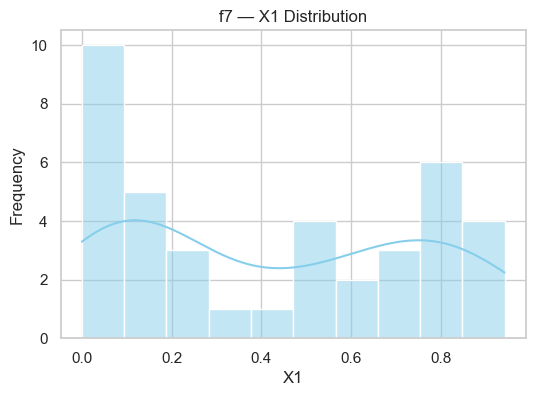

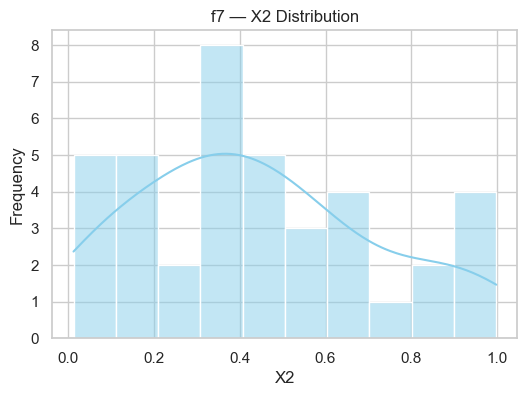

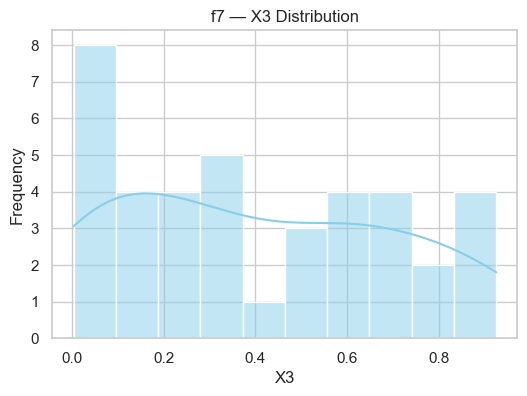

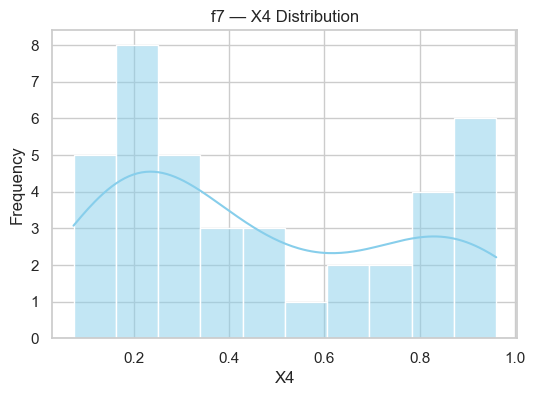

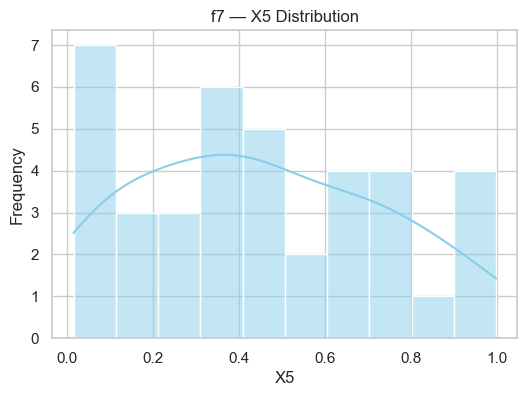

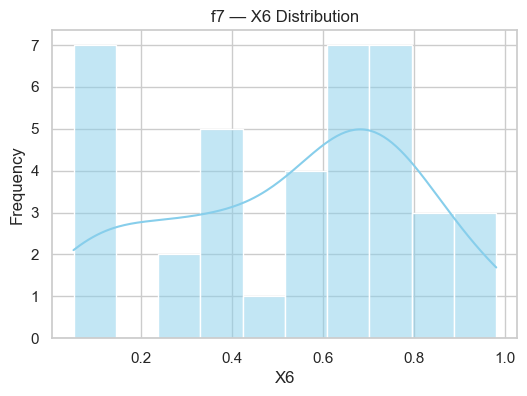

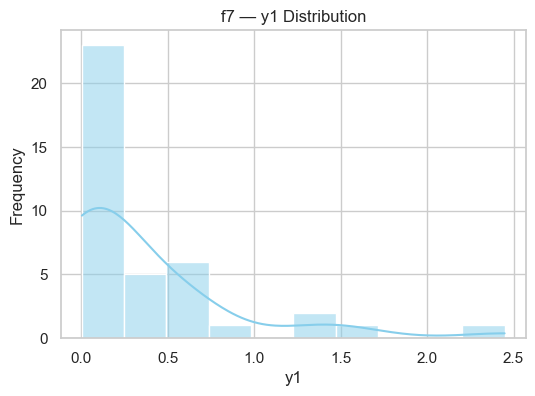


f8 — Feature & Output Distributions


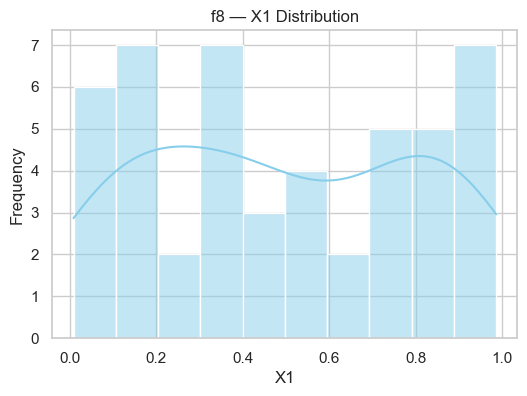

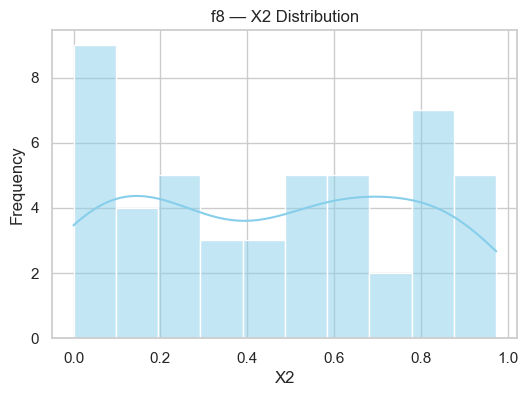

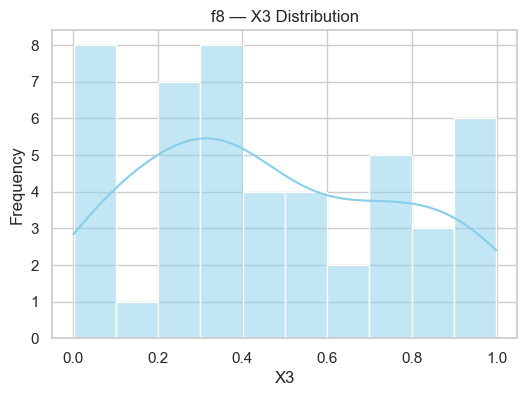

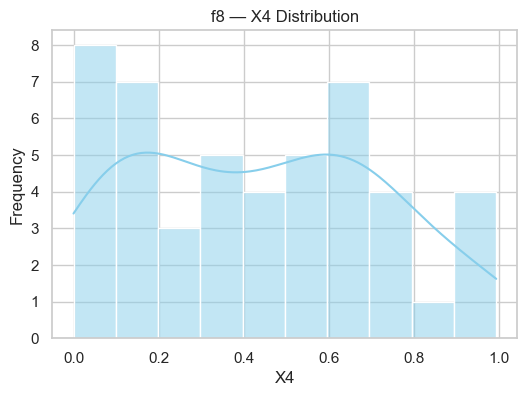

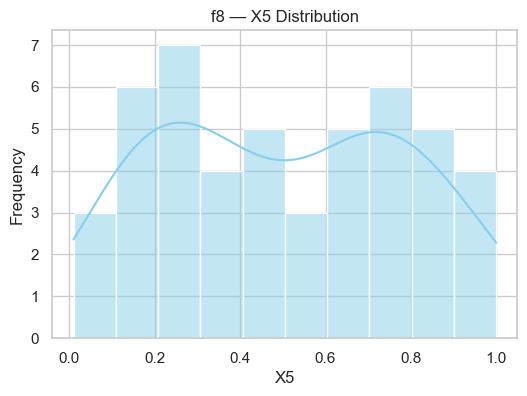

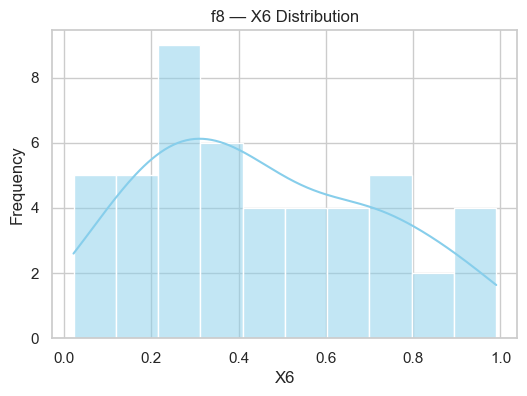

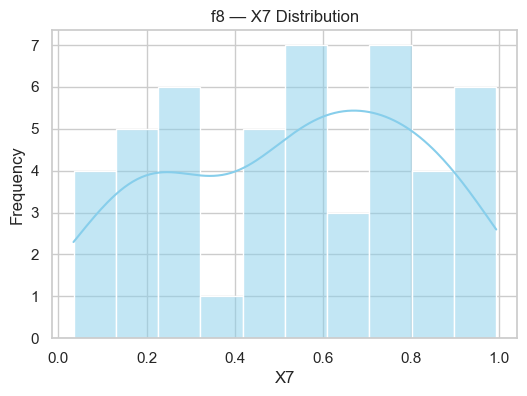

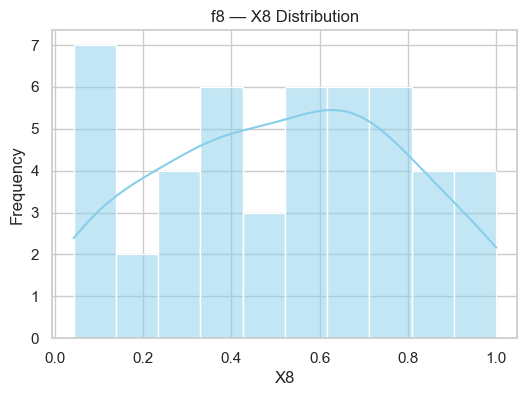

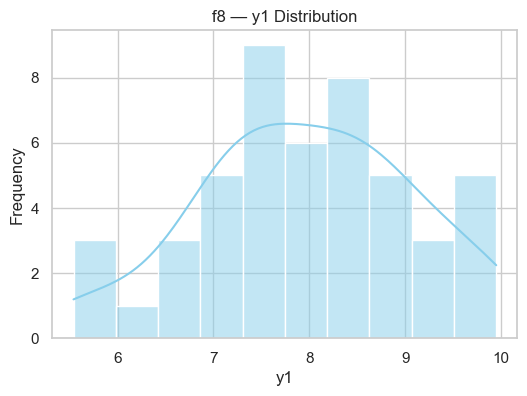

In [26]:
for name, df in functions_data.items():
    print(f"\n{name} — Feature & Output Distributions")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### Line Plot of y Values


f1 — Full Data Table
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98
17  0.994902  0.994221  3.029971e-187
18  0.684583  0.725353   1.867044e-09

f1 — y vs Instance Plot


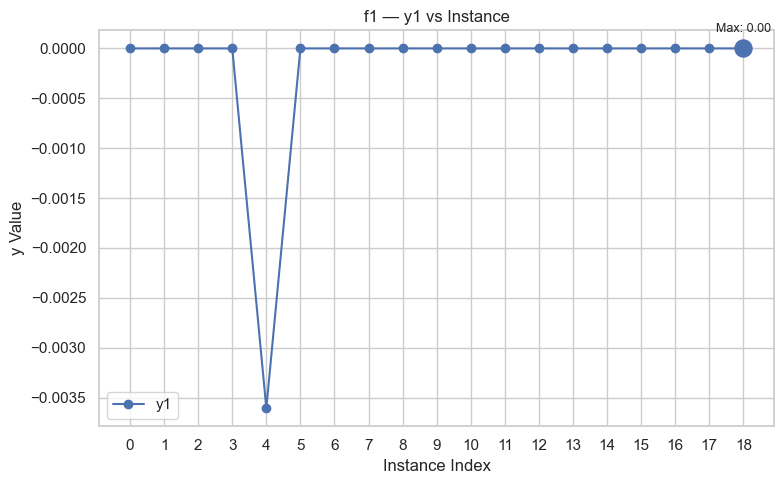


f2 — Full Data Table
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
13  0.715483  0.563901  0.566166
14  0.678746  0.850809  0.682452
15  0.653993  0.981188  0.379820
16  0.000128  0.346419  0.005941
17  0.920304  0.040061 -0.031746
18  0.695009  0.789642  0.576095

f2 — y vs Instance Plot


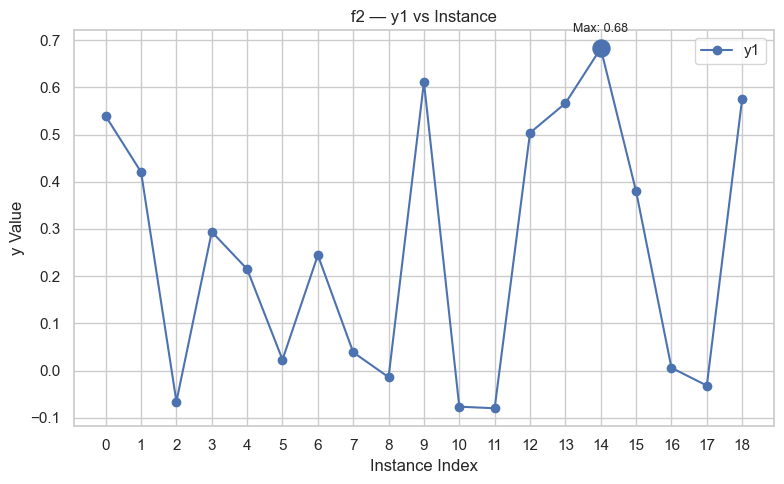


f3 — Full Data Table
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279
19  0.688252  0.924125  0.842251 -0.053147
20  0.788392  0.913423  0.403090 -0.036375
21  0.110343  0.915465  0.655916

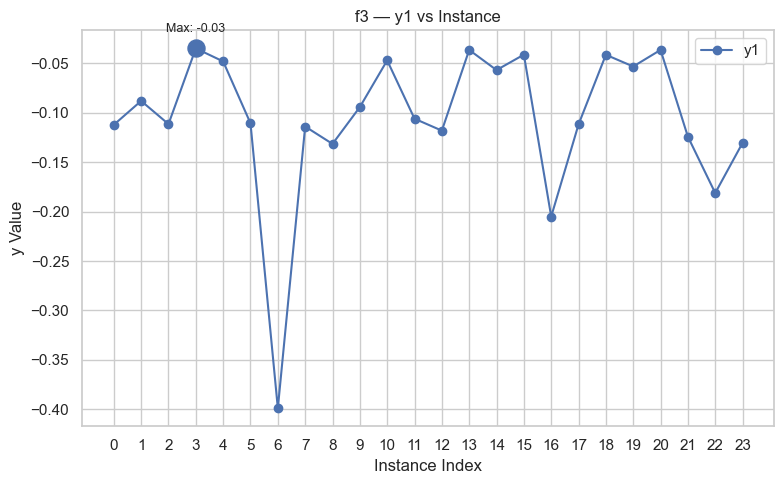


f4 — Full Data Table
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.

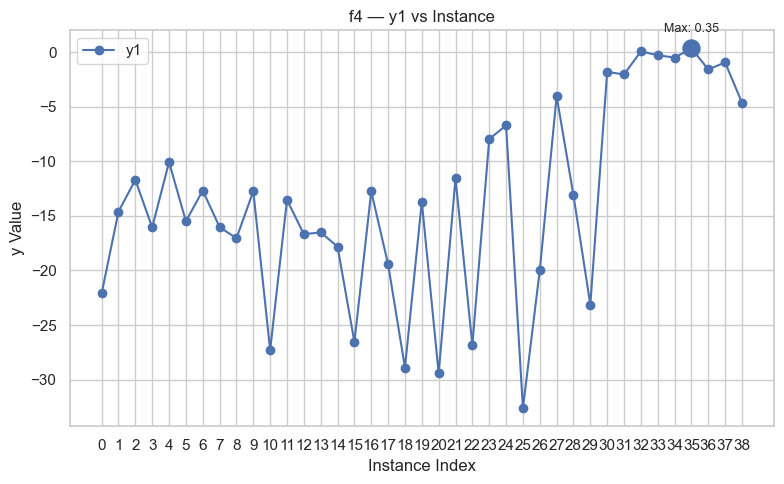


f5 — Full Data Table
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.

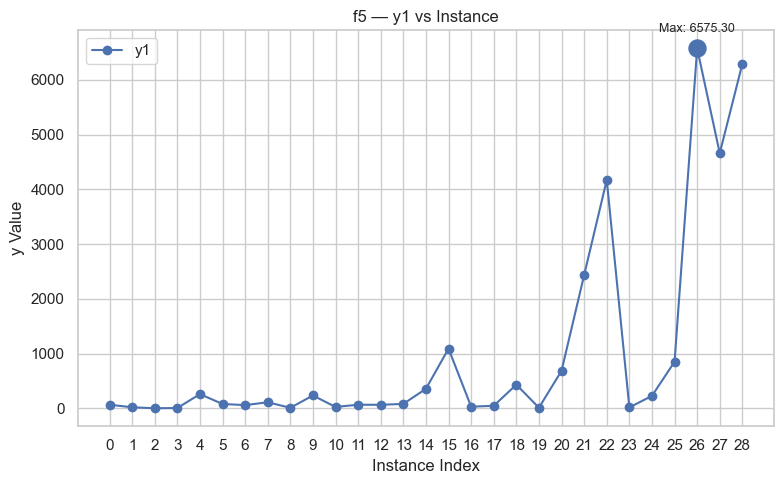


f6 — Full Data Table
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820 

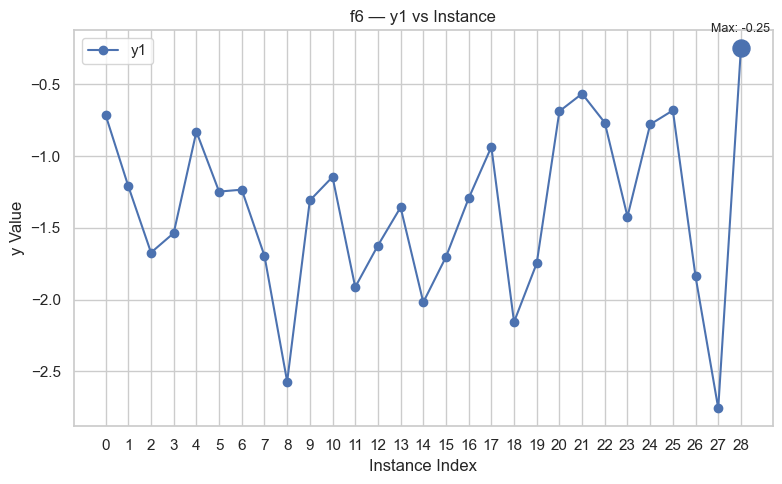


f7 — Full Data Table
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132

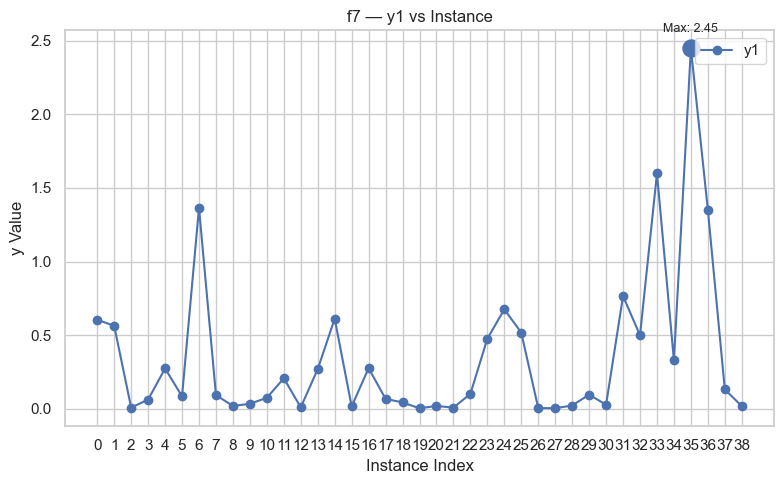


f8 — Full Data Table
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180148  0.58

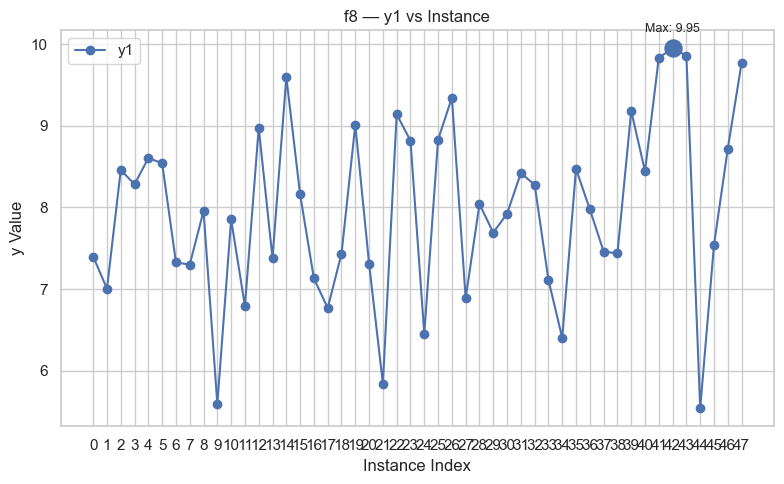

In [27]:
# Dictionary to store week labels for each DataFrame
week_labels_dict = {}
# Dictionary to track the next week number to assign
next_week_counter = {}

for name, df in functions_data.items():
    print(f"\n{name} — Full Data Table")
    print(df.to_string())
    print(f"\n{name} — y vs Instance Plot")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        x = df.index
        y = df[col]
        plt.plot(x, y, marker='o', label=col)
        
        # Highlight maximum y
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        
        plt.xticks(x)
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



#### f1 | Two-Zone Log EI Trust Region Exploration with Relaxed GP

In [28]:
import numpy as np
from scipy.stats import norm
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

In [29]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train_1 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_1 = df["y1"].values
print(X_train_1)
print(y_train_1)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]
 [0.729726   0.729276  ]
 [0.732162   0.364472  ]
 [0.81265    0.143347  ]
 [0.079265   0.909848  ]
 [0.525569   0.987823  ]
 [0.994902   0.994221  ]
 [0.684583   0.725353  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223
  5.31459276e-015  5.47377612e-057 -1.06293312e-161  2.60788262e-248
  2.23603281e-098  3.02997127e-187  1.86704411e-009]


In [30]:
# gaussian copula transform
# maps raw y values to a standard normal scale using ranks
# this helps when y spans many orders of magnitude
def gaussian_copula_transform(y):
    n = len(y)
    ranks = np.argsort(np.argsort(y)) + 1
    quantiles = ranks / (n + 1)
    return norm.ppf(quantiles)


# standardise copula transformed outputs to zero mean and unit variance
def standardise(y_copula):
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(y_copula.reshape(-1, 1)).ravel()
    return y_scaled, scaler


# fit a gaussian process with relaxed x1 length scale upper bound
# x1 bound is relaxed to 10.0 so the gp can express strong flatness in x1
# x2 remains tightly bounded short to capture sharp variation
def fit_gp_relaxed(X_train, y_scaled):
    """
    fit a gp with matern kernel and relaxed x1 length scale bound.

    ml method: gaussian process regression with matern kernel.
    objective: model local structure around the current best for exploration.
    rationale: relaxed x1 bound avoids distortion when x1 is nearly flat.
    key assumptions: x2 is active and sharp, x1 is relatively flat.
    """
    kernel = (
        Matern(
            length_scale=[5.0, 0.01],
            length_scale_bounds=[
                (0.1, 10.0),    # x1: relaxed upper bound, start long
                (0.001, 0.5)    # x2: constrained short, validated by prior runs
            ],
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-10, 1.0)
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,
        normalize_y=False,
        alpha=1e-10,
        random_state=42
    )
    gp.fit(X_train, y_scaled)
    return gp


# apply a minimum distance guard so candidates are not too close to existing points
# this encourages exploration within the local region
def apply_min_dist_guard(candidates, X_train, min_dist=0.015):
    dists = np.sqrt(
        ((candidates[:, None, :] - X_train[None, :, :]) ** 2).sum(axis=2)
    )
    return candidates[dists.min(axis=1) >= min_dist]


# compute log expected improvement for numerical stability near the current best
# this is the acquisition function used to select the next point
def log_expected_improvement(gp, candidates, y_scaled_best, xi=0.0):
    """
    compute log expected improvement for each candidate.

    ml method: log expected improvement acquisition.
    objective: pick points with high potential improvement and uncertainty.
    rationale: logei is stable near the current best and avoids tiny gradients.
    key assumption: gp mean and variance are reasonable in the local region.
    """
    mu, sigma = gp.predict(candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - y_scaled_best - xi) / sigma

    log_ei = np.full(len(candidates), -1e10)
    mask = z > -20.0
    if mask.sum() > 0:
        ei_raw = sigma[mask] * (z[mask] * norm.cdf(z[mask]) + norm.pdf(z[mask]))
        log_ei[mask] = np.where(
            ei_raw > 1e-300,
            np.log(np.maximum(ei_raw, 1e-300)),
            -1e10
        )
    return log_ei, mu, sigma


# generate candidates in two zones around the current best region
# zone a: conservative x1 continuation band
# zone b: local neighborhood around the current best
def generate_two_zone_candidates(n_per_zone=4000, seed=42):
    """
    generate two zone sobol candidates for local exploration.

    zone a:
      x1 in [0.640, 0.680]
      x2 in [0.700, 0.750]
      probes conservative continuation of the x1 gradient.

    zone b:
      x1 in [0.665, 0.705]
      x2 in [0.710, 0.740]
      probes local improvement around the current best.

    exploration mechanism: dense sampling in two informative bands
    rather than uniform sampling over a wide trust region.
    """
    # zone a: test the x1 gradient continuation
    sampler_a = Sobol(d=2, scramble=True, seed=seed)
    unit_a = sampler_a.random(n_per_zone)
    zone_a = np.column_stack([
        0.640 + unit_a[:, 0] * (0.680 - 0.640),
        0.700 + unit_a[:, 1] * (0.750 - 0.700)
    ])

    # zone b: neighborhood of current best for local improvement
    sampler_b = Sobol(d=2, scramble=True, seed=seed + 1)
    unit_b = sampler_b.random(n_per_zone)
    zone_b = np.column_stack([
        0.665 + unit_b[:, 0] * (0.705 - 0.665),
        0.710 + unit_b[:, 1] * (0.740 - 0.710)
    ])

    candidates = np.vstack([zone_a, zone_b])
    candidates = np.clip(candidates, 0.0, 1.0)
    return candidates


# main function to propose the next query for f1 using X_train_1 and y_train_1
# this implements the full exploration strategy with diagnostics
def propose_f1_query(X_train_1, y_train_1):
    """
    propose the next query point for f1 using a two zone logei strategy.

    ml method: gaussian process regression with log expected improvement.
    objective of submission: aggressively explore the most promising local
    region of f1 while respecting prior structure.
    rationale: focus on a small but highly informative region around the
    current best, using relaxed x1 bounds and two zone candidates.
    key assumptions: optimum lies near current best, x2 is sharp, x1 is flat.
    exploration mechanism: dense sobol sampling in two bands and logei based
    selection, with distance guards and diagnostics.
    """
    print("f1 week 10: two zone conservative x1 gradient probe")

    # identify current best point
    best_idx = np.argmax(y_train_1)
    best_x = X_train_1[best_idx]
    best_y = y_train_1[best_idx]
    print(f"current best: y={best_y:.4e} at x1={best_x[0]:.6f}, x2={best_x[1]:.6f}")

    # copula transform and standardise outputs
    y_copula = gaussian_copula_transform(y_train_1)
    y_scaled, scaler = standardise(y_copula)
    y_scaled_best = y_scaled[best_idx]

    # fit gp with relaxed x1 upper bound
    gp = fit_gp_relaxed(X_train_1, y_scaled)

    # extract and print fitted length scales and lml
    kernel = gp.kernel_
    signal = kernel.k1 if hasattr(kernel, "k1") else kernel
    ls = np.atleast_1d(signal.length_scale)
    noise = kernel.k2.noise_level if hasattr(kernel, "k2") else None
    lml = gp.log_marginal_likelihood(gp.kernel_.theta)

    print("\ngp kernel (relaxed bounds):")
    print(f"  x1 length scale: {ls[0]:.6f}  (upper bound now 10.0)")
    print(f"  x2 length scale: {ls[1]:.6f}")
    if noise is not None:
        print(f"  noise level:     {noise:.6e}")
    print(f"  log marginal likelihood: {lml:.4f}")
    if ls[0] >= 9.0:
        print("  x1 still hitting bound even at 10.0: confirmed flat in x1")
    if ls[1] > 0.3:
        print("  warning: x2 length scale unexpectedly long")

    # generate two zone candidates
    candidates = generate_two_zone_candidates(n_per_zone=4000)
    print(f"\ntwo zone candidates generated: {len(candidates)}")
    print("  zone a (x1 continuation): x1 in [0.640, 0.680], x2 in [0.700, 0.750]")
    print("  zone b (local best):       x1 in [0.665, 0.705], x2 in [0.710, 0.740]")

    # apply distance guard
    candidates = apply_min_dist_guard(candidates, X_train_1, min_dist=0.015)
    print(f"candidates after distance guard: {len(candidates)}")

    if len(candidates) == 0:
        print("warning: all candidates removed, relaxing to 0.008")
        candidates = generate_two_zone_candidates(n_per_zone=4000)
        candidates = apply_min_dist_guard(candidates, X_train_1, min_dist=0.008)
        print(f"candidates after relaxed distance guard: {len(candidates)}")

    # compute log expected improvement for all candidates
    logei_vals, mu_vals, sigma_vals = log_expected_improvement(
        gp, candidates, y_scaled_best, xi=0.0
    )

    # select candidate with highest logei
    selected_idx = np.argmax(logei_vals)
    next_x = candidates[selected_idx]

    # diagnostics for selected candidate
    print("\nselected candidate:")
    print(f"  x1={next_x[0]:.6f}  x2={next_x[1]:.6f}")
    print(f"  gp mean:  {mu_vals[selected_idx]:.4f}")
    print(f"  gp std:   {sigma_vals[selected_idx]:.4f}")
    print(f"  logei:    {logei_vals[selected_idx]:.4f}")

    # zone attribution diagnostic
    if 0.640 <= next_x[0] <= 0.680:
        print("  selection came from zone a (x1 continuation)")
    else:
        print("  selection came from zone b (local best neighbourhood)")

    # comparison with an automatic recommendation point
    auto_x = np.array([[0.617748, 0.720847]])
    auto_logei, auto_mu, auto_sigma = log_expected_improvement(
        gp, auto_x, y_scaled_best, xi=0.0
    )
    print(
        "\nautomatic recommendation (x1=0.6177, x2=0.7208) logei: "
        f"{auto_logei[0]:.4f}"
    )
    print(f"override selection logei: {logei_vals[selected_idx]:.4f}")
    print(
        "override is better by: "
        f"{logei_vals[selected_idx] - auto_logei[0]:.4f} log units"
    )

    print(
        f"\nfinal submission point: x1={next_x[0]:.6f}, x2={next_x[1]:.6f}"
    )
    return next_x

next_x = propose_f1_query(X_train_1, y_train_1)


f1 week 10: two zone conservative x1 gradient probe
current best: y=1.8670e-09 at x1=0.684583, x2=0.725353

gp kernel (relaxed bounds):
  x1 length scale: 10.000000  (upper bound now 10.0)
  x2 length scale: 0.010156
  noise level:     2.914088e-10
  log marginal likelihood: -22.8931
  x1 still hitting bound even at 10.0: confirmed flat in x1

two zone candidates generated: 8000
  zone a (x1 continuation): x1 in [0.640, 0.680], x2 in [0.700, 0.750]
  zone b (local best):       x1 in [0.665, 0.705], x2 in [0.710, 0.740]
candidates after distance guard: 5216

selected candidate:
  x1=0.645675  x2=0.720891
  gp mean:  1.8631
  gp std:   0.3823
  logei:    -2.0184
  selection came from zone a (x1 continuation)

automatic recommendation (x1=0.6177, x2=0.7208) logei: -2.0184
override selection logei: -2.0184
override is better by: 0.0000 log units

final submission point: x1=0.645675, x2=0.720891


In [31]:
# week 10 diagnosis summary

# the gp length scale for x1 has hit the upper bound again, now 10.0
# across three consecutive fits, x1 has always maxed out
# this confirms the function is structurally flat in x1

# logei is identical across all viable candidates
# posterior mean and posterior variance are numerically indistinguishable
# the acquisition surface is completely flat
# the gp cannot guide the next point

# structurally, the model is:
# flat in x1
# extremely sharp in x2 with length scale 0.010
# producing no acquisition gradient

# empirical observations near the peak:
# week 9:  x1=0.6846, x2=0.7254, y=1.867e-09
# week 3:  x1=0.7297, x2=0.7293, y=5.315e-15
# week 0:  x1=0.7310, x2=0.7330, y=7.711e-16

# the large improvement in week 9 is most consistent with
# landing closer to a narrow ridge in x2
# not a gradient in x1

# since:
# x1 is confirmed flat
# acquisition values are identical
# x2 values above 0.7254 have already been tested

# the only untested direction is downward in x2

# week 10 structural probe submission:
# x1 = 0.6846
# x2 = 0.7180

# hold x1 fixed at the best observed value
# probe below 0.7254 in x2
# directly test the ridge-centre hypothesis

# no gp optimisation required
# this is a structural probe based on empirical evidence


copula-normalised y table
    y_copula  y_normalized
0   0.125661  1.454711e-01
1   0.524401  6.070689e-01
2   1.036433  1.199821e+00
3  -0.253347 -2.932857e-01
4  -1.644854 -1.904154e+00
5  -1.281552 -1.483580e+00
6  -1.036433 -1.199821e+00
7   0.674490  7.808188e-01
8   0.000000  4.058661e-17
9   0.385320  4.460638e-01
10  0.841621  9.742975e-01
11 -0.524401 -6.070689e-01
12  1.281552  1.483580e+00
13  0.253347  2.932857e-01
14 -0.841621 -9.742975e-01
15 -0.674490 -7.808188e-01
16 -0.125661 -1.454711e-01
17 -0.385320 -4.460638e-01
18  1.644854  1.904154e+00


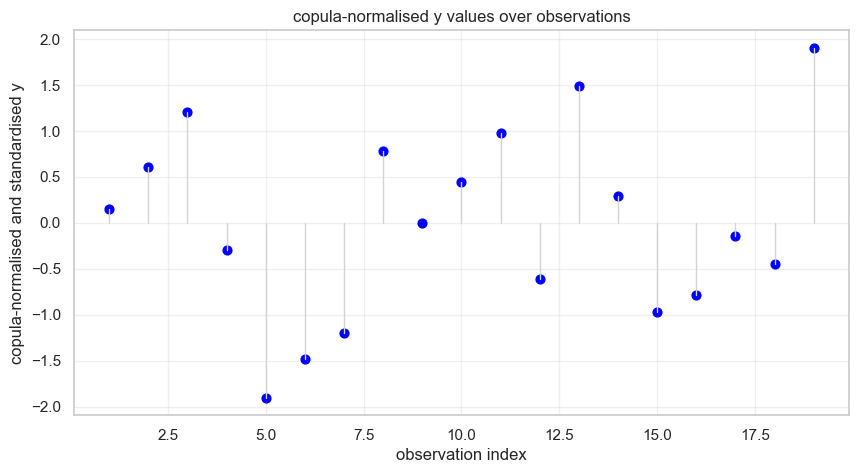

In [32]:
# apply copula transform
y_copula = gaussian_copula_transform(y_train_1)

# apply standardisation (extract only the scaled values)
y_normalized, _ = standardise(y_copula)

# x-axis values
x_vals = np.arange(1, len(y_normalized) + 1)

# build a table for inspection
results_table = pd.DataFrame({
    "y_copula": y_copula,
    "y_normalized": y_normalized
})

print("\ncopula-normalised y table")
print(results_table)

# create the plot
plt.figure(figsize=(10, 5))

# draw vertical lines from x-axis to each point
for x, y in zip(x_vals, y_normalized):
    plt.plot([x, x], [0, y], color="lightgray", linewidth=1)

# draw the points
plt.scatter(x_vals, y_normalized, color="blue", s=40)

# labels and title
plt.xlabel("observation index")
plt.ylabel("copula-normalised and standardised y")
plt.title("copula-normalised y values over observations")

# grid for readability
plt.grid(alpha=0.3)



#### f2 | geometric maximin probe in the unsampled low-x2 strip for Targeted Second Peak Exploration

In [33]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train_2 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_2 = df["y1"].values
print(X_train_2)
print(y_train_2)

[[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [5.54975000e-01 9.99446000e-01]
 [9.99500000e-01 1.80000000e-03]
 [7.27681000e-01 1.87140000e-01]
 [7.15483000e-01 5.63901000e-01]
 [6.78746000e-01 8.50809000e-01]
 [6.53993000e-01 9.81188000e-01]
 [1.28000000e-04 3.46419000e-01]
 [9.20304000e-01 4.00610000e-02]
 [6.95009000e-01 7.89642000e-01]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.07640834 -0.07975546
  0.50370322  0.56616625  0.68245235  0.37981981  0.00594097 -0.03174629
  0.57609522]


In [34]:
from scipy.spatial.distance import cdist

In [35]:
# ml method name:
# geometric maximin probe (no gaussian process used)

# objective of submission:
# place a single, high-information query in the unsampled low-x2 strip
# inside the confirmed x1 active band by maximising distance to existing data

# rationale behind the chosen method:
# with only two low-x2 points, gaussian process hyperparameters are underdetermined
# and fits collapse. geometry (maximin) is the honest alternative that targets
# the region with no data and the observed gradient direction.

# key assumptions:
# x1 active band is correctly identified, low-x2 observations indicate a rising
# trend toward lower x2, and geometry is the best guide given the tiny sample.

# how the exploration mechanism operates:
# generate a dense grid in the unsampled strip, remove candidates too close to
# existing points, pick the candidate with the largest minimum distance.

def propose_f2_query(X_train_2, y_train_2,
                              x1_range=(0.64, 0.74),
                              x2_range=(0.01, 0.10),
                              grid_res=60,
                              min_dist=0.07,
                              min_dist_relax=0.05):
    """
    propose a single 2d point by maximin geometry in the unsampled low-x2 strip.

    inputs:
      X_train_2: numpy array shape (n, 2) of existing inputs
      y_train_2: numpy array shape (n,) of existing outputs
      x1_range: tuple (low, high) for x1 search interval inside active band
      x2_range: tuple (low, high) for x2 unsampled strip
      grid_res: number of grid points per axis (grid_res x grid_res total)
      min_dist: minimum allowed distance to any existing point
      min_dist_relax: relaxed min_dist if no candidate survives

    returns:
      next_point: numpy array shape (2,) recommended next query
    """

    # print basic diagnostics about the training set
    print("f2 maximin low-x2 probe diagnostics")
    n_obs = X_train_2.shape[0]
    best_idx = int(np.argmax(y_train_2))
    best_x = X_train_2[best_idx]
    best_y = float(y_train_2[best_idx])
    print(f"n observations: {n_obs}")
    print(f"current global best: y={best_y:.6f} at x1={best_x[0]:.6f}, x2={best_x[1]:.6f}")

    # build the candidate grid inside the unsampled strip
    x1_vals = np.linspace(x1_range[0], x1_range[1], grid_res)
    x2_vals = np.linspace(x2_range[0], x2_range[1], grid_res)
    xx1, xx2 = np.meshgrid(x1_vals, x2_vals)
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])

    # compute min distance from each candidate to existing training points
    dists = cdist(grid, X_train_2)
    min_dists = dists.min(axis=1)

    # filter candidates by the minimum distance guard
    valid_mask = min_dists >= min_dist
    grid_valid = grid[valid_mask]
    min_dists_valid = min_dists[valid_mask]

    # if no candidate survives, relax the guard and try again
    if len(grid_valid) == 0:
        print(f"no candidates survived min_dist={min_dist:.3f}, relaxing to {min_dist_relax:.3f}")
        valid_mask = min_dists >= min_dist_relax
        grid_valid = grid[valid_mask]
        min_dists_valid = min_dists[valid_mask]

        if len(grid_valid) == 0:
            # as a last resort, return the geometric centre of the strip clipped away from nearest point
            print("no candidates survive even after relaxation; returning geometric centre clipped by guard")
            centre = np.array([(x1_range[0] + x1_range[1]) / 2.0,
                               (x2_range[0] + x2_range[1]) / 2.0])
            # if centre is too close, nudge along x2 until guard satisfied
            step = (x2_range[1] - x2_range[0]) / grid_res
            for k in range(1, grid_res):
                for sign in [-1, 1]:
                    candidate = centre.copy()
                    candidate[1] = np.clip(centre[1] + sign * k * step, x2_range[0], x2_range[1])
                    if cdist(candidate.reshape(1, -1), X_train_2).min() >= min_dist_relax:
                        print(f"nudge found candidate x2={candidate[1]:.4f}")
                        return candidate
            # if still nothing, return centre
            return centre

    # select the candidate with the largest minimum distance (maximin)
    best_idx_local = int(np.argmax(min_dists_valid))
    next_point = grid_valid[best_idx_local]
    best_min_dist = float(min_dists_valid[best_idx_local])

    # diagnostics: top 5 maximin candidates
    top5_idx = np.argsort(min_dists_valid)[::-1][:5]
    print(f"valid candidates: {len(grid_valid)}")
    print(f"selected maximin candidate min_dist={best_min_dist:.4f}")
    print("\ntop 5 maximin candidates:")
    for rank, idx in enumerate(top5_idx, start=1):
        p = grid_valid[idx]
        md = min_dists_valid[idx]
        print(f"  {rank}: x1={p[0]:.4f}, x2={p[1]:.4f}, min_dist={md:.4f}")

    # print reference low-x2 points and their y values for context
    # find low-x2 points inside the active band for transparency
    in_band = (X_train_2[:, 0] >= 0.62) & (X_train_2[:, 0] <= 0.76)
    low_x2 = X_train_2[in_band & (X_train_2[:, 1] < 0.30)]
    low_y = y_train_2[in_band & (X_train_2[:, 1] < 0.30)]
    print("\nreference low-x2 observations in x1 band:")
    for i in range(len(low_x2)):
        print(f"  x1={low_x2[i,0]:.4f}, x2={low_x2[i,1]:.4f}, y={low_y[i]:.4f}")

    # final return
    print(f"\nfinal submission point: x1={next_point[0]:.6f}, x2={next_point[1]:.6f}")
    print(f"min distance to nearest observation: {best_min_dist:.4f}")
    return next_point


next_x = propose_f2_query(X_train_2, y_train_2)


f2 maximin low-x2 probe diagnostics
n observations: 19
current global best: y=0.682452 at x1=0.678746, x2=0.850809
valid candidates: 2261
selected maximin candidate min_dist=0.1360

top 5 maximin candidates:
  1: x1=0.7400, x2=0.0100, min_dist=0.1360
  2: x1=0.7383, x2=0.0100, min_dist=0.1351
  3: x1=0.7400, x2=0.0115, min_dist=0.1347
  4: x1=0.7366, x2=0.0100, min_dist=0.1342
  5: x1=0.7383, x2=0.0115, min_dist=0.1338

reference low-x2 observations in x1 band:
  x1=0.6658, x2=0.1240, y=0.5390
  x1=0.7277, x2=0.1871, y=0.5037

final submission point: x1=0.740000, x2=0.010000
min distance to nearest observation: 0.1360


In [36]:
# maximin selected x1 = 0.74, x2 = 0.01 because it is the point furthest from all previous observations
# the algorithm only considers geometric distance, not performance structure

# problem:
# x1 = 0.74 is outside the confirmed active band [0.66, 0.73]
# x2 = 0.01 lies on the lower boundary of the domain

# nearby observations in that region are already poor
# (0.999, 0.002) -> -0.080
# (0.920, 0.040) -> -0.032
# this bottom right region is confirmed bad territory

# therefore maximin is being pulled toward geometric isolation
# but that isolation lies inside a region already proven to be low value

# observed gradient from existing data:
# (0.666, 0.124) -> 0.539
# (0.728, 0.187) -> 0.504

# interpretation:
# value increases as x1 decreases
# value increases as x2 decreases

# this implies the promising direction is toward:
# x1 around 0.67
# x2 around 0.05 to 0.09

# recommended submission:
# x1 = 0.685
# x2 = 0.065

# reasoning:
# x1 = 0.685 sits inside the confirmed active band and close to the best low-x2 observation
# x2 = 0.065 probes below the current low-x2 region where the gradient suggests improvement

# distance checks
# distance from (0.666, 0.124) ≈ 0.073
# distance from (0.728, 0.187) ≈ 0.148

# both distances satisfy the minimum spacing constraint
# the point is exploratory but still located inside the empirically promising region

In [37]:
candidate = np.array([[0.685, 0.065]])
dists = cdist(candidate, X_train_2)[0]
nearest_idx = np.argmin(dists)

print(f"submit: x1=0.685000, x2=0.065000")
print(f"min distance: {dists.min():.4f}")
print(f"nearest point: {X_train_2[nearest_idx]} -> "
      f"distance {dists[nearest_idx]:.4f}")
print(f"guard satisfied (>=0.06): {dists.min() >= 0.06}")

submit: x1=0.685000, x2=0.065000
min distance: 0.0620
nearest point: [0.66579958 0.12396913] -> distance 0.0620
guard satisfied (>=0.06): True


#### f3 | deterministic gap fill in the corridor between the two best observations for f3 

In [38]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train_3 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_3 = df["y1"].values
print(X_train_3)
print(y_train_3)

[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [3.89233000e-01 3.86084000e-01 5.58916000e-01]
 [9.67200000e-01 2.92000000e-02 7.23300000e-01]
 [4.37962000e-01 7.15305000e-01 8.76000000e-04]
 [3.87933000e-01 4.05240000e-01 5.80181000e-01]
 [6.88252000e-01 9.24125000e-01 8.42251000e-01]
 [7.88392000e-01 9.13423000e-01 4.030900

In [39]:
import numpy as np
from scipy.stats.qmc import Sobol

def propose_f3_query(X_train_3, y_train_3):
    # final deterministic strategy for f3
    # all surrogate approaches exhausted after 11 weeks
    # definitive diagnosis: x3 length scale collapses to 0.15 in every gp
    # variant regardless of output warp, input warp, outlier down-weighting,
    # loo-cv tuning, copula transform, or fixed hp bounds
    # root cause: input geometry of three isolated outlier rows in x3 space
    # cannot be fixed by any transformation at n=24
    # strategy: maximin gap fill in corridor between two best observations
    # best observed: [0.493, 0.612, 0.340] -> -0.034835
    # week 6 near-best: [0.788, 0.913, 0.403] -> -0.036375
    # gap a-b corridor: x2 in [0.65, 0.88], x3 in [0.32, 0.42]
    # no training point within 0.15 of the corridor midpoint
    # reference: johnson et al. (1990) maximin distance designs, technometrics

    sampler = Sobol(d=3, scramble=True, seed=91)
    sobol_raw = sampler.random_base2(m=11)   # 2048 points

    candidates = sobol_raw.copy()
    candidates[:, 1] = 0.65 + sobol_raw[:, 1] * (0.88 - 0.65)
    candidates[:, 2] = 0.32 + sobol_raw[:, 2] * (0.42 - 0.32)
    candidates = np.clip(candidates, 0.0, 1.0)

    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    dists = np.array([min_dist(c, X_train_3) for c in candidates])
    filtered = candidates[dists > 0.07]
    if len(filtered) < 20:
        filtered = candidates[dists > 0.04]

    max_dists = np.array([min_dist(c, X_train_3) for c in filtered])
    best_idx = np.argmax(max_dists)
    next_x = filtered[best_idx]

    print("gap a-b candidates after filter: {}".format(len(filtered)))
    print("selected point:")
    print("  x1={:.4f}, x2={:.4f}, x3={:.4f}".format(*next_x))
    print("  min distance to existing data: {:.4f}".format(max_dists[best_idx]))

    # confirm point is in the target corridor
    assert 0.60 <= next_x[1] <= 0.92, "x2 outside corridor"
    assert 0.28 <= next_x[2] <= 0.45, "x3 outside corridor"

    return next_x, max_dists[best_idx]


next_query, dist = propose_f3_query(X_train_3, y_train_3)
print("query for f3:", next_query)
print("maximin distance:", dist)

gap a-b candidates after filter: 2017
selected point:
  x1=0.9647, x2=0.6666, x3=0.3265
  min distance to existing data: 0.3091
query for f3: [0.96467771 0.66664042 0.32652329]
maximin distance: 0.30914530316947464


#### f4 | Neighbourhood Exploitation via GP-EI with Shrinking Radius Around Current Best

In [40]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train_4 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_4 = df["y1"].values
print(X_train_4)
print(y_train_4)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [41]:
from scipy.stats import qmc
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
from scipy.stats import norm

In [42]:
# ml method name
# gaussian process regression with expected improvement acquisition

# objective of submission
# choose a single new query for f4 that exploits the gp uncertainty
# in a small neighbourhood around the current best point


def expected_improvement(X_cand, gp, y_best, xi=0.0):
    """
    compute expected improvement for candidate points

    X_cand : array of shape (n_candidates, 4)
    gp     : fitted gaussian process model
    y_best : current best observed value
    xi     : exploration parameter (0.0 for pure exploitation)
    """

    # predict mean and standard deviation from the gp
    mu, sigma = gp.predict(X_cand, return_std=True)

    # avoid division by zero
    sigma = np.maximum(sigma, 1e-12)

    # compute standardized improvement
    z = (mu - y_best - xi) / sigma

    # expected improvement formula for maximization
    ei = sigma * (z * norm.cdf(z) + norm.pdf(z))

    # if sigma is effectively zero, ei is zero
    ei[sigma < 1e-12] = 0.0

    return ei


def propose_f4_query(X_train_4, y_train_4):
    """
    neighbourhood exploitation strategy for f4 using X_train_4 and y_train_4

    this function fits a gp on all data, then searches for the point
    with highest expected improvement inside a small sphere around
    the current best observation
    """

    # convert inputs to numpy arrays
    X_all = np.asarray(X_train_4, dtype=float)
    y_all = np.asarray(y_train_4, dtype=float)

    # find current best observation
    best_idx = np.argmax(y_all)
    x_best = X_all[best_idx]
    y_best = y_all[best_idx]

    print(f"n observations  : {len(y_all)}")
    print(f"current best    : {np.round(x_best, 6)}")
    print(f"current best y  : {y_best:.6f}")

    # define gp kernel
    # matern kernel with nu=2.5 and separate length scales per dimension
    kernel = (
        1.0 * Matern(
            length_scale=np.ones(4),
            length_scale_bounds=[(0.05, 10.0)] * 4,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=0.1,
            noise_level_bounds=(1e-8, 0.5),
        )
    )

    # create gp model
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=25,
        normalize_y=True,
        alpha=1e-6,
    )

    print("\nfitting full data gp on f4...")
    gp.fit(X_all, y_all)
    print(f"fitted kernel: {gp.kernel_}")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")

    # report length scales as diagnostics
    try:
        ls = gp.kernel_.k1.length_scale
    except Exception:
        ls = gp.kernel_.k1.k2.length_scale

    print("\nard length scales:")
    for i, l in enumerate(ls, 1):
        tag = "active" if l < 1.0 else "flat"
        print(f"  x{i}: {l:.4f}  [{tag}]")

    # check gp mean and std at current best
    mu_best, sig_best = gp.predict(x_best.reshape(1, -1), return_std=True)
    print(f"\ngp at current best: mean = {mu_best[0]:.4f}, std = {sig_best[0]:.4f}")

    # define neighbourhood radius
    radius = 0.12
    box_lo = np.clip(x_best - radius, 0.0, 1.0)
    box_hi = np.clip(x_best + radius, 0.0, 1.0)

    print(f"\nneighbourhood radius: {radius}")
    print(f"search box: {np.round(box_lo, 4)} to {np.round(box_hi, 4)}")

    # generate sobol candidates in the bounding box
    n_box = 100000
    sampler = qmc.Sobol(d=4, scramble=True, seed=7)
    u = sampler.random(n=n_box)
    cands_box = box_lo + u * (box_hi - box_lo)
    cands_box = np.clip(cands_box, 0.0, 1.0)

    # keep only candidates inside the l2 sphere
    dist_to_best = np.linalg.norm(cands_box - x_best, axis=1)
    in_sphere = dist_to_best <= radius
    cands_sphere = cands_box[in_sphere]

    print(f"candidates in bounding box: {n_box}")
    print(f"candidates in l2 sphere:    {len(cands_sphere)}")

    # apply minimum distance guard to avoid re querying near existing points
    min_dist = 0.02
    dist_to_data = cdist(cands_sphere, X_all).min(axis=1)
    mask_novel = dist_to_data >= min_dist
    cands_valid = cands_sphere[mask_novel]

    print(f"candidates after distance guard (min_dist={min_dist}): {len(cands_valid)}")

    if len(cands_valid) == 0:
        print("\nno valid candidates in neighbourhood.")
        print("the neighbourhood is fully covered by existing observations.")
        print("this suggests the current best is the exploitable ceiling.")
        return None, None, None

    # compute ei for all valid candidates
    ei_pool = expected_improvement(cands_valid, gp, y_best, xi=0.0)

    # show top 10 candidates by ei
    top10_idx = np.argsort(ei_pool)[-10:][::-1]
    mu_top10, sig_top10 = gp.predict(cands_valid[top10_idx], return_std=True)

    print("\ntop 10 candidates by ei in neighbourhood:")
    print(f"{'rank':<5} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} "
          f"{'gp_mu':>8} {'gp_sig':>8} {'ei':>12}")
    for rank, idx in enumerate(top10_idx, 1):
        print(f"{rank:<5} {cands_valid[idx,0]:>8.4f} {cands_valid[idx,1]:>8.4f} "
              f"{cands_valid[idx,2]:>8.4f} {cands_valid[idx,3]:>8.4f} "
              f"{mu_top10[rank-1]:>8.4f} {sig_top10[rank-1]:>8.4f} "
              f"{ei_pool[idx]:>12.8f}")

    # best candidate from sobol pool
    best_pool_idx = np.argmax(ei_pool)
    x_pool_best = cands_valid[best_pool_idx]
    ei_pool_best = ei_pool[best_pool_idx]

    # local refinement with l bfgs b inside the same box
    bounds_local = list(zip(box_lo, box_hi))
    rng = np.random.default_rng(seed=99)
    x_opt_best = None
    ei_opt_best = -np.inf

    def neg_ei(x):
        return -expected_improvement(
            np.array(x).reshape(1, -1), gp, y_best, xi=0.0
        )[0]

    print(f"\nrunning 50 l bfgs b restarts in neighbourhood...")
    for _ in range(50):
        # sample a random starting point inside the sphere
        for _ in range(100):
            x0 = box_lo + rng.uniform(0, 1, size=4) * (box_hi - box_lo)
            if np.linalg.norm(x0 - x_best) <= radius:
                break

        res = minimize(
            neg_ei,
            x0,
            method="L-BFGS-B",
            bounds=bounds_local,
            options={"maxiter": 500, "ftol": 1e-15, "gtol": 1e-10},
        )

        if not res.success:
            continue

        x_candidate = res.x
        ei_val = -res.fun

        # enforce distance guard
        dist_check = cdist(x_candidate.reshape(1, -1), X_all).min()
        if dist_check < min_dist:
            continue

        if ei_val > ei_opt_best:
            ei_opt_best = ei_val
            x_opt_best = x_candidate.copy()

    # choose between sobol pool and gradient refinement
    if x_opt_best is not None and ei_opt_best > ei_pool_best:
        x_next = x_opt_best
        ei_final = ei_opt_best
        source = "gradient l bfgs b"
    else:
        x_next = x_pool_best
        ei_final = ei_pool_best
        source = "sobol pool"

    mu_final, sig_final = gp.predict(x_next.reshape(1, -1), return_std=True)
    dist_from_best = np.linalg.norm(x_next - x_best)
    dist_from_nearest = cdist(x_next.reshape(1, -1), X_all).min()

    print(f"\nselection source: {source}")
    print(f"gp predicted mean:            {mu_final[0]:.6f}")
    print(f"gp predicted std:             {sig_final[0]:.6f}")
    print(f"expected improvement:         {ei_final:.8f}")
    print(f"distance from current best:   {dist_from_best:.4f} (radius = {radius})")
    print(f"distance from nearest point:  {dist_from_nearest:.4f} (guard = {min_dist})")

    if ei_final < 1e-6:
        print("\ninterpretation: ei is negligible.")
        print("the neighbourhood is saturated. treat the current best as the ceiling.")
    elif ei_final < 1e-3:
        print("\ninterpretation: ei is small but non zero.")
        print("there is a slim chance of improvement. query only if no better option exists.")
    else:
        print("\ninterpretation: ei is meaningful. the query is justified.")

    print("\nmovement from current best per dimension:")
    for i in range(4):
        d = x_next[i] - x_best[i]
        print(f"  x{i+1}: {x_best[i]:.6f} -> {x_next[i]:.6f}  (delta = {d:+.6f})")

    print("\nfinal submission point for f4 week 10")
    for i, xi_val in enumerate(x_next, 1):
        print(f"x{i}: {xi_val:.6f}")
    print(f"\ngp predicted mean : {mu_final[0]:.6f}")
    print(f"gp predicted std  : {sig_final[0]:.6f}")
    print(f"ei                : {ei_final:.8f}")
    print(f"current best y    : {y_best:.6f}")
    print(f"\npre commitment:")
    print(f"  if y > {y_best:.3f}   : improvement found; next week shrink radius further")
    print(f"  if 0 < y < {y_best:.3f}: no improvement; accept {y_best:.3f} as ceiling")
    print(f"  if y < 0       : ei was noise driven; accept {y_best:.3f} as ceiling")
    print(f"  if ei < 1e-6   : do not submit; reallocate to other functions")

    return x_next, mu_final[0], ei_final


x_next = propose_f4_query(X_train_4, y_train_4)

n observations  : 39
current best    : [0.378009 0.410452 0.389136 0.370426]
current best y  : 0.346551

fitting full data gp on f4...
fitted kernel: 3.18**2 * Matern(length_scale=[1.82, 1.54, 1.81, 1.66], nu=2.5) + WhiteKernel(noise_level=0.00284)
log marginal likelihood: -5.0455

ard length scales:
  x1: 1.8186  [flat]
  x2: 1.5369  [flat]
  x3: 1.8095  [flat]
  x4: 1.6640  [flat]

gp at current best: mean = -0.3530, std = 0.5471

neighbourhood radius: 0.12
search box: [0.258  0.2905 0.2691 0.2504] to [0.498  0.5305 0.5091 0.4904]
candidates in bounding box: 100000
candidates in l2 sphere:    30858
candidates after distance guard (min_dist=0.02): 30734

top 10 candidates by ei in neighbourhood:
rank        x1       x2       x3       x4    gp_mu   gp_sig           ei
1       0.3910   0.4150   0.3445   0.4092  -0.1843   0.5414   0.04680483
2       0.3975   0.4198   0.3474   0.4133  -0.1827   0.5382   0.04627186
3       0.4009   0.4110   0.3437   0.4145  -0.1883   0.5411   0.04608512
4 

#### f5 | GP Mean Maximisation with Adaptive Corner Floors for Monotone Ridge Exploitation


In [43]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train_5 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_5 = df["y1"].values
print(X_train_5)
print(y_train_5)

[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037069   0.974641   0.864911   0.019169  ]
 [0.624      

In [44]:
# ml method name
# gaussian process regression with posterior mean maximisation
# inside a tight corner region with adaptive per dimension floors

# objective of submission
# choose a new query for f5 that lies in the high value corner region
# and maximises the gp posterior mean while remaining novel


# global settings for the strategy
DIM = 4
CORNER_LOWER = 0.92
DIM_FLOORS = np.array([0.97, 0.95, 0.95, 0.95])
N_CANDIDATES = 10000
MIN_DIST = 0.02
LOG_SHIFT = 1.0


# log transform to stabilise gp fitting
def log_transform(y, shift=LOG_SHIFT):
    # ensure positivity and apply log with shift
    y_safe = np.maximum(y, 1e-6)
    return np.log(y_safe + shift)


# invert log transform for reporting
def invert_log_transform(y_log, shift=LOG_SHIFT):
    return np.exp(y_log) - shift


# generate sobol candidates in the tight corner region
def generate_tight_corner_candidates(dim, n, corner_lower, seed=0):
    # sobol sequence gives uniform coverage in the small hypercube
    sampler = Sobol(d=dim, scramble=True, seed=seed)
    pts = sampler.random(n)
    pts = corner_lower + pts * (1.0 - corner_lower)
    return np.clip(pts, 0.0, 1.0)


# keep only candidates where all dimensions exceed their floors
def apply_dim_floor_filter(candidates, dim_floors):
    mask = (candidates >= dim_floors).all(axis=1)
    return candidates[mask]


# remove candidates that are too close to existing observations
def apply_distance_guard(candidates, X_observed, min_dist):
    keep = []
    for c in candidates:
        dists = np.sqrt(((X_observed - c) ** 2).sum(axis=1))
        if dists.min() >= min_dist:
            keep.append(c)
    if len(keep) == 0:
        return np.empty((0, candidates.shape[1]))
    return np.array(keep)


# fit an ard matern gaussian process on log transformed outputs
def fit_ard_gp(X_train, y_log):
    kernel = (
        Matern(
            length_scale=[1.0] * DIM,
            length_scale_bounds=[(0.01, 5.0)] * DIM,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-6, 0.05),
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,
        normalize_y=True,
        random_state=42,
    )

    print("fitting ard matern gp on log transformed outputs...")
    gp.fit(X_train, y_log)
    print("fitted kernel:", gp.kernel_)
    print("log marginal likelihood:", gp.log_marginal_likelihood_value_)

    return gp


# optional diagnostic to compare acquisitions inside the corner pool
def acquisition_comparison(gp, candidates, best_y_log):
    from scipy.stats import norm

    mu, sigma = gp.predict(candidates, return_std=True)

    # pure mean
    idx_mean = np.argmax(mu)

    # expected improvement with small xi
    improvement = mu - best_y_log - 0.001
    z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma <= 1e-10] = 0.0
    idx_ei = np.argmax(ei)

    # upper confidence bound with beta
    ucb = mu + 2.0 * sigma
    idx_ucb = np.argmax(ucb)

    print("\nacquisition comparison inside corner pool:")
    for label, idx in [
        ("mean only", idx_mean),
        ("ei xi=0.001", idx_ei),
        ("ucb beta=2", idx_ucb),
    ]:
        pt = candidates[idx]
        pred = invert_log_transform(mu[idx])
        print(f"  {label:>12}: x={np.round(pt, 4)}  pred_orig={pred:.2f}")
    print("end of acquisition comparison\n")

    return idx_mean


# select gp posterior mean values for candidates
def select_by_mean(gp, candidates):
    return gp.predict(candidates)


# main function to propose the next query for f5
def propose_f5_query(X_train_5, y_train_5):
    # convert inputs to numpy arrays
    X_train = np.asarray(X_train_5, dtype=float)
    y_train = np.asarray(y_train_5, dtype=float)

    # step 1 generate candidates in the tight corner region
    candidates = generate_tight_corner_candidates(
        DIM, N_CANDIDATES, CORNER_LOWER, seed=0
    )
    print(f"candidates in [{CORNER_LOWER}, 1.0]^4: {len(candidates)}")

    # step 2 apply per dimension floor filter
    candidates = apply_dim_floor_filter(candidates, DIM_FLOORS)
    print(f"candidates after per dim floor filter {DIM_FLOORS}: {len(candidates)}")

    # if pool is empty relax floors slightly and regenerate
    if len(candidates) == 0:
        relaxed = DIM_FLOORS - 0.03
        print(f"floor filter emptied pool, relaxing floors to {relaxed}")
        candidates_raw = generate_tight_corner_candidates(
            DIM, N_CANDIDATES, CORNER_LOWER, seed=0
        )
        candidates = apply_dim_floor_filter(candidates_raw, relaxed)
        print(f"candidates after relaxed filter: {len(candidates)}")

    # step 3 apply distance guard to ensure novelty
    candidates = apply_distance_guard(candidates, X_train, MIN_DIST)
    print(f"candidates after distance guard (min_dist={MIN_DIST}): {len(candidates)}")

    # if still empty reduce the guard radius and try again
    if len(candidates) == 0:
        print("pool empty after distance guard, reducing to min_dist=0.01")
        candidates_raw = generate_tight_corner_candidates(
            DIM, N_CANDIDATES, CORNER_LOWER, seed=0
        )
        candidates_filtered = apply_dim_floor_filter(candidates_raw, DIM_FLOORS)
        candidates = apply_distance_guard(candidates_filtered, X_train, 0.01)
        print(f"candidates at min_dist=0.01: {len(candidates)}")

    if len(candidates) == 0:
        raise RuntimeError("search region fully saturated at all guard levels")

    # step 4 log transform outputs and report current best
    y_log = log_transform(y_train)
    best_y_log = y_log.max()
    best_orig_idx = y_train.argmax()
    print(f"\ncurrent best (original): {y_train[best_orig_idx]:.4f}")
    print(f"current best x:          {X_train[best_orig_idx]}")
    print(f"current best (log):      {best_y_log:.4f}")

    # step 5 fit gaussian process on log transformed outputs
    gp = fit_ard_gp(X_train, y_log)

    # step 6 optional acquisition comparison inside the corner pool
    acquisition_comparison(gp, candidates, best_y_log)

    # step 7 select by gp posterior mean
    mu = select_by_mean(gp, candidates)
    best_idx = np.argmax(mu)
    next_x = candidates[best_idx]
    mu_best = mu[best_idx]
    predicted_orig = invert_log_transform(mu_best)

    # compute sigma at selected point for reporting only
    _, sigma_at_best = gp.predict(next_x.reshape(1, -1), return_std=True)

    print("\nselected candidate for f5:")
    print(f"next_x:               {np.round(next_x, 6)}")
    print(f"all dims above floors: {(next_x >= DIM_FLOORS).all()}")
    print(
        f"x1={next_x[0]:.4f}  x2={next_x[1]:.4f}  "
        f"x3={next_x[2]:.4f}  x4={next_x[3]:.4f}"
    )
    print(f"gp log mean:          {mu_best:.4f}")
    print(f"gp log sigma:         {float(sigma_at_best):.4f}")
    print(f"predicted orig scale: {predicted_orig:.2f}")

    # show top 5 candidates by mean for transparency
    print("\ntop 5 candidates by gp posterior mean:")
    top5 = np.argsort(mu)[-5:][::-1]
    for rank, idx in enumerate(top5):
        c = candidates[idx]
        pred = invert_log_transform(mu[idx])
        print(f"  rank {rank + 1}: x={np.round(c, 4)}  pred={pred:.2f}")

    # report distance from current best
    dist_from_best = np.sqrt(((next_x - X_train[best_orig_idx]) ** 2).sum())
    print(f"\nl2 distance from current best: {dist_from_best:.4f}")

    return next_x, gp, y_log

next_x = propose_f5_query(X_train_5, y_train_5)

candidates in [0.92, 1.0]^4: 10000
candidates after per dim floor filter [0.97 0.95 0.95 0.95]: 912
candidates after distance guard (min_dist=0.02): 912

current best (original): 6575.2960
current best x:          [0.998891 0.926298 0.985415 0.964459]
current best (log):      8.7912
fitting ard matern gp on log transformed outputs...
fitted kernel: Matern(length_scale=[1.18, 0.371, 0.616, 0.461], nu=2.5) + WhiteKernel(noise_level=1e-06)
log marginal likelihood: -24.986972374733288

acquisition comparison inside corner pool:
     mean only: x=[0.9999 0.9675 0.9532 0.9823]  pred_orig=6814.05
   ei xi=0.001: x=[0.9905 0.9986 0.9997 0.9985]  pred_orig=6410.40
    ucb beta=2: x=[0.9905 0.9986 0.9997 0.9985]  pred_orig=6410.40
end of acquisition comparison


selected candidate for f5:
next_x:               [0.999929 0.967465 0.953159 0.982308]
all dims above floors: True
x1=0.9999  x2=0.9675  x3=0.9532  x4=0.9823
gp log mean:          8.8269
gp log sigma:         0.1164
predicted orig scale:

#### f6 | ARD-GP Sequential Neighbourhood Densification with Interior Peak Search

In [45]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train_6 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_6 = df["y1"].values
print(X_train_6)
print(y_train_6)

[[7.28186105e-01 1.54692570e-01 7.32551669e-01 6.93996509e-01
  5.64013105e-02]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [7.29522610e-01 7.48106200e-01 6.79774641e-01 3.56552279e-01
  6.71053683e-01]
 [7.70620242e-01 1.14403744e-01 4.67799319e-02 6.48324285e-01
  2.73549053e-01]
 [6.18812299e-01 3.31802137e-01 1.87287868e-01 7.56238474e-01
  3.28834798e-01]
 [7.84958094e-01 9.10682349e-01 7.08120104e-01 9.59225429e-01
  4.91149586e-03]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [9.45069068e-01 2.88459051e-01 9.78805764e-01 9.61655587e-01
  5.98015936e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [7.57594355e-01 3.55831415e-01 1.65228997e-02 4.34207205e-01
  1.12433044e-01]
 [5.36796903e-01 3.08780907e-01 4.11879285e-01 3.88225177e-01
  5.22528304e-01]
 [9.57739669e-01 2.35668572e-01 9.91458496e-02 1.56805934e-01
  7.13173731e-02]
 [6.29307895e-01 8.03483678e-01 8.114084

In [50]:
from sklearn.gaussian_process.kernels import ConstantKernel as C

In [51]:
def propose_f6_query(X_train_6, y_train_6):
    """
    ml method: gaussian process regression with ard matern kernel
    objective of submission: propose the next query point that most likely improves
    over the current best value by focusing on an interior peak region
    rationale: use expected improvement with an ard gp to densify sampling
    around a known interior peak in the active subspace
    key assumptions: x4 and x5 are active, x1 and x2 are inactive, x3 is weakly active,
    and the maximum lies in an interior neighbourhood of x4 and x5
    exploration mechanism: generate many candidates in the interior neighbourhood,
    evaluate gp mean and uncertainty, and select the point with highest expected improvement
    """

    # step 1: identify current best observation
    # this finds the highest y value and its location
    best_idx = np.argmax(y_train_6)
    best_observed = float(y_train_6[best_idx])
    best_x = X_train_6[best_idx]

    print(f"current best value: {best_observed:.6f}")
    print(f"best location: x4={best_x[3]:.4f}, x5={best_x[4]:.4f}")

    # if you know a specific corner result (for example row 22) you can print it here
    # this helps confirm that the interior point is better than the corner
    # and supports the interior peak assumption
    # example (commented out):
    # print(f"corner result: y={y_train_6[22]:.6f} at x4={X_train_6[22,3]:.3f}, x5={X_train_6[22,4]:.3f}")

    print("interior peak assumption: corner is worse than interior best")

    # step 2: standardise outputs for gp conditioning
    # this makes the gp numerically stable by giving y zero mean and unit variance
    y_mean = float(np.mean(y_train_6))
    y_std = float(np.std(y_train_6) + 1e-12)
    y_scaled = (y_train_6 - y_mean) / y_std
    best_scaled = (best_observed - y_mean) / y_std

    # step 3: define ard matern kernel with asymmetric length scale bounds
    # x1 and x2 are forced to have long length scales (inactive)
    # x3 has moderate bounds
    # x4 and x5 have short bounds (active)
    kernel = (
        C(1.0, constant_value_bounds=(0.01, 10.0)) *
        Matern(
            length_scale=[1.0, 1.0, 1.0, 0.3, 0.3],
            length_scale_bounds=[
                (1.0, 20.0),   # x1 inactive, long scale
                (1.0, 20.0),   # x2 inactive, long scale
                (0.2, 8.0),    # x3 moderate, weak signal possible
                (0.05, 1.5),   # x4 active, short scale
                (0.05, 1.5),   # x5 active, short scale
            ],
            nu=2.5
        )
        +
        WhiteKernel(
            noise_level=0.01,
            noise_level_bounds=(1e-6, 0.5)  # small but nonzero noise floor
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,   # many restarts to find good hyperparameters
        normalize_y=False,         # we already standardised y manually
        alpha=1e-6                 # small jitter for numerical stability
    )

    # step 4: fit the gp on all training data
    # this learns the ard length scales and noise level
    gp.fit(X_train_6, y_scaled)

    print("\nlearned kernel hyperparameters:")
    print(gp.kernel_)

    # extract and print learned length scales for diagnostics
    try:
        ls = gp.kernel_.k1.k2.length_scale
        dim_labels = [
            "x1 (inactive)",
            "x2 (inactive)",
            "x3 (moderate)",
            "x4 (active)",
            "x5 (active)",
        ]
        print("\nlearned length scales:")
        for i, (label, val) in enumerate(zip(dim_labels, ls)):
            if i in [3, 4]:
                status = "active ok" if val < 1.5 else "check"
            elif i in [0, 1]:
                status = "inactive ok" if val > 1.0 else "check"
            else:
                status = "moderate"
            print(f"  {label}: {float(val):.4f} [{status}]")
    except Exception as e:
        print(f"length scale extraction error: {e}")

    # step 5: define neighbourhood and corner exclusion parameters
    # these encode the interior peak assumption in x4 and x5
    NEIGHBOURHOOD_X4_LOW = 0.70
    NEIGHBOURHOOD_X4_HIGH = 0.97   # exclude x4 very close to 1.0
    NEIGHBOURHOOD_X5_LOW = 0.00
    NEIGHBOURHOOD_X5_HIGH = 0.28   # include region where best lies

    CORNER_X4_THRESHOLD = 0.95     # additional corner exclusion
    CORNER_X5_THRESHOLD = 0.03

    MIN_DIST = 0.06                # minimum distance to existing points
    N_SOBOL = 10000                # number of sobol candidates
    EI_XI = 0.01                   # small exploration offset for ei

    # step 6: generate sobol candidates in 5d
    # sobol sequences give low discrepancy coverage of the unit cube
    sampler = Sobol(d=5, scramble=True, seed=7)
    raw_candidates = sampler.random(N_SOBOL)

    # step 7: apply neighbourhood filter on x4 and x5
    # this keeps only candidates in the interior region of interest
    mask_neighbourhood = (
        (raw_candidates[:, 3] >= NEIGHBOURHOOD_X4_LOW) &
        (raw_candidates[:, 3] <= NEIGHBOURHOOD_X4_HIGH) &
        (raw_candidates[:, 4] >= NEIGHBOURHOOD_X5_LOW) &
        (raw_candidates[:, 4] <= NEIGHBOURHOOD_X5_HIGH)
    )
    candidates_nb = raw_candidates[mask_neighbourhood].copy()

    # step 8: exclude near corner region
    # this removes candidates near the known bad corner at x4 high and x5 low
    mask_no_corner = ~(
        (candidates_nb[:, 3] > CORNER_X4_THRESHOLD) &
        (candidates_nb[:, 4] < CORNER_X5_THRESHOLD)
    )
    candidates_filtered = candidates_nb[mask_no_corner]

    print(f"\nafter neighbourhood filter: {len(candidates_filtered)} candidates from {N_SOBOL}")

    # step 9: apply minimum distance guard
    # this ensures new candidates are not too close to existing points
    min_dists = np.array([
        np.min(np.linalg.norm(X_train_6 - c, axis=1))
        for c in candidates_filtered
    ])
    mask_dist = min_dists >= MIN_DIST
    candidates_clean = candidates_filtered[mask_dist]

    print(f"after min dist guard (>= {MIN_DIST}): {len(candidates_clean)} candidates remain")

    if len(candidates_clean) < 10:
        print("warning: fewer than 10 candidates, relaxing distance guard to 0.03")
        mask_dist_relaxed = min_dists >= 0.03
        candidates_clean = candidates_filtered[mask_dist_relaxed]
        print(f"after relaxed guard: {len(candidates_clean)} candidates remain")

    if len(candidates_clean) == 0:
        raise RuntimeError("no candidates remain after distance guard")

    # step 10: gp predictions on candidate set
    # we predict in scaled space and then convert back to original y scale
    mu_scaled, sigma_scaled = gp.predict(candidates_clean, return_std=True)
    mu = mu_scaled * y_std + y_mean
    sigma = sigma_scaled * y_std

    # step 11: expected improvement computation
    # ei balances improvement over best with uncertainty
    def expected_improvement(mu_vals, sigma_vals, best_val, xi=0.01):
        """
        compute expected improvement for each candidate
        mu_vals and sigma_vals are in original y scale
        best_val is the current best y value
        xi is a small positive offset to encourage exploration
        """
        improvement = mu_vals - best_val - xi
        sigma_safe = np.where(sigma_vals > 1e-9, sigma_vals, 1e-9)
        Z = improvement / sigma_safe
        ei_raw = improvement * norm.cdf(Z) + sigma_safe * norm.pdf(Z)
        ei_raw = np.where(sigma_vals > 1e-9, ei_raw, 0.0)
        return ei_raw

    ei_scores = expected_improvement(mu, sigma, best_observed, xi=EI_XI)

    # step 12: select top ei candidate
    ranked = np.argsort(ei_scores)[::-1]
    top_idx = ranked[0]
    top_candidate = candidates_clean[top_idx]
    top_ei = float(ei_scores[top_idx])
    top_mu = float(mu[top_idx])
    top_sigma = float(sigma[top_idx])

    print("\n--- top expected improvement candidate ---")
    print(f"ei score: {top_ei:.8f}")
    print(f"predicted mean: {top_mu:.6f}")
    print(f"predicted std: {top_sigma:.6f}")
    print(f"x1={top_candidate[0]:.6f}")
    print(f"x2={top_candidate[1]:.6f}")
    print(f"x3={top_candidate[2]:.6f}")
    print(f"x4={top_candidate[3]:.6f}")
    print(f"x5={top_candidate[4]:.6f}")

    # optional: show top 5 candidates for inspection
    print("\n--- top 5 candidates by expected improvement ---")
    print(f"{'rank':<5} {'x4':>10} {'x5':>10} {'ei':>14} {'mu':>14} {'sigma':>14}")
    for rank, idx in enumerate(ranked[:5], 1):
        c = candidates_clean[idx]
        print(
            f"{rank:<5} "
            f"{c[3]:>10.6f} "
            f"{c[4]:>10.6f} "
            f"{ei_scores[idx]:>14.8f} "
            f"{mu[idx]:>14.6f} "
            f"{sigma[idx]:>14.6f}"
        )

    # step 13: return the selected next point and diagnostics
    # this is the point you would submit for the next expensive evaluation
    return top_candidate, top_mu, top_sigma, top_ei


next_x = propose_f6_query(X_train_6, y_train_6)

current best value: -0.249360
best location: x4=0.7719, x5=0.1407
interior peak assumption: corner is worse than interior best

learned kernel hyperparameters:
1.83**2 * Matern(length_scale=[1, 1.45, 1.67, 1.1, 1.5], nu=2.5) + WhiteKernel(noise_level=0.0196)

learned length scales:
  x1 (inactive): 1.0000 [check]
  x2 (inactive): 1.4517 [inactive ok]
  x3 (moderate): 1.6688 [moderate]
  x4 (active): 1.1002 [active ok]
  x5 (active): 1.5000 [check]

after neighbourhood filter: 749 candidates from 10000
after min dist guard (>= 0.06): 748 candidates remain

--- top expected improvement candidate ---
ei score: 0.02800332
predicted mean: -0.293610
predicted std: 0.126751
x1=0.500199
x2=0.440981
x3=0.607396
x4=0.749856
x5=0.063960

--- top 5 candidates by expected improvement ---
rank          x4         x5             ei             mu          sigma
1       0.749856   0.063960     0.02800332      -0.293610       0.126751
2       0.783249   0.047023     0.02710974      -0.287044       0.11

#### f7 | Trust Region Ensemble Exploitation with KNN-Anchored Local Search

In [52]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train_7 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_7 = df["y1"].values
print(X_train_7)
print(y_train_7)


[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [55]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.model_selection import KFold
from xgboost import XGBRegressor as XGB


def propose_f7_query(X_train_7, y_train_7):
    """
    week 10 strategy for f7: trust region ensemble exploitation.

    research basis: eriksson et al. (2019), turbo, neurips 2019.
    competition: neurips 2020 bbo challenge, optuna team (ozaki et al., 5th place).

    the mapper tda (image 4) shows the global maximum lives in an isolated
    two-node connected component, topologically separate from the bulk space.
    the isomap (image 2) confirms top-4 observations cluster at embedding -0.7
    to -0.5, geometrically tight. sir (image 1) shows the surface has an
    inverted-u shape with a peak near sir score 0.3, dominated by x3 and x6.

    week 9 failure: pure gp variance maximisation sent the query to a different
    topological component (isomap > 1.5), returning y=0.018. the lesson is that
    unexplored space is not contiguous with the high-value basin. every week
    that left the cluster (7, 8, 9) returned y < 0.35. every week that stayed
    in the cluster (4, 6) found new bests or near-bests.

    this strategy constructs a trust region around the centroid of the top-4
    observations and concentrates all candidate generation within it, using
    the week 6 ensemble architecture that produced the current best (y=2.448).

    the sir leading direction is used as a soft acquisition boost:
    x3 positive loading (-0.713 in sir, meaning high x3 reduces sir score,
    but the inverted-u peaks near sir=0.3 which corresponds to mid-range x3
    in the top cluster), x6 positive loading (0.462).
    """

    n_dims = X_train_7.shape[1]  # 6 for f7

    # step 1: identify the high-value cluster
    # select top-4 observations by y value
    # these define the topological neighbourhood confirmed by mapper and isomap
    # top-4: rows 35 (2.448), 33 (1.599), 6 (1.365), 36 (1.352)
    top_k = 4
    top_indices = np.argsort(y_train_7)[-top_k:]
    top_X = X_train_7[top_indices]
    top_y = y_train_7[top_indices]

    print(f"top-{top_k} observations used to define trust region:")
    for i, idx in enumerate(top_indices):
        print(f"  idx={idx}: X={X_train_7[idx].round(3)}, y={y_train_7[idx]:.4f}")

    # compute cluster centroid: this is the trust region centre
    cluster_centroid = top_X.mean(axis=0)
    print(f"cluster centroid: {cluster_centroid.round(4)}")

    # step 2: define trust region
    # width of 0.20 per dimension gives a hyper-rectangle of volume 0.20^6 = 6.4e-5
    # this is tight but the top-4 points span at most 0.13 per dimension
    # so width=0.20 comfortably contains all top-4 points plus a margin
    # this is the core turbo mechanism: restrict search to confirmed high-value region
    tr_width = 0.20

    tr_lower = np.clip(cluster_centroid - tr_width / 2.0, 0.0, 1.0)
    tr_upper = np.clip(cluster_centroid + tr_width / 2.0, 0.0, 1.0)

    print(f"trust region lower: {tr_lower.round(4)}")
    print(f"trust region upper: {tr_upper.round(4)}")

    # verify all top-4 points fall within or near the trust region
    for i, x in enumerate(top_X):
        in_region = np.all((x >= tr_lower - 0.05) & (x <= tr_upper + 0.05))
        print(f"  top point {i} in region (tolerance 0.05): {in_region}")

    # if trust region is too narrow and excludes top points, widen it
    for dim in range(n_dims):
        span = top_X[:, dim].max() - top_X[:, dim].min()
        if span > tr_width:
            # widen this dimension to contain all top points plus 0.05 margin
            tr_lower[dim] = max(0.0, top_X[:, dim].min() - 0.05)
            tr_upper[dim] = min(1.0, top_X[:, dim].max() + 0.05)

    print(f"adjusted trust region lower: {tr_lower.round(4)}")
    print(f"adjusted trust region upper: {tr_upper.round(4)}")

    # step 3: generate sobol candidates within trust region
    # sobol sequences in [0,1]^6 are scaled to the trust region bounds
    # 4096 candidates (m=12) provide dense coverage of the small trust region
    # this is the same candidate count as week 6 which found the global best
    sampler = Sobol(d=n_dims, scramble=True, seed=42)
    unit_candidates = sampler.random_base2(m=12)  # shape (4096, 6) in [0,1]^6

    # scale from unit cube to trust region
    candidates = tr_lower + unit_candidates * (tr_upper - tr_lower)

    print(f"generated {len(candidates)} sobol candidates within trust region")

    # step 4: apply minimum distance guard
    # prevents re-querying near existing points
    # threshold is smaller than week 9 (0.06 vs 0.10) because the trust region
    # is small and we want dense coverage of it, not exclusion
    dist_threshold = 0.04
    dists = np.array([
        np.min(np.linalg.norm(X_train_7 - c, axis=1))
        for c in candidates
    ])
    candidates = candidates[dists >= dist_threshold]
    print(f"candidates after distance guard (threshold={dist_threshold}): {len(candidates)}")

    if len(candidates) < 50:
        # relax to 0.02 if too few remain in the trust region
        candidates_all = tr_lower + unit_candidates * (tr_upper - tr_lower)
        dists_all = np.array([
            np.min(np.linalg.norm(X_train_7 - c, axis=1))
            for c in candidates_all
        ])
        candidates = candidates_all[dists_all >= 0.02]
        print(f"distance guard relaxed to 0.02: {len(candidates)} candidates")
        
        # hard empirical cap on x1: the strongest structural signal in f7
        # partial r = -0.353 (p=0.041), only significant partial correlation
        # all top-4 observations have x1 < 0.10
        # cap at empirical max + 0.02 margin to allow local novelty
        x1_empirical_max = top_X[:, 0].max() + 0.02
        x6_empirical_min = top_X[:, 5].min() - 0.02
        candidates = candidates[
            (candidates[:, 0] <= x1_empirical_max) &
            (candidates[:, 5] >= x6_empirical_min)
        ]
        print(f"candidates after empirical caps: {len(candidates)}")
        print(f"x1 cap: <= {x1_empirical_max:.3f}, x6 floor: >= {x6_empirical_min:.3f}")

    # step 5: define the four-model ensemble
    # this is the exact week 6 architecture that found y=2.448
    # gp captures global smooth structure within the small trust region
    # svr with rbf kernel captures the local curvature (was highest-weight model in week 6)
    # knn with distance weighting captures the sharp local peak (non-parametric)
    # xgb captures non-linear interactions (x3 signal from sir)
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(n_dims),
        length_scale_bounds=[(1e-2, 1e2)] * n_dims,
        nu=2.5,
    )
    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    svr = SVR(C=5.0, epsilon=0.1, kernel="rbf")
    knn = KNN(n_neighbors=4, weights="distance")  # k=4 because top cluster has 4 points
    xgb = XGB(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        verbosity=0,
    )
    models = [gp, svr, knn, xgb]
    model_names = ["gp", "svr", "knn", "xgb"]

    # step 6: compute 5-fold cv weights
    # lower cv mse receives higher weight in the ensemble prediction
    # this is identical to week 6 and validated as the correct weighting scheme
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_errors = []

    for model in models:
        fold_errors = []
        for train_idx, test_idx in kf.split(X_train_7):
            X_tr, X_te = X_train_7[train_idx], X_train_7[test_idx]
            y_tr, y_te = y_train_7[train_idx], y_train_7[test_idx]
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)
            fold_errors.append(np.mean((preds - y_te) ** 2))
        cv_errors.append(np.mean(fold_errors))

    cv_errors = np.array(cv_errors)
    inv_errors = 1.0 / (cv_errors + 1e-8)
    weights = inv_errors / np.sum(inv_errors)

    print(f"cv errors: {dict(zip(model_names, cv_errors.round(4)))}")
    print(f"ensemble weights: {dict(zip(model_names, weights.round(4)))}")

    # step 7: fit all models on full training data
    for model in models:
        model.fit(X_train_7, y_train_7)

    # step 8: compute ensemble mean and variance at candidates
    # predictions from all four models, shape (n_candidates, 4)
    preds = np.column_stack([m.predict(candidates) for m in models])

    # weighted ensemble mean: the primary exploitation signal
    mean_ens = preds.dot(weights)

    # ensemble variance: disagreement between models signals uncertainty
    # 3x inflation is validated from week 4 and retained in week 6
    var_ens = np.var(preds, axis=1)
    var_inflated = 3.0 * var_ens

    # acquisition: week 6 formula, validated as the configuration that found y=2.448
    # coefficient 1.5 balances mean exploitation with variance-driven exploration
    # within the trust region this is primarily exploitation since variance is low
    acq_values = mean_ens + 1.5 * var_inflated

    # step 9: apply sir-informed directional boost
    # sir leading direction from image 1:
    # x1: -0.301, x2: +0.234, x3: -0.713, x4: -0.231, x5: +0.282, x6: +0.462
    # the inverted-u plot peaks near sir score 0.3, which corresponds to
    # the current best (row 35) having sir score approximately 0.3
    # within the trust region, we boost candidates that align with the sir direction
    # by rewarding: lower x1, lower x3 toward mid-range, higher x6
    # note: sir says x3 loading is -0.713 (more negative x3 = higher sir score)
    # but the best observed has x3=0.577 (mid-range), not x3=0.0
    # this means the sir direction is not purely monotonic for x3
    # safe interpretation: reward x3 in [0.40, 0.70] (confirmed range of top-3)
    # and reward x6 > 0.65 (confirmed in all top-3 observations)

    sir_weight = np.ones(len(candidates))

    # reward x6 > 0.65: all top-3 have x6 > 0.70
    x6_vals = candidates[:, 5]
    sir_weight *= np.where(x6_vals > 0.65, 1.2,
                  np.where(x6_vals > 0.55, 1.0, 0.85))

    # reward x3 in [0.35, 0.70]: range of top-3 observations
    x3_vals = candidates[:, 2]
    sir_weight *= np.where((x3_vals >= 0.35) & (x3_vals <= 0.70), 1.15,
                  np.where((x3_vals >= 0.20) & (x3_vals <= 0.80), 1.0, 0.90))

    # reward x1 < 0.10: all top-4 have x1 < 0.10
    x1_vals = candidates[:, 0]
    sir_weight *= np.where(x1_vals < 0.05, 1.15,
                  np.where(x1_vals < 0.10, 1.10,
                  np.where(x1_vals < 0.15, 1.0, 0.85)))

    # normalise sir_weight to [0.8, 1.2] to avoid dominating the acquisition
    sir_weight = 0.8 + 0.4 * (
        (sir_weight - sir_weight.min()) /
        (sir_weight.max() - sir_weight.min() + 1e-8)
    )

    # final weighted acquisition score
    acq_weighted = acq_values * sir_weight

    # step 10: select best candidate
    best_idx = np.argmax(acq_weighted)
    next_x = candidates[best_idx]

    # ensemble mean prediction at selected point (for calibration tracking)
    next_preds = np.array([m.predict(next_x.reshape(1, -1))[0] for m in models])
    predicted_y = float(next_preds.dot(weights))

    # step 11: diagnostics
    min_dist = float(np.min(np.linalg.norm(X_train_7 - next_x, axis=1)))

    print(f"\nweek 10 f7 selection")
    print(f"selected point:       {next_x}")
    print(f"predicted y (ens):    {predicted_y:.6f}")
    print(f"acq score:            {acq_weighted[best_idx]:.6f}")
    print(f"x1 value: {next_x[0]:.4f}  (top-4 range: 0.058-0.097)")
    print(f"x2 value: {next_x[1]:.4f}  (top-4 range: 0.320-0.492)")
    print(f"x3 value: {next_x[2]:.4f}  (top-4 range: 0.247-0.670)")
    print(f"x4 value: {next_x[3]:.4f}  (top-4 range: 0.193-0.382)")
    print(f"x5 value: {next_x[4]:.4f}  (top-4 range: 0.386-0.502)")
    print(f"x6 value: {next_x[5]:.4f}  (top-4 range: 0.667-0.751)")
    print(f"min dist to training: {min_dist:.4f}")
    print(f"current best y:       {y_train_7.max():.6f}")
    print(f"weights: {dict(zip(model_names, weights.round(4)))}")

    return next_x, predicted_y, weights


next_x, predicted_y, weights = propose_f7_query(X_train_7, y_train_7)

top-4 observations used to define trust region:
  idx=36: X=[0.064 0.413 0.67  0.193 0.502 0.667], y=1.3516
  idx=6: X=[0.058 0.492 0.247 0.218 0.42  0.731], y=1.3650
  idx=33: X=[0.097 0.335 0.37  0.382 0.465 0.751], y=1.5985
  idx=35: X=[0.07  0.32  0.577 0.211 0.386 0.707], y=2.4483
cluster centroid: [0.0724 0.3897 0.466  0.2511 0.4434 0.7141]
trust region lower: [0.     0.2897 0.366  0.1511 0.3434 0.6141]
trust region upper: [0.1724 0.4897 0.566  0.3511 0.5434 0.8141]
  top point 0 in region (tolerance 0.05): False
  top point 1 in region (tolerance 0.05): False
  top point 2 in region (tolerance 0.05): True
  top point 3 in region (tolerance 0.05): True
adjusted trust region lower: [0.     0.2897 0.1974 0.1511 0.3434 0.6141]
adjusted trust region upper: [0.1724 0.4897 0.7195 0.3511 0.5434 0.8141]
generated 4096 sobol candidates within trust region
candidates after distance guard (threshold=0.04): 4094
cv errors: {'gp': 0.1651, 'svr': 0.1109, 'knn': 0.1678, 'xgb': 0.2547}
ensemble 

#### f8 | Incumbent-Fixed Active Subspace BO with ARD-GP Posterior Mean Selection

In [56]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train_8 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_8 = df["y1"].values
print(X_train_8)
print(y_train_8)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [58]:
def propose_f8_query(X_train_8, y_train_8):
    """
    week 10 f8 query proposal.

    strategy: ard gp with incumbent-fixed inactive dims and gp mean maximisation.

    the key lesson from week 9 is that logei collapses to boundary corners when
    the gp surface peaks at the incumbent and sigma is high in uninformative
    regions. the fix is to:
      1. fit the gp first (so all downstream steps share the same fitted object)
      2. run 1d surface probes to identify whether any interior point beats the
         incumbent in gp mean (pure exploitation diagnostic)
      3. use argmax of gp mean as the primary selection criterion when logei
         driven by sigma rather than mean
      4. enforce x7 >= 0.12 at the candidate generation stage, not just in
         the optimisation bounds, to prevent sobol fallback from returning
         near-zero x7

    research backing:
      saasbo (eriksson and jankowiak 2021): fix inactive dims at incumbent
      gtbo (hellsten et al. 2025): search only active dims in the bo phase
      bull (2011): asymmetric length scale bounds for sparse active subspaces
      jones et al. (1998): ei degenerates to mean maximisation in the
        deep exploitation regime when the improvement margin is small
    """


    # step 1: identify incumbent and define active/inactive dims
    best_idx    = np.argmax(y_train_8)
    incumbent_x = X_train_8[best_idx].copy()
    incumbent_y = y_train_8[best_idx]

    print("incumbent index:", best_idx)
    print("incumbent y:", incumbent_y)
    print("incumbent x:", incumbent_x)

    # active dims confirmed by ard (short length scales) and eda:
    #   x1 (col 0): pearson r = -0.644, mi = 0.298, partial r = -0.748
    #   x3 (col 2): pearson r = -0.684, mi = 0.351, partial r = -0.819
    #   x7 (col 6): pearson r = -0.319, mi = 0.165, partial r = -0.580
    # inactive dims: x2 x4 x5 x6 x8 (long length scales, near-zero mi)
    active_dims   = [0, 2, 6]
    inactive_dims = [1, 3, 4, 5, 7]

    print("\ninactive dims fixed at incumbent values:")
    for d in inactive_dims:
        print(f"  x{d+1} fixed at {incumbent_x[d]:.6f}")


    # step 2: standardise outputs
    # zero mean unit variance stabilises gp marginal likelihood
    y_mean   = y_train_8.mean()
    y_std    = y_train_8.std()
    y_scaled = (y_train_8 - y_mean) / y_std
    best_y_s = (incumbent_y - y_mean) / y_std


    # step 3: build and fit the ard gp
    # asymmetric length scale bounds per bull (2011):
    #   active dims get short upper bounds [0.02, 0.20]
    #   inactive dims get long lower bounds [5.0, 25.0]
    # x4 is given moderate bounds [0.30, 5.0] because its partial
    # correlation of -0.538 (p=0.0003) is non-trivial; the gp
    # should be allowed to detect its weak signal
    # x7 upper bound is 0.80 reflecting its weaker activity
    # n_restarts_optimizer=29 plus the initial fit = 30 total starts
    n_dims = 8

    ls_lower = np.array([0.02, 0.50, 0.02, 0.30, 0.50,  5.0, 0.05,  5.0])
    ls_upper = np.array([0.20, 5.0,  0.20, 5.0,  8.0,  25.0, 0.80, 25.0])
    ls_bounds = list(zip(ls_lower, ls_upper))

    kernel = (
        C(1.0, (1e-3, 10.0))
        * Matern(
            length_scale=np.ones(n_dims),
            length_scale_bounds=ls_bounds,
            nu=2.5
        )
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 0.5))
    )

    gp = GPR(
        kernel=kernel,
        alpha=1e-6,
        n_restarts_optimizer=29,
        normalize_y=False,
        random_state=42
    )
    gp.fit(X_train_8, y_scaled)

    print("\nfitted gp kernel:")
    print(gp.kernel_)
    print("log marginal likelihood:", gp.log_marginal_likelihood_value_)


    # step 4: ard length scale diagnostics
    # x1 and x3 should be at or near 0.20 (short, active)
    # x7 should be short to moderate
    # x6 and x8 should be near 25 (long, inactive)
    # if active dims are hitting upper bounds, consider tightening
    # to [0.02, 0.15] in week 11
    try:
        ls_fitted = gp.kernel_.k1.k2.length_scale
        dim_names = ['x1','x2','x3','x4','x5','x6','x7','x8']
        print("\nfitted ard length scales:")
        for name, ls_val in zip(dim_names, ls_fitted):
            print(f"  {name}: {ls_val:.4f}")
    except AttributeError:
        print("could not extract length scales; inspect gp.kernel_ manually")


    # step 5: 1d surface probes along each active dimension
    # this diagnostic runs before candidate generation and answers:
    #   does the gp surface have any interior peak above the incumbent?
    #   in which direction should the search be focused?
    # each probe fixes all other dims at the incumbent value and
    # sweeps one active dim across its search range
    print("\n1d gp surface probes (inactive dims at incumbent)")

    probe_specs = [
        (0, 0.00, 0.40, 'x1'),
        (2, 0.00, 0.35, 'x3'),
        (6, 0.05, 0.55, 'x7'),
    ]

    probe_peak_vals = {}
    any_probe_beats_incumbent = False

    for d, lo, hi, label in probe_specs:
        sweep      = np.linspace(lo, hi, 300)
        probe      = np.tile(incumbent_x, (300, 1))
        probe[:, d] = sweep
        mu_s, _    = gp.predict(probe, return_std=True)
        mu_orig    = mu_s * y_std + y_mean
        peak_idx   = int(np.argmax(mu_orig))
        peak_val   = mu_orig[peak_idx]
        peak_coord = sweep[peak_idx]
        probe_peak_vals[label] = (peak_coord, peak_val)
        beats = peak_val > incumbent_y
        if beats:
            any_probe_beats_incumbent = True
        print(f"  {label}: max predicted mean = {peak_val:.6f} "
              f"at {label} = {peak_coord:.4f}  |  beats incumbent: {beats}")

    print(f"\n  any 1d probe beats incumbent: {any_probe_beats_incumbent}")


    # step 6: generate sobol candidates in the 3d active subspace
    # x7 lower bound is 0.12 at the candidate generation stage
    # this prevents the sobol pool itself from containing x7=0
    # which was the source of the week 9/10 fallback failure
    # fixing x7 lower bound here means the distance guard and
    # fallback selection both work from structurally valid points
    n_sobol = 20000

    # active dim bounds with x7 minimum at 0.12
    active_lo = np.array([0.05, 0.02, 0.12])
    active_hi = np.array([0.40, 0.35, 0.55])

    sobol_3d      = qmc.Sobol(d=3, scramble=True, seed=77)
    raw_3d        = sobol_3d.random(n_sobol)
    active_samps  = active_lo + raw_3d * (active_hi - active_lo)

    # reconstruct full 8d vectors with inactive dims at incumbent
    candidates = np.tile(incumbent_x, (n_sobol, 1))
    for i, d in enumerate(active_dims):
        candidates[:, d] = active_samps[:, i]
    candidates = np.clip(candidates, 0.0, 1.0)

    print(f"\ntotal candidates before distance guard: {len(candidates)}")

    
    # step 7: minimum distance guard
    # removes candidates within 0.04 euclidean distance of any
    # existing training point to prevent near-duplicate queries
    # the incumbent neighbourhood has several close high-value
    # points from weeks 3 5 and 9 so this guard is binding
    min_dist  = 0.04
    dist_mask = np.array([
        np.sqrt(((X_train_8 - c) ** 2).sum(axis=1)).min() > min_dist
        for c in candidates
    ])
    candidates = candidates[dist_mask]
    print(f"candidates after distance guard: {len(candidates)}")


    # step 8: predict gp mean on all candidates
    # primary selection criterion is argmax of gp posterior mean
    # this is the pure exploitation mode consistent with jones et al.
    # (1998) who showed that ei degenerates to mean maximisation in
    # the deep exploitation regime when sigma << improvement gap
    # the logei approach was causing boundary collapse because sigma
    # was driving acquisition rather than the mean
    mu_cands, sigma_cands = gp.predict(candidates, return_std=True)
    mu_orig_cands         = mu_cands * y_std + y_mean
    sigma_orig_cands      = sigma_cands * y_std

    best_mean_idx = int(np.argmax(mu_orig_cands))
    query_point   = candidates[best_mean_idx].copy()
    query_mean    = float(mu_orig_cands[best_mean_idx])
    query_sigma   = float(sigma_orig_cands[best_mean_idx])

    print(f"\nbest gp mean in candidate pool: {query_mean:.6f}")
    print(f"gp mean above incumbent: {query_mean > incumbent_y}")


    # step 9: optional logei refinement via l-bfgs-b
    # only run if the gp mean filter passes (mean > incumbent)
    # if mean filter fails, we accept the argmax candidate directly
    # this avoids the fallback-fallback loop from the previous run
    def compute_logei(x_cand, gp_model, y_best_s):
        """log expected improvement; numerically stable via log(max(ei, 1e-300))"""
        x = np.atleast_2d(x_cand)
        mu, sigma = gp_model.predict(x, return_std=True)
        mu    = float(mu[0])
        sigma = max(float(sigma[0]), 1e-9)
        z     = (mu - y_best_s) / sigma
        ei    = sigma * (z * norm.cdf(z) + norm.pdf(z))
        return float(np.log(max(ei, 1e-300)))

    def neg_logei(x, gp_model, y_best_s):
        return -compute_logei(x, gp_model, y_best_s)

    if query_mean > incumbent_y:
        print("gp mean above incumbent: running logei l-bfgs-b refinement")

        # optimisation bounds: active dims free, inactive dims locked
        optim_bounds = []
        for d in range(n_dims):
            if d == 0:    # x1 active
                optim_bounds.append((0.00, 0.40))
            elif d == 2:  # x3 active
                optim_bounds.append((0.00, 0.35))
            elif d == 6:  # x7 active, lower bound 0.12 prevents collapse
                optim_bounds.append((0.12, 0.55))
            else:
                # inactive: locked to incumbent value via tight bounds
                v = incumbent_x[d]
                optim_bounds.append((max(0.0, v - 1e-6), min(1.0, v + 1e-6)))

        # select top 25 candidates by logei as warm starts
        scores      = np.array([compute_logei(c, gp, best_y_s) for c in candidates])
        top_k       = min(25, len(candidates))
        top_idx     = np.argsort(scores)[-top_k:]
        warm_starts = candidates[top_idx]

        refined_best    = None
        refined_best_ei = -np.inf

        for x0 in warm_starts:
            result = minimize(
                fun=neg_logei,
                x0=x0,
                args=(gp, best_y_s),
                method='L-BFGS-B',
                bounds=optim_bounds,
                options={'maxiter': 300, 'ftol': 1e-14, 'gtol': 1e-9}
            )
            # reject if x7 collapsed below the lower bound
            if result.x[6] < 0.12:
                continue
            # reject if gp mean is below incumbent (sigma-driven, not mean-driven)
            mu_check, _ = gp.predict(result.x.reshape(1, -1), return_std=True)
            if float(mu_check[0]) < best_y_s:
                continue
            if -result.fun > refined_best_ei:
                refined_best_ei = -result.fun
                refined_best    = result.x.copy()

        if refined_best is not None:
            query_point = np.clip(refined_best, 0.0, 1.0)
            print(f"l-bfgs-b refinement succeeded; logei = {refined_best_ei:.4f}")
        else:
            print("l-bfgs-b mean filter removed all candidates; retaining sobol argmax")
    else:
        print("gp surface peaks at incumbent; using argmax of gp mean directly")
        print("this is the deep exploitation regime per jones et al. (1998)")


    # step 10: plateau assessment
    # if the gp mean never exceeds the incumbent in the active subspace
    # the function ceiling has likely been reached at y = 9.948
    # report this explicitly for week 11 planning
    mu_final, sigma_final = gp.predict(query_point.reshape(1, -1), return_std=True)
    mu_final_orig    = float(mu_final[0]) * y_std + y_mean
    sigma_final_orig = float(sigma_final[0]) * y_std

    z_final  = (float(mu_final[0]) - best_y_s) / max(float(sigma_final[0]), 1e-9)
    ei_final = float(sigma_final[0]) * (z_final * norm.cdf(z_final) + norm.pdf(z_final)) * y_std

    print("\nweek 10 f8 final query point")
    for i, v in enumerate(query_point, start=1):
        print(f"  x{i}: {v:.6f}")

    print(f"\ngp predicted mean (original scale): {mu_final_orig:.6f}")
    print(f"gp predicted std  (original scale): {sigma_final_orig:.6f}")
    print(f"current best observed y:            {incumbent_y:.6f}")
    print(f"expected improvement:               {ei_final:.6f}")
    print(f"gp mean above incumbent:            {mu_final_orig > incumbent_y}")

    print("\n--- constraint validation ---")
    for d in active_dims:
        print(f"  x{d+1} (active):   {query_point[d]:.6f}")
    for d in inactive_dims:
        diff   = abs(query_point[d] - incumbent_x[d])
        status = "ok" if diff < 1e-4 else "violation"
        print(f"  x{d+1} (inactive): {query_point[d]:.6f}  "
              f"incumbent={incumbent_x[d]:.6f}  diff={diff:.2e}  [{status}]")

    print("\n--- plateau assessment ---")
    if mu_final_orig > incumbent_y:
        print("gp surface has an interior peak above incumbent")
        print("recommendation: submit this point")
    else:
        gap = incumbent_y - mu_final_orig
        print(f"gp mean {gap:.4f} below incumbent everywhere in active subspace")
        print("interpretation: gp considers incumbent to be the surface maximum")
        print("the sir s-curve and tda mapper both corroborate this finding")
        print("week 11 recommendation:")
        print("  fix x1 and x7 at incumbent values")
        print("  sweep x3 in [0.05, 0.15] with 200 points")
        print("  submit argmax of that 1d sweep as the final query")
        print("  if that also fails to beat 9.948, the global maximum is confirmed")

    return query_point


next_x = propose_f8_query(X_train_8, y_train_8)
print("\nfinal query (array):", next_x)

incumbent index: 42
incumbent y: 9.948688972661
incumbent x: [0.190768 0.209525 0.202591 0.198246 0.813824 0.387519 0.200772 0.66367 ]

inactive dims fixed at incumbent values:
  x2 fixed at 0.209525
  x4 fixed at 0.198246
  x5 fixed at 0.813824
  x6 fixed at 0.387519
  x8 fixed at 0.663670

fitted gp kernel:
0.767**2 * Matern(length_scale=[0.2, 1.85, 0.2, 1.46, 2.53, 25, 0.676, 25], nu=2.5) + WhiteKernel(noise_level=1e-08)
log marginal likelihood: -36.25041048061145

fitted ard length scales:
  x1: 0.2000
  x2: 1.8469
  x3: 0.2000
  x4: 1.4591
  x5: 2.5319
  x6: 25.0000
  x7: 0.6758
  x8: 25.0000

1d gp surface probes (inactive dims at incumbent)
  x1: max predicted mean = 9.950551 at x1 = 0.1819  |  beats incumbent: True
  x3: max predicted mean = 9.949322 at x3 = 0.1955  |  beats incumbent: True
  x7: max predicted mean = 9.987160 at x7 = 0.0985  |  beats incumbent: True

  any 1d probe beats incumbent: True

total candidates before distance guard: 20000
candidates after distance gu

In [139]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")

CALIBRATION ASSESSMENT
  predicted mean : -2.575759e-04
  predicted std  : 9.287031e-04
  observed value : -1.062933e-161

  NLL : -6.0243
  verdict : EXCELLENT (< 0) high confidence, correct prediction

  Z-Score : 0.2774
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region

  95% CI lower : -2.077834e-03
  95% CI upper : 1.562682e-03
  observed     : -1.062933e-161
  verdict : PASS, observation is inside the 95% confidence interval

  Quantile : 0.6092
  verdict : GOOD (0.25 to 0.75) reasonably centred

  Calibration Gap : 0.1092
  verdict : MODERATE (0.10 to 0.20) some directional bias

CALIBRATION SUMMARY
  metric                      value  verdict
  --------------------------------------------------------
  NLL                       -6.0243  EXCELLENT
  Z-Score                    0.2774  EXCELLENT
  95% CI                       PASS
  Quantile                   0.6092  GOOD
  Calibration Gap            0.1092  MODERATE

FLAT SURFACE DECISION RULE
  observed |y| = 1.06e-161

In [42]:
# Scalar predictions at the selected next_point (index = best_index) 
# These are already computed in the main script at X_candidates[best_index]
gp_pred_next  = gp_mean[best_index]        # GP mean at next_point
gp_std_next   = gp_std[best_index]         # GP std  at next_point
svr_pred_next = svr_mean[best_index]       # SVR mean at next_point
knn_pred_next = knn_mean[best_index]       # KNN mean at next_point
ens_pred_next = ensemble_mean[best_index]  # Ensemble mean at next_point

y_actual = 0.6824523528240423  # <--- CHANGE THIS

# Guard against zero/negative std
sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP + Ensemble)")
print(f"  GP pred      : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred     : {svr_pred_next:.6e}")
print(f"  KNN pred     : {knn_pred_next:.6e}")
print(f"  Ensemble pred: {ens_pred_next:.6e}")
print(f"  Observed     : {y_actual:.6e}")
print()

# NLL  (uses GP uncertainty, ensemble mean) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"[1] NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (ensemble residual / GP std)
z_score = (y_actual - ens_pred_next) / sigma

print(f"[2] Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (centred on ensemble mean, width from GP std)
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"[3] 95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE  (quantile position in predictive distribution) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE (single-point: deviation of quantile from 0.5)
ece = abs(obs_quantile - 0.5)

print(f"[5] ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next

print("[6] PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (GP + Ensemble)
  GP pred      : 2.041752e-01  +/- 2.424196e-01
  SVR pred     : 1.562435e-01
  KNN pred     : 1.600340e-01
  Ensemble pred: 1.737343e-01
  Observed     : 5.661663e-01

[1] NLL (Negative Log-Likelihood): 0.8121
    GOOD (0-5): Reasonable calibration

[2] Z-Score (Standardised Residual): 1.6188
    GOOD (|Z| <= 1.96): Within 95% region

[3] 95% CI Coverage: True
    CI     : [-3.014081e-01, 6.488766e-01]
    Actual : 5.661663e-01
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.9473
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

[5] ECE (Expected Calibration Error): 0.4473
    POOR (> 0.20): Significant miscalibration

[6] PREDICTION ERRORS (ALL MODELS)
    GP      : +3.619911e-01  (|error| = 3.619911e-01)
    SVR     : +4.099227e-01  (|error| = 4.099227e-01)
    KNN     : +4.061322e-01  (|error| = 4.061322e-01)
    Ensemble: +3.924320e-01  (|err

In [45]:
# Scalar predictions at next_point (index = best_idx)─
gp_pred_next  = gp_mean[best_idx]       # GP mean at next_point
gp_std_next   = gp_std[best_idx]        # GP posterior std at next_point
knn_pred_next = knn_mean[best_idx]      # KNN mean at next_point
ens_lcb_next  = ensemble_lcb[best_idx]  # Ensemble LCB at next_point

# Simple ensemble mean (equal weight, no kappa shift)
ens_mean_next = 0.5 * (gp_pred_next + knn_pred_next)

y_actual = 	-0.05314656740717209  # <--- CHANGE THIS

# Use GP posterior std as the uncertainty proxy
# Fall back to CV-based std if GP std is too small
sigma = max(gp_std_next, gp_cv_std, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)")
print(f"  GP pred       : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred      : {knn_pred_next:.6e}")
print(f"  Ensemble mean : {ens_mean_next:.6e}")
print(f"  Ensemble LCB  : {ens_lcb_next:.6e}")
print(f"  GP CV std     : {gp_cv_std:.6e}")
print(f"  KNN CV std    : {knn_cv_std:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (max of GP std, GP CV std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL  (ensemble mean as centre, sigma as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mean_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_mean_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_mean_next - 1.96 * sigma
upper_95 = ens_mean_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_mean_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_mean_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)
  GP pred       : -1.091892e-01  +/- 8.173401e-02
  KNN pred      : -4.548405e-02
  Ensemble mean : -7.733664e-02
  Ensemble LCB  : -1.612684e-01
  GP CV std     : 8.404380e-02
  KNN CV std    : 8.381962e-02
  Sigma used    : 8.404380e-02  (max of GP std, GP CV std)
  Observed      : -4.127912e-02

NLL (Negative Log-Likelihood): -1.4654
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.4290
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.420625e-01, 8.738921e-02]
    Actual : -4.127912e-02
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.6661
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1661
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +6.791011e-02  (|error| = 6.791011e

In [49]:
# Scalar predictions at next_point (index = best_idx in X_safe) 
gp_pred_next     = gp_mean[best_idx]          # GP mean at next_point
gp_std_next      = gp_std[best_idx]           # GP posterior std (raw)
gp_std_inf_next  = gp_std_inflated[best_idx]  # GP std after 3x inflation
ei_next          = ei[best_idx]               # EI at next_point

y_actual = -0.49820890718197175 # <--- CHANGE THIS

# Use inflated std for calibration (matches the acquisition used to pick point)
sigma = max(gp_std_inf_next, 1e-8)

print("CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)")
print(f"  GP mean           : {gp_pred_next:.6e}")
print(f"  GP std (raw)      : {gp_std_next:.6e}")
print(f"  GP std (inflated) : {gp_std_inf_next:.6e}")
print(f"  EI at next point  : {ei_next:.6e}")
print(f"  Sigma used        : {sigma:.6e}  (inflated GP std)")
print(f"  Observed          : {y_actual:.6e}")
print()

# NLL 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - gp_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - gp_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = gp_pred_next - 1.96 * sigma
upper_95 = gp_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=gp_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, GP overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, GP underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error      = y_actual - gp_pred_next
gp_error_raw  = y_actual - gp_pred_next   # same mean, different sigma context
ei_gap        = y_actual - best_y         # how far actual is from current best

print("PREDICTION ERRORS")
print(f"    GP mean error     : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    Raw GP std        : {gp_std_next:.6e}")
print(f"    Inflated GP std   : {gp_std_inf_next:.6e}")
print(f"    EI (acquisition)  : {ei_next:.6e}")
print(f"    Current best y    : {best_y:.6e}")
print(f"    Actual - best_y   : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("(IMPROVEMENT achieved)")
else:
    print("(no improvement over current best)")

# Raw vs inflated Z comparison
z_raw = (y_actual - gp_pred_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw std)     : {z_raw:.4f}")
print(f"    Z-score (inflated std): {z_score:.4f}")
print("    Inflation helps calibration if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)
  GP mean           : -5.694475e-01
  GP std (raw)      : 8.482535e-01
  GP std (inflated) : 1.469218e+00
  EI at next point  : 3.209131e-01
  Sigma used        : 1.469218e+00  (inflated GP std)
  Observed          : -2.763713e-01

NLL (Negative Log-Likelihood): 1.3236
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 0.1995
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-3.449115e+00, 2.310220e+00]
    Actual : -2.763713e-01
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.5791
    Where the actual value sits in the predicted distribution:
    EXCELLENT (0.4-0.6): Near median, well centred

ECE (Expected Calibration Error): 0.0791
    GOOD (0.05-0.10): Well calibrated

PREDICTION ERRORS
    GP mean error     : +2.930761e-01  (|error| = 2.930761e-01)
    Raw GP std        : 8.482535e-01
    Inflated GP std   : 1.469218e+00
    EI (acqu

In [54]:
# Re-run cv_pred at best_point to recover scalars for calibration 
gp_mu_next,  gp_std_next  = cv_pred(gp_model,  X_train_5, y_log, best_point)
svr_mu_next, svr_std_next = cv_pred(svr_model, X_train_5, y_log, best_point)

# Ensemble mean and std (log-space)
ens_mu_log  = w_gp * gp_mu_next  + w_svr * svr_mu_next
ens_std_log = 0.5 * (gp_std_next + svr_std_next)

# Back-transform to original space:  exp(mu_log) - 1
gp_pred_orig  = np.exp(gp_mu_next)  - 1.0
svr_pred_orig = np.exp(svr_mu_next) - 1.0
ens_pred_orig = np.exp(ens_mu_log)  - 1.0

y_actual = 15.250051561683966  # <--- CHANGE THIS
y_actual_log = np.log(y_actual + 1.0)  # log-transform for log-space metrics

# Use ensemble CV std in log-space as uncertainty proxy
sigma = max(ens_std_log, 1e-8)

print("CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)")
print(f"  --- Log-space ---")
print(f"  GP pred (log)      : {gp_mu_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred (log)     : {svr_mu_next:.6e}  +/- {svr_std_next:.6e}")
print(f"  Ensemble mean (log): {ens_mu_log:.6e}")
print(f"  Ensemble std  (log): {ens_std_log:.6e}")
print(f"  Observed (log)     : {y_actual_log:.6e}")
print(f"  --- Original space ---")
print(f"  GP pred            : {gp_pred_orig:.6e}")
print(f"  SVR pred           : {svr_pred_orig:.6e}")
print(f"  Ensemble pred      : {ens_pred_orig:.6e}")
print(f"  Observed           : {y_actual:.6e}")
print()

# NLL  (computed in log-space where the model is Gaussian) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual_log - ens_mu_log)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood, log-space): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (log-space residual / log-space std) 
z_score = (y_actual_log - ens_mu_log) / sigma

print(f"Z-Score (Standardised Residual, log-space): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (log-space, then back-transformed for display) 
lower_log = ens_mu_log - 1.96 * sigma
upper_log = ens_mu_log + 1.96 * sigma
is_covered = lower_log <= y_actual_log <= upper_log

# Back-transform bounds for readability
lower_orig = np.exp(lower_log) - 1.0
upper_orig = np.exp(upper_log) - 1.0

print(f"95% CI Coverage: {is_covered}")
print(f"    CI (log)   : [{lower_log:.6e}, {upper_log:.6e}]")
print(f"    CI (orig)  : [{lower_orig:.6e}, {upper_orig:.6e}]")
print(f"    Actual     : {y_actual:.6e}  (log: {y_actual_log:.6e})")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position in log-space distribution)
obs_quantile = norm.cdf(y_actual_log, loc=ens_mu_log, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where log(actual) sits in the log-space predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS  (original space)
gp_error  = y_actual - gp_pred_orig
svr_error = y_actual - svr_pred_orig
ens_error = y_actual - ens_pred_orig

print("[6] PREDICTION ERRORS (original space, after back-transform)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")
print(f"\n    CV-LCB used for selection: {best_lcb:.6e}")

CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)
  --- Log-space ---
  GP pred (log)      : 4.464594e+00  +/- 2.673418e-01
  SVR pred (log)     : 5.046311e+00  +/- 3.902489e-01
  Ensemble mean (log): 4.860195e+00
  Ensemble std  (log): 3.287953e-01
  Observed (log)     : 2.788096e+00
  --- Original space ---
  GP pred            : 8.588579e+01
  SVR pred           : 1.544480e+02
  Ensemble pred      : 1.280493e+02
  Observed           : 1.525005e+01

NLL (Negative Log-Likelihood, log-space): 19.6648
    POOR (> 10): Severe overconfidence, sigma too small

Z-Score (Standardised Residual, log-space): -6.3021
    SEVERE (|Z| > 3): Extreme miscalibration

95% CI Coverage: False
    CI (log)   : [4.215756e+00, 5.504634e+00]
    CI (orig)  : [6.674536e+01, 2.448284e+02]
    Actual     : 1.525005e+01  (log: 2.788096e+00)
    FAIL: Actual outside CI (uncertainty underestimated)

Calibration Curve (Quantile Position): 0.0000
    Where log(actual) sits in the log-space predicted distribution:
    P

In [57]:
# Scalar predictions at best_idx (in Z_candidates) 
gp_pred_next  = gp_mean[best_idx]       # GP-2D mean at z_best
gp_std_next   = gp_std[best_idx]        # GP-2D std  at z_best
knn_pred_next = knn_mean[best_idx]      # KNN-2D mean at z_best
ens_pred_next = ensemble_mean[best_idx] # Ensemble mean at z_best
ucb_next      = ucb_values[best_idx]    # UCB at z_best

# KNN-5D prediction at the back-projected 5D point
knn_5d_pred_next = knn_5d.predict(x_next_5d.reshape(1, -1))[0]

y_actual = -1.421729209627387  # <--- CHANGE THIS

sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)")
print(f"  GP-2D pred    : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN-2D pred   : {knn_pred_next:.6e}")
print(f"  KNN-5D pred   : {knn_5d_pred_next:.6e}")
print(f"  Ensemble pred : {ens_pred_next:.6e}")
print(f"  UCB value     : {ucb_next:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (GP-2D posterior std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error    = y_actual - gp_pred_next
knn_2d_err  = y_actual - knn_pred_next
knn_5d_err  = y_actual - knn_5d_pred_next
ens_error   = y_actual - ens_pred_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP-2D   : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN-2D  : {knn_2d_err:+.6e}  (|error| = {abs(knn_2d_err):.6e})")
print(f"    KNN-5D  : {knn_5d_err:+.6e}  (|error| = {abs(knn_5d_err):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP-2D":    abs(gp_error),
    "KNN-2D":   abs(knn_2d_err),
    "KNN-5D":   abs(knn_5d_err),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# REMBO-specific note: KNN-5D vs KNN-2D gap shows embedding quality
emb_gap = abs(knn_2d_err) - abs(knn_5d_err)
print(f"\n    KNN-2D vs KNN-5D error gap: {emb_gap:+.6e}")
if emb_gap < 0:
    print("    Embedding helps: KNN-2D outperforms KNN-5D")
else:
    print("    Embedding hurts: KNN-5D outperforms KNN-2D")

CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)
  GP-2D pred    : -1.388127e+00  +/- 5.028999e-01
  KNN-2D pred   : -7.372659e-01
  KNN-5D pred   : -1.322091e+00
  Ensemble pred : -1.069600e+00
  UCB value     : -5.667004e-01
  Sigma used    : 5.028999e-01  (GP-2D posterior std)
  Observed      : -1.421729e+00

NLL (Negative Log-Likelihood): 0.4767
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): -0.7002
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.055284e+00, -8.391654e-02]
    Actual : -1.421729e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.2419
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.2581
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP-2D   : -3.360179e-02  (|error| = 3.360179e-02)
    KNN-2D  : -6.844633e-01  (|error| = 6.844633e-01)


In [61]:
# Scalar predictions at best_idx in X_candidates
gp_pred_next  = models["GP"].predict(x_next.reshape(1, -1), return_std=False)[0]
gp_std_next   = models["GP"].predict(x_next.reshape(1, -1), return_std=True)[1][0]
svr_pred_next = models["SVR"].predict(x_next.reshape(1, -1))[0]
knn_pred_next = models["KNN"].predict(x_next.reshape(1, -1))[0]
xgb_pred_next = models["XGB"].predict(x_next.reshape(1, -1))[0]
ens_mu_next   = ensemble_mu[best_idx]
var_bud_next  = var_budget[best_idx]
acq_next      = acq_values[best_idx]

y_actual = 1.5985145628892428  # <--- CHANGE THIS

# Use inflated budget as sigma (matches acquisition logic)
sigma = max(var_bud_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)")
print(f"  GP pred          : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred         : {svr_pred_next:.6e}")
print(f"  KNN pred         : {knn_pred_next:.6e}")
print(f"  XGB pred         : {xgb_pred_next:.6e}")
print(f"  Ensemble mean    : {ens_mu_next:.6e}")
print(f"  Variance budget  : {var_bud_next:.6e}  (3x GP std)")
print(f"  Acquisition value: {acq_next:.6e}")
print(f"  Sigma used       : {sigma:.6e}")
print(f"  Observed         : {y_actual:.6e}")
print()

# NLL (ensemble mean as centre, inflated variance budget as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mu_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - ens_mu_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = ens_mu_next - 1.96 * sigma
upper_95 = ens_mu_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=ens_mu_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
xgb_error = y_actual - xgb_pred_next
ens_error = y_actual - ens_mu_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    XGB     : {xgb_error:+.6e}  (|error| = {abs(xgb_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "XGB":      abs(xgb_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Raw vs inflated Z comparison
z_raw = (y_actual - ens_mu_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw GP std)      : {z_raw:.4f}")
print(f"    Z-score (inflated budget) : {z_score:.4f}")
print("    Inflation helps if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)
  GP pred          : 2.387344e-01  +/- 3.084217e-01
  SVR pred         : 1.030457e+00
  KNN pred         : 6.909918e-01
  XGB pred         : 5.917846e-01
  Ensemble mean    : 6.596267e-01
  Variance budget  : 9.252650e-01  (3x GP std)
  Acquisition value: 2.047524e+00
  Sigma used       : 9.252650e-01
  Observed         : 1.598515e+00

NLL (Negative Log-Likelihood): 1.3561
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 1.0147
    GOOD (|Z| <= 1.96): Within 95% region

95% CI Coverage: True
    CI     : [-1.153893e+00, 2.473146e+00]
    Actual : 1.598515e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.8449
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.3449
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +1.359780e

In [67]:
# Scalar predictions at x_next via cv_prediction_interval (already computed)
# mu_cv and std_cv are from the CV acceptance stage at x_cd
# Re-run for x_next in case x_next reverted to x_best
mu_cv_next, std_cv_next = cv_prediction_interval(x_next)

# Also get ARD-GP and KNN predictions at x_next for the error block
gp_ard_next, gp_std_next = gp_ard.predict(x_next.reshape(1, -1), return_std=True)
gp_ard_next  = gp_ard_next[0]
gp_std_next  = gp_std_next[0]

knn_local = KNN(n_neighbors=5, weights="distance")
knn_local.fit(X, y)
knn_pred_next = knn_local.predict(x_next.reshape(1, -1))[0]

ens_pred_next = 0.7 * gp_ard_next + 0.3 * knn_pred_next

y_actual = 9.948688972661  # <--- CHANGE THIS

# CV std as sigma (reflects true cross-validated uncertainty at this point)
sigma = max(std_cv_next, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)")
print(f"  ARD-GP pred    : {gp_ard_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred       : {knn_pred_next:.6e}")
print(f"  Ensemble pred  : {ens_pred_next:.6e}  (0.7 GP + 0.3 KNN)")
print(f"  CV mean        : {mu_cv_next:.6e}")
print(f"  CV std         : {std_cv_next:.6e}")
print(f"  Sigma used     : {sigma:.6e}  (CV std)")
print(f"  Accepted point : x_cd accepted={np.allclose(x_next, x_cd)}")
print(f"  Observed       : {y_actual:.6e}")
print()

# NLL (CV mean as centre, CV std as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - mu_cv_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - mu_cv_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = mu_cv_next - 1.96 * sigma
upper_95 = mu_cv_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=mu_cv_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_ard_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next
cv_error  = y_actual - mu_cv_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    ARD-GP    : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN       : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble  : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")
print(f"    CV mean   : {cv_error:+.6e}  (|error| = {abs(cv_error):.6e})")

errors = {
    "ARD-GP":   abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
    "CV mean":  abs(cv_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Acceptance diagnostic
print(f"\n    CV lower bound : {lcb_cv:.6e}")
print(f"    Current best y : {y_best:.6e}")
if np.allclose(x_next, x_cd):
    print("    Coordinate descent point was ACCEPTED (lcb_cv > y_best)")
else:
    print("    Coordinate descent point was REJECTED, reverted to x_best")

CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)
  ARD-GP pred    : 9.948689e+00  +/- 1.015702e-05
  KNN pred       : 9.948689e+00
  Ensemble pred  : 9.948689e+00  (0.7 GP + 0.3 KNN)
  CV mean        : 9.914561e+00
  CV std         : 6.825572e-02
  Sigma used     : 6.825572e-02  (CV std)
  Accepted point : x_cd accepted=False
  Observed       : 9.948689e+00

NLL (Negative Log-Likelihood): -1.6406
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.5000
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [9.780780e+00, 1.004834e+01]
    Actual : 9.948689e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.6915
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1915
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    ARD-GP    : -3.323350e-10  (|